# **Semesterabschließende schriftliche Ausarbeitung**  
**Fachhochschule Südwestfalen**

---

**Modul:** Natural Language Processing  
**Semester:** Wintersemester 2026/2027  
**Thema:** *Erkennung mentaler Manipulation in Dialogen: Implementierung und Evaluation klassischer und transformerbasierter Klassifikationsmodelle*  

---

**Autor:** *Sarah Gemünden*  
**Matrikelnummer:** *30482243*  

---

**Abgabe am:** 19. September 2026  

---

# Gliederung

**1. Einleitung**

**2. Stand der Technik**

&nbsp;&nbsp;&nbsp;&nbsp;2.1 Natural Language Processing  
&nbsp;&nbsp;&nbsp;&nbsp;2.2 Mentale Manipulation  
&nbsp;&nbsp;&nbsp;&nbsp;2.3 MentalManip-Datensatz  
&nbsp;&nbsp;&nbsp;&nbsp;2.4 Weiterentwicklungen  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.4.1 Intent-Aware Prompting (2024)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.4.2 MentalMAD (2025)  
&nbsp;&nbsp;&nbsp;&nbsp;2.5 Textklassifikation im NLP  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.5.1 Grundlagen der Textklassifikation  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.5.2 Ablauf einer Textklassifikation  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.5.3 Evaluationsmetriken  
&nbsp;&nbsp;&nbsp;&nbsp;2.6 Textvorverarbeitung  
&nbsp;&nbsp;&nbsp;&nbsp;2.7 Klassische Verfahren zur Textklassifikation  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.7.1 TF-IDF  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.7.2 Naive Bayes  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.7.3 Logistische Regression  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.7.4 Support Vector Machine  
&nbsp;&nbsp;&nbsp;&nbsp;2.8 Transformer  
&nbsp;&nbsp;&nbsp;&nbsp;2.9 BERT  
&nbsp;&nbsp;&nbsp;&nbsp;2.10 Explainability von NLP-Modellen  

**3. Technische Vorbereitung**

**4. Explorative Datenanalyse**

&nbsp;&nbsp;&nbsp;&nbsp;4.1 Laden des Datensatzes  
&nbsp;&nbsp;&nbsp;&nbsp;4.2 Datenübersicht  
&nbsp;&nbsp;&nbsp;&nbsp;4.3 Klassenverteilung  
&nbsp;&nbsp;&nbsp;&nbsp;4.4 Manipulationstechniken  
&nbsp;&nbsp;&nbsp;&nbsp;4.5 Vulnerabilitäten  
&nbsp;&nbsp;&nbsp;&nbsp;4.6 Zusammenhang zwischen Manipulationstechniken und Vulnerabilitäten  
&nbsp;&nbsp;&nbsp;&nbsp;4.7 Dialogeigenschaften  
&nbsp;&nbsp;&nbsp;&nbsp;4.8 Qualitative Betrachtung der Dialoge  

**5. Textvorverarbeitung**

&nbsp;&nbsp;&nbsp;&nbsp;5.1 Umwandlung in Kleinbuchstaben  
&nbsp;&nbsp;&nbsp;&nbsp;5.2 Entfernen von Satzzeichen  
&nbsp;&nbsp;&nbsp;&nbsp;5.3 Entfernen von Stoppwörtern  
&nbsp;&nbsp;&nbsp;&nbsp;5.4 Tokenisierung  
&nbsp;&nbsp;&nbsp;&nbsp;5.5 Lemmatisierung  
&nbsp;&nbsp;&nbsp;&nbsp;5.6 Ergebnis der Vorverarbeitung  

**6. Klassifikationsmodelle**

&nbsp;&nbsp;&nbsp;&nbsp;6.1 Vorbereitung der Trainingsdaten  
&nbsp;&nbsp;&nbsp;&nbsp;6.2 TF-IDF + Naive Bayes  
&nbsp;&nbsp;&nbsp;&nbsp;6.3 TF-IDF + Logistische Regression  
&nbsp;&nbsp;&nbsp;&nbsp;6.4 TF-IDF + Linear SVM  
&nbsp;&nbsp;&nbsp;&nbsp;6.5 BERT  
&nbsp;&nbsp;&nbsp;&nbsp;6.6 DistilBERT  

**7. Ergebnisse**

&nbsp;&nbsp;&nbsp;&nbsp;7.1 Vergleich der Klassifikationsmodelle  
&nbsp;&nbsp;&nbsp;&nbsp;7.2 Analyse der Klassifikationsfehler  
&nbsp;&nbsp;&nbsp;&nbsp;7.3 Explainability-Analyse des BERT-Modells  

**8. Diskussion und Fazit**

**9. Quellenverzeichnis**

**10. Eigenständigkeitserklärung**

# 1. Einleitung

Mentale Manipulation beschreibt den Versuch, den psychologischen Zustand oder die Wahrnehmung einer Person gezielt zu beeinflussen. Im Gegensatz zu offen aggressiver oder toxischer Sprache kann manipulative Kommunikation indirekt und subtil erfolgen und sich erst aus dem Zusammenspiel mehrerer Äußerungen innerhalb eines Dialogs ergeben. Diese Kontextabhängigkeit erschwert sowohl die menschliche Beurteilung als auch die automatische Erkennung durch NLP-Systeme [1, 4].

Mit dem MentalManip-Datensatz stellten Wang et al. im Jahr 2024 eine Datengrundlage zur systematischen Untersuchung mentaler Manipulation in Dialogen bereit [1]. Neben der binären Unterscheidung zwischen manipulativen und nicht manipulativen Dialogen enthält der Datensatz Informationen zu unterschiedlichen Manipulationstechniken und ausgenutzten Vulnerabilitäten. Neuere Arbeiten greifen diese Grundlage auf und untersuchen weiterentwickelte Ansätze zur Verbesserung der automatischen Erkennung. Hierzu zählen unter anderem Intent-Aware Prompting sowie das MentalMAD-Framework, das zusätzliche Trainingsdaten, ergänzende Trainingssignale und Wissensdistillation kombiniert [3, 5].

Vor diesem Hintergrund untersucht die vorliegende Arbeit, inwieweit sich mentale Manipulation mithilfe unterschiedlicher Verfahren der Textklassifikation automatisch erkennen lässt. Hierzu wird der MentalManip-Datensatz explorativ analysiert und für die anschließende Modellierung aufbereitet. Als klassische Verfahren werden Naive Bayes, logistische Regression und eine lineare Support Vector Machine auf Grundlage einer TF-IDF-Repräsentation untersucht. Diesen Ansätzen werden mit BERT und DistilBERT zwei Transformer-basierte Sprachmodelle gegenübergestellt. Die Modelle werden anhand einheitlicher Evaluationsmetriken verglichen und die erzielten Ergebnisse zusätzlich mit Referenzwerten aus der bestehenden Forschung eingeordnet.

**Forschungsfrage**

Wie gut lässt sich mentale Manipulation in Dialogen mithilfe klassischer TF-IDF-basierter Klassifikationsverfahren und Transformer-basierter Sprachmodelle erkennen, und welche Unterschiede zeigen sich zwischen den untersuchten Ansätzen?

**Ziel der Arbeit**

Ziel der Arbeit ist die Entwicklung und Evaluation einer reproduzierbaren Klassifikationspipeline zur automatischen Erkennung mentaler Manipulation auf Grundlage des MentalManip-Datensatzes. Dabei soll untersucht werden, inwieweit Transformer-basierte Modelle gegenüber klassischen TF-IDF-basierten Verfahren eine bessere Unterscheidung zwischen manipulativen und nicht manipulativen Dialogen ermöglichen. Neben der quantitativen Bewertung der Modellleistung werden Fehlklassifikationen qualitativ analysiert, um wiederkehrende Schwierigkeiten bei der Erkennung manipulativer Kommunikation zu identifizieren. Ergänzend wird das Entscheidungsverhalten des BERT-Modells mithilfe eines Explainability-Verfahrens exemplarisch untersucht.

# 2. Stand der Technik

Dieses Kapitel stellt die theoretischen und fachlichen Grundlagen der vorliegenden Arbeit dar. Neben den Grundlagen des Natural Language Processing werden das Konzept der mentalen Manipulation, der verwendete MentalManip-Datensatz sowie relevante Weiterentwicklungen betrachtet. Anschließend werden die für die automatische Erkennung eingesetzten Verfahren der Textvorverarbeitung und Textklassifikation erläutert. Dabei werden sowohl klassische Machine-Learning-Verfahren als auch Transformer-basierte Sprachmodelle betrachtet. Abschließend werden die theoretischen Grundlagen zur Erklärung von Modellentscheidungen vorgestellt.

## 2.1 Natural Language Processing

Natural Language Processing (NLP) ist ein Teilgebiet der Informatik und der künstlichen Intelligenz, das sich mit der computergestützten Verarbeitung menschlicher Sprache beschäftigt. Hierbei werden unter anderem Ansätze der Computerlinguistik mit statistischen Verfahren sowie Methoden des Machine Learning und Deep Learning kombiniert [12]. NLP-Systeme können sowohl geschriebene als auch gesprochene Sprache verarbeiten und kommen in zahlreichen Anwendungsbereichen zum Einsatz. Beispiele hierfür sind Suchmaschinen, Spamfilter, Chatbots, Sprachassistenten, maschinelle Übersetzung sowie die Klassifikation und Analyse von Texten [6], [12].

Eine zentrale Herausforderung bei der automatisierten Verarbeitung natürlicher Sprache besteht darin, dass Texte grundsätzlich als unstrukturierte Daten vorliegen [6]. Sie besitzen keine unmittelbar für Computer interpretierbare Struktur, folgen jedoch sprachlichen Regeln. Gleichzeitig ist natürliche Sprache durch Mehrdeutigkeiten und Kontextabhängigkeiten geprägt, wodurch die Bedeutung von Wörtern und Äußerungen vom jeweiligen sprachlichen Zusammenhang beeinflusst werden kann [6], [12].

Damit textuelle Daten durch maschinelle Verfahren verarbeitet werden können, müssen sie in eine geeignete numerische Repräsentation überführt werden [6], [12]. Auf dieser Grundlage können Machine-Learning-Verfahren eingesetzt werden, um Muster in Textsammlungen, sogenannten Korpora, zu erlernen. Die konkrete Ausgestaltung eines NLP-Modells hängt dabei vom jeweiligen Anwendungsgebiet und sprachlichen Kontext ab [6].

Die im NLP eingesetzten Methoden reichen von regelbasierten und statistischen Ansätzen bis hin zu modernen Deep-Learning-Verfahren und Transformer-Architekturen [12]. Ein mögliches Anwendungsgebiet stellt dabei die automatische Klassifikation von Dialogen anhand ihrer sprachlichen Merkmale dar. Im folgenden Abschnitt wird mit der mentalen Manipulation der für diese Arbeit relevante Untersuchungsgegenstand näher betrachtet.

## 2.2 Mentale Manipulation

Manipulation bezeichnet die gezielte Einflussnahme auf das Verhalten oder Erleben einer anderen Person. Im Zusammenhang mit Dialogen verstehen Wang et al. unter mentaler Manipulation den Einsatz von Sprache, um den psychologischen Zustand oder die Wahrnehmung einer Person zum Vorteil der manipulierenden Person zu beeinflussen, zu verändern oder zu kontrollieren. [1, 4]

Im Gegensatz zu offen aggressiver oder toxischer Sprache ist mentale Manipulation nicht zwingend an Beleidigungen, Drohungen oder eindeutig verletzende Formulierungen gebunden. Sie kann indirekt und subtil erfolgen und ist häufig erst unter Berücksichtigung des Gesprächskontextes erkennbar. Insbesondere bei mehrturnigen Dialogen kann sich die manipulative Absicht erst aus dem Zusammenspiel mehrerer Äußerungen ergeben. Dadurch ist die Bewertung sowohl für Menschen als auch für automatische Klassifikationssysteme mit Unsicherheiten verbunden. [1]

Für Hate Speech, toxische Sprache und verwandte Formen problematischer Kommunikation existieren bereits zahlreiche Datensätze und Verfahren zur automatischen Erkennung. Für die gezielte Untersuchung mentaler Manipulation standen dagegen lange nur wenige geeignete Ressourcen zur Verfügung. Wang et al. adressierten diese Forschungslücke 2024 mit der Veröffentlichung des MentalManip-Datensatzes, der neben dem Vorhandensein von Manipulation auch verwendete Manipulationstechniken und ausgenutzte Vulnerabilitäten erfasst. [1]

## 2.3 MentalManip-Datensatz

**Motivation des Datensatzes**  
Zur Schließung der zuvor beschriebenen Forschungslücke veröffentlichten Wang et al. im Jahr 2024 den MentalManip-Datensatz. Ziel des Datensatzes ist die Bereitstellung einer Grundlage zur systematischen Analyse mentaler Manipulation in Dialogen sowie zur Entwicklung und Evaluation entsprechender NLP-Modelle. Im Gegensatz zu bestehenden Datensätzen für Hate Speech oder toxische Sprache ermöglicht MentalManip zusätzlich die Annotation konkreter Manipulationstechniken und ausgenutzter Vulnerabilitäten. [1]

**Datengrundlage**  
Als Grundlage für die Erstellung des MentalManip-Datensatzes nutzten Wang et al. den Cornell Movie Dialog Corpus, der Dialoge aus Filmskripten verschiedener Genres enthält. Da der Fokus auf zwischenmenschlicher Kommunikation liegt, wurden ausschließlich Dialoge zwischen zwei Personen betrachtet. Zur Vermeidung möglicher Verzerrungen ersetzten die Autoren die ursprünglichen Charakternamen durch die Bezeichnungen Person1 und Person2. Die so aufbereiteten Dialoge bilden die Ausgangsbasis für die Erstellung des MentalManip-Datensatzes. Die Verwendung von Filmskripten ermöglicht eine große Vielfalt unterschiedlicher Gesprächssituationen und Dialogstile, bildet reale Alltagskommunikation jedoch nur eingeschränkt ab. [1]

**Taxonomie**  
Zur detaillierten Analyse mentaler Manipulation entwickelten Wang et al. eine mehrstufige Taxonomie. Diese unterscheidet zunächst, ob ein Dialog manipulative Elemente enthält. Für als manipulativ klassifizierte Dialoge werden anschließend die verwendete Manipulationstechnik sowie die ausgenutzte Vulnerabilität der betroffenen Person erfasst. Dadurch kann nicht nur das Vorhandensein von Manipulation erkannt, sondern auch deren konkrete Ausprägung beschrieben werden. [1]

Die Taxonomie umfasst insgesamt 11 Manipulationstechniken und 5 Vulnerabilitäten. Eine vereinfachte Darstellung der Taxonomie ist in folgender Abbildung dargestellt. [1]

<p align="center">
  <img src="Bilder/Taxonomie.png" width="800">
</p>

**Annotation und Labeling**  
Da manipulative Äußerungen in alltäglichen Dialogen vergleichsweise selten auftreten, wurden potenziell relevante Dialoge zunächst durch eine Kombination aus schlüsselwortbasierter Suche und einem BERT-basierten Klassifikator identifiziert. Die so ausgewählten Dialoge bildeten die Grundlage für die anschließende manuelle Annotation. [1]

Die Annotation erfolgte mithilfe der Plattform Label Studio. Insgesamt waren 17 Studierende mit unterschiedlichen fachlichen und kulturellen Hintergründen an der Annotation beteiligt. Jeder Dialog wurde unabhängig von drei Annotatoren bewertet, um die Qualität und Nachvollziehbarkeit der Labels zu erhöhen. [1]

Für jeden Dialog mussten die Annotatoren zunächst entscheiden, ob Elemente mentaler Manipulation enthalten sind. Wurde dies bejaht, erfolgte zusätzlich die Zuordnung der verwendeten Manipulationstechniken sowie der ausgenutzten Vulnerabilitäten. Darüber hinaus bewerteten die Annotatoren ihre Sicherheit bei der jeweiligen Entscheidung auf einer Skala von 1 bis 5. [1]

Für die Festlegung der finalen Labels wurden zwei Varianten des Datensatzes gebildet. MentalManip_con umfasst ausschließlich Dialoge, bei denen alle drei Annotatoren zum gleichen Ergebnis kamen. Bei MentalManip_maj wird hingegen die Mehrheitsentscheidung der Annotatoren als finales Label verwendet, wodurch eine größere Anzahl an Dialogen berücksichtigt werden kann. Sämtliche Datensätze und ergänzende Materialien werden über das öffentliche GitHub-Repository des Projekts bereitgestellt. [1,2]

In der vorliegenden Arbeit wird die Datensatzvariante MentalManip_con verwendet, da sie ausschließlich Dialoge mit vollständiger Übereinstimmung der Annotatoren enthält und dadurch eine höhere Labelqualität für die anschließende Evaluation gewährleistet. [1]

Die Übereinstimmung zwischen den Annotatoren wurde mithilfe von Fleiss' Kappa gemessen und erreichte einen Wert von κ = 0,596. Dieser Wert entspricht einer mittleren Übereinstimmung und verdeutlicht, dass die Bewertung mentaler Manipulation nicht immer eindeutig ist. Die Interpretation manipulativer Kommunikation hängt häufig vom Gesprächskontext sowie von subjektiven Einschätzungen der Annotatoren ab. Die Ergebnisse zeigen somit, dass mentale Manipulation selbst für Menschen nicht immer klar erkennbar ist und die Erstellung eines entsprechend annotierten Datensatzes mit besonderen Herausforderungen verbunden ist. [1]

**Datensatzanalyse**  
Zur weiteren Charakterisierung des Datensatzes führten Wang et al. statistische Analysen der Dialoge durch. Dabei wurden unter anderem die Verteilung der Manipulationstechniken und Vulnerabilitäten, Emotionen sowie Sentence-Transformer-Embeddings untersucht. Die Analysen zeigen, dass sich die Verteilungen zwischen den Datensatzvarianten MentalManip_con und MentalManip_maj nur geringfügig unterscheiden. Darüber hinaus weisen t-SNE-Visualisierungen der Embeddings eine starke Überlappung manipulativer und nicht-manipulativer Dialoge auf. Dies deutet darauf hin, dass sich die beiden Klassen anhand der untersuchten semantischen Repräsentationen nicht eindeutig voneinander abgrenzen lassen und die Erkennung mentaler Manipulation eine anspruchsvolle Klassifikationsaufgabe darstellt [1].

**Experimentelle Ergebnisse der Originalveröffentlichung**  
Aufbauend auf der Datensatzanalyse evaluierten Wang et al. verschiedene Sprachmodelle und Trainingsstrategien zur Erkennung mentaler Manipulation. Dabei wurden sowohl Prompting-Ansätze (Zero-Shot und Few-Shot) als auch Fine-Tuning-Verfahren untersucht. Beim Zero-Shot Prompting erhält das Sprachmodell ausschließlich die Aufgabenbeschreibung ohne Trainingsbeispiele. Beim Few-Shot Prompting werden zusätzlich wenige gelabelte Beispiele bereitgestellt. Fine-Tuning bezeichnet dagegen die Anpassung der Modellgewichte anhand eines gelabelten Trainingsdatensatzes. Beim Fine-Tuning trainierten die Autoren die Modelle auf unterschiedlichen Datensätzen, um zu analysieren, ob bestehende Datensätze für verwandte Aufgaben bereits ausreichen oder ob ein speziell entwickelter Datensatz wie MentalManip erforderlich ist. Da in der vorliegenden Arbeit die Datensatzvariante MentalManip_con verwendet wird, werden im Folgenden die entsprechenden Ergebnisse der Originalveröffentlichung auf diesem Datensatz dargestellt. Für die vorliegende Arbeit relevante Bereiche wurden farblich hervorgehoben. [1]

<p align="center">
  <img src="Bilder/ErgebnisseMentalManipConDatensatz.png" width="800">
</p>

Die höchsten Ergebnisse erzielte Llama-2-13B nach Fine-Tuning auf dem MentalManip_con-Datensatz mit einer Accuracy von 0,768 und einem Macro-F1-Score von 0,731. Das ebenfalls feinabgestimmte RoBERTa-base erreichte eine Accuracy von 0,766 sowie einen Macro-F1-Score von 0,700. Beide Modelle erzielten damit höhere Ergebnisse als die Prompting-Ansätze mit GPT-4 Turbo. [1]

Darüber hinaus zeigt der Vergleich der unterschiedlichen Trainingsdatensätze, dass Fine-Tuning auf MentalManip_con bessere Ergebnisse liefert als Fine-Tuning auf thematisch verwandten Datensätzen wie Dreaddit, ToxiGen oder DetectD. Dies verdeutlicht, dass sich mentale Manipulation nicht ohne Weiteres auf verwandte Aufgaben wie Toxizitäts- oder Stresserkennung übertragen lässt und ein speziell entwickelter Datensatz für diese Klassifikationsaufgabe einen deutlichen Vorteil bietet. [1]

Die dargestellten Ergebnisse der Originalveröffentlichung auf MentalManip_con bilden den Referenzmaßstab für die spätere Einordnung der in dieser Arbeit erzielten Ergebnisse.

## 2.4 Weiterentwicklungen  
Im Folgenden werden zwei repräsentative Weiterentwicklungen vorgestellt, die unterschiedliche Ansätze zur Verbesserung der Erkennung mentaler Manipulation verfolgen. Während Intent-Aware Prompting die Eingabeverarbeitung optimiert, erweitert MentalMAD den Trainingsprozess durch Datenaugmentation und Wissensdistillation. [3,5]

### 2.4.1 Intent-Aware Prompting (2024)

**Grundidee**  
Aufbauend auf dem MentalManip-Datensatz entwickelten Ma et al. den Ansatz Intent-Aware Prompting (IAP) zur Verbesserung der Erkennung mentaler Manipulation mittels Large Language Models. Die Autoren gehen davon aus, dass herkömmliche Prompting-Verfahren manipulative Dialoge häufig übersehen, da sie die zugrunde liegenden Absichten der Gesprächspartner nicht explizit berücksichtigen. Daher werden zunächst die Intentionen beider Personen aus dem vollständigen Dialog zusammengefasst. Anschließend werden sowohl der Dialog als auch die erzeugten Intentionen gemeinsam zur Erkennung mentaler Manipulation verwendet. Ziel ist es, subtile manipulative Strategien zuverlässiger zu erkennen. [5]

**Evaluation der Ergebnisse**  
Zur Evaluation verglichen Ma et al. Intent-Aware Prompting mit den etablierten Prompting-Verfahren Zero-Shot, Few-Shot und Zero-Shot Chain-of-Thought (CoT). Als Sprachmodell wurde GPT-4 verwendet. Die Experimente wurden auf einem Teil des Datensatzes MentalManip_con durchgeführt, der ausschließlich Dialoge mit vollständiger Übereinstimmung aller Annotatoren enthält. Die nachfolgende Abbildung zeigt die wichtigsten Ergebnisse der Evaluation. [5]

<p align="center">
  <img src="Bilder/Ergebnisse_IAP.png" width="800">
</p>

Intent-Aware Prompting erzielte die besten Ergebnisse hinsichtlich Accuracy (0,726), Recall (0,785) sowie Macro-F1-Score (0,685). Besonders deutlich reduzierte der Ansatz die Anzahl der False Negatives von 187 auf 130, wodurch manipulative Dialoge wesentlich seltener übersehen werden. Gleichzeitig stieg die Anzahl der False Positives leicht an, was die Autoren jedoch als akzeptablen Kompromiss bewerten. [5]

**Einordnung**  
Das Paper stellt keine Weiterentwicklung des MentalManip-Datensatzes dar, sondern schlägt mit Intent-Aware Prompting ein neues Prompting-Verfahren zur Erkennung mentaler Manipulation vor. Durch die explizite Berücksichtigung der Intentionen beider Gesprächspartner konnte die Erkennungsleistung gegenüber den im Paper untersuchten Prompting-Ansätzen verbessert und insbesondere die Anzahl übersehener manipulativer Dialoge deutlich reduziert werden. Mit einer Accuracy von 0,726 und einem Macro-F1-Score von 0,685 liegen die Ergebnisse zudem in einer ähnlichen Größenordnung wie das Few-Shot Prompting mit GPT-4 Turbo aus der ursprünglichen MentalManip-Veröffentlichung (Accuracy 0,724; Macro-F1 0,683). Die dort erzielten Fine-Tuning-Ergebnisse von Llama-2-13B (Accuracy 0,768; Macro-F1 0,731) und RoBERTa-base (Accuracy 0,766; Macro-F1 0,700) werden hingegen nicht erreicht. Da Intent-Aware Prompting lediglich auf einem Teil von MentalManip_con evaluiert wurde und sich die Versuchsaufbauten unterscheiden, ist dieser Vergleich jedoch nur als Orientierung zu verstehen. Insgesamt zeigt die Arbeit, dass die explizite Modellierung der Gesprächsintentionen einen vielversprechenden Ansatz zur Verbesserung der Erkennung mentaler Manipulation darstellt. [1,5]

### 2.4.2 MentalMAD (2025)

**Motivation und Grundidee**  
Aufbauend auf dem MentalManip-Datensatz entwickelten Gao et al. (2025) mit MentalMAD ein Framework zur Verbesserung der Erkennung mentaler Manipulation durch Large Language Models. Die Autoren adressieren dabei insbesondere drei Herausforderungen: die begrenzte Verfügbarkeit annotierter Trainingsdaten, die Schwierigkeit subtiler und kontextabhängiger Manipulationsformen sowie die eingeschränkte Realitätsnähe bisheriger Datensätze. Hierfür kombiniert MentalMAD Verfahren zur automatischen Datenaugmentation, ergänzende Trainingsaufgaben und eine schrittweise Wissensdistillation. Ergänzend stellen die Autoren mit ReaMent einen neuen Datensatz mit 5.000 realen, manuell annotierten Dialogen bereit, der die Generalisierungsfähigkeit der Modelle verbessern soll. [3]

**MentalMAD-Framework**

Das MentalMAD-Framework besteht aus drei aufeinander aufbauenden Komponenten. Zunächst werden durch EvoSA zusätzliche Trainingsdialoge erzeugt. Anschließend erstellt ein Teacher-Modell ergänzende Trainingssignale in Form von Begründungen und Feedback. Abschließend werden diese Informationen mithilfe einer mehrstufigen Wissensdistillation auf ein kompakteres Student-Modell übertragen. Die folgende, dem Paper von Gao et al. (2025) entnommene Abbildung veranschaulicht den Aufbau des Frameworks sowie den Datenfluss zwischen den einzelnen Komponenten. [3]

<p align="center">
  <img src="Bilder/WorkflowMentalMAD.png" width="800">
</p>

**EvoSA**  
Im ersten Schritt erweitert EvoSA den ursprünglichen Trainingsdatensatz durch automatisch generierte Dialoge. Hierzu werden evolutionäre Operationen wie Selektion, Rekombination und Mutation mit Speech-Act-Aware Prompting kombiniert. Ein Teacher-Modell erzeugt daraus neue Dialoge, deren ursprüngliche Klassenzuordnung erhalten bleibt, sodass zusätzliche Trainingsdaten ohne erneute manuelle Annotation entstehen. [3]

**Complementary-Task Data Generation**  
Im zweiten Schritt erzeugt das Teacher-Modell ergänzende Trainingssignale für die neu generierten Dialoge. Neben dem eigentlichen Klassenlabel werden sowohl korrekte als auch bewusst fehlerhafte Begründungen sowie entsprechendes Feedback erstellt. Diese zusätzlichen Informationen sollen dem Modell helfen, subtile Unterschiede zwischen manipulativen und nicht manipulativen Dialogen besser zu erlernen. [3]

**Complementary-Convergent Distillation (CoCoDistill)**  
Im letzten Schritt werden die erzeugten Trainingssignale auf ein kompakteres Student-Modell übertragen. Das Training erfolgt schrittweise über mehrere Aufgaben, wobei der Schwerpunkt zunehmend auf der eigentlichen Klassifikationsaufgabe liegt. Ziel ist es, die zusätzlichen Informationen der vorherigen Schritte für eine robustere und leistungsfähigere Erkennung mentaler Manipulation zu nutzen. [3]

**ReaMent-Datensatz**  
Mit MentalMAD stellen Gao et al. zusätzlich den Datensatz ReaMent vor. Ziel ist es, die begrenzte Realitätsnähe des ursprünglichen MentalManip-Datensatzes zu verbessern. Während MentalManip auf Dialogen aus Filmskripten basiert, enthält ReaMent 5.000 manuell annotierte Dialoge aus realen Online-Videos und deckt dadurch ein breiteres Spektrum alltäglicher Gesprächssituationen ab. Wie beim MentalManip-Datensatz erfolgt die Annotation durch mehrere Annotatoren auf Grundlage derselben Definition mentaler Manipulation. [3]

Im Vergleich zu MentalManip weisen die Dialoge in ReaMent eine größere sprachliche Vielfalt sowie natürlichere Gesprächsverläufe auf. Dadurch eignet sich der Datensatz insbesondere zur Bewertung der Generalisierungsfähigkeit von Modellen und ergänzt den ursprünglichen Datensatz um realitätsnähere Anwendungsfälle. [3]

Die Autoren evaluieren MentalMAD sowohl auf MentalManip als auch auf ReaMent. Die Ergebnisse zeigen, dass das Framework auch auf dem anspruchsvolleren ReaMent-Datensatz deutliche Leistungssteigerungen gegenüber den Baselines erzielt. Damit soll gezeigt werden, dass die vorgeschlagenen Verfahren nicht nur auf Filmskripte, sondern auch auf reale Dialoge übertragbar sind. [3]

**Experimentelle Ergebnisse**

Gao et al. evaluieren MentalMAD auf den Datensätzen MentalManip, ReaMent und LegalCon und vergleichen den Ansatz mit verschiedenen Baselines. Dazu zählen sowohl große Sprachmodelle im Zero-Shot-Einsatz als auch unterschiedliche Trainingsstrategien für kompakte Student-Modelle, darunter Vanilla Fine-Tuning, Chain-of-Thought (CoT), Intent-Aware Prompting (IAP), Step-by-Step Distillation (DSS) und Supervised Fine-Tuning (SFT). Die nachfolgende Abbildung zeigt die wichtigsten Ergebnisse der Evaluation. Für die vorliegende Arbeit relevante Bereiche wurden farblich hervorgehoben. [3]

<p align="center">
  <img src="Bilder/ErgebnisseMentalMADpng.png" width="800">
</p>

Auf dem ursprünglichen MentalManip-Datensatz erzielte MentalMAD über alle drei Student-Modelle hinweg die höchsten Accuracy- und F1-Werte. Besonders MiniCPM3-4B erreichte mit einer Accuracy von 78,6 % und einem F1-Score von 77,6 % die besten Ergebnisse. Auch auf dem neu eingeführten ReaMent-Datensatz übertraf MentalMAD die jeweiligen Vanilla-Modelle deutlich und erzielte mit MiniCPM3-4B eine Accuracy von 80,0 % sowie einen F1-Score von 79,4 %. [3]

Auffällig ist zudem, dass die mit MentalMAD trainierten Student-Modelle in mehreren Fällen vergleichbare oder sogar bessere Ergebnisse als deutlich größere Sprachmodelle wie GPT-5 Chat erreichen. Dies deutet darauf hin, dass die Kombination aus Datenaugmentation, ergänzenden Trainingsaufgaben und Wissensdistillation die Erkennung mentaler Manipulation wirksam verbessert und eine effiziente Alternative zum Einsatz großer Sprachmodelle darstellt. [3]

**Einordnung**  
MentalMAD stellt keine neue Architektur für Sprachmodelle vor, sondern erweitert den ursprünglichen MentalManip-Ansatz um ein Framework zur Verbesserung der Modellleistung. Im Mittelpunkt stehen die automatische Erzeugung zusätzlicher Trainingsdaten, ergänzende Trainingsaufgaben sowie eine mehrstufige Wissensdistillation. Darüber hinaus führen Gao et al. mit ReaMent einen neuen Datensatz ein, um die Generalisierungsfähigkeit der Modelle auf realitätsnähere Dialoge zu untersuchen. Die Ergebnisse zeigen, dass sich durch diese Kombination sowohl die Erkennungsleistung als auch die Übertragbarkeit auf unterschiedliche Datensätze verbessern lassen. [3]

## 2.5 Textklassifikation im NLP

Die Textklassifikation stellt ein Anwendungsgebiet des Natural Language Processing dar, bei dem Texte automatisiert vordefinierten Kategorien bzw. Klassen zugeordnet werden. Typische Einsatzbereiche sind beispielsweise die Erkennung von Spam, die Sentimentanalyse oder die thematische Kategorisierung von Texten [6]. Die folgenden Abschnitte erläutern die grundlegenden Prinzipien und den Ablauf der Textklassifikation sowie die zur Bewertung von Klassifikationsmodellen verwendeten Evaluationsmetriken.

### 2.5.1 Grundlagen der Textklassifikation  

Bei der Textklassifikation werden Texte automatisiert vorgegebenen Kategorien bzw. Klassen zugeordnet. Hierzu wird ein Modell anhand gelabelter Trainingsdaten trainiert, um Muster in den Texten und deren Zusammenhang mit den jeweiligen Zielklassen zu erlernen. Anschließend kann das trainierte Modell genutzt werden, um bisher unbekannte Texte auf Basis der erlernten Muster zu klassifizieren. Voraussetzung hierfür ist, dass die für die Klassenzuordnung relevanten Informationen in den Texten enthalten sind und vom Modell erfasst werden können [6].

Da die zugehörigen Zielklassen während des Trainings bekannt sind, handelt es sich bei der Textklassifikation um eine Form des überwachten Lernens (Supervised Learning). Die verwendeten Textdokumente bilden dabei einzelne Instanzen und sind in einem annotierten Korpus mit entsprechenden Labels versehen [6]. Grundsätzlich kann zwischen binärer Klassifikation mit zwei möglichen Zielklassen und Multiklassen-Klassifikation mit mehr als zwei Klassen unterschieden werden [6]. Die Erkennung manipulativer Dialoge wird in dieser Arbeit als binäres Klassifikationsproblem mit den Klassen manipulativ und nicht manipulativ betrachtet.

Ein wesentliches Ziel bei der Entwicklung eines Klassifikationsmodells ist die Generalisierbarkeit auf bisher unbekannte Daten. Während ein zu einfaches Modell relevante Strukturen möglicherweise nicht ausreichend erfasst (Underfitting), kann sich ein zu komplexes Modell zu stark an die Trainingsdaten anpassen (Overfitting). Eine geeignete Modellkomplexität soll daher eine möglichst zuverlässige Klassifikation unbekannter Daten ermöglichen [6]. Bei sprachbasierten Klassifikationsproblemen stellen zudem Mehrdeutigkeiten und Kontextabhängigkeiten eine besondere Herausforderung dar, da die Bedeutung einzelner Wörter vom jeweiligen sprachlichen Zusammenhang abhängen kann [6].

### 2.5.2 Ablauf einer Textklassifikation

Textbasierte Machine-Learning-Anwendungen durchlaufen mehrere Verarbeitungsschritte von den ursprünglichen Textdaten bis zur Klassifikation. Die Rohtexte werden hierzu als Korpus organisiert und für die weitere Verarbeitung aufbereitet. Da Machine-Learning-Modelle Text nicht unmittelbar verarbeiten können, werden die aufbereiteten Daten anschließend in eine numerische Repräsentation überführt. Auf Grundlage dieser Repräsentation kann ein Klassifikationsmodell trainiert und zur Vorhersage der Klasse bisher unbekannter Texte eingesetzt werden [6]. Die folgende Abbildung zeigt in Anlehnung an [6] die wesentlichen Schritte dieses Ablaufs.

<p align="center">
  <img src="Bilder/Pipeline.png" width="1100">
</p>

Im Rahmen der Vorverarbeitung werden die Textdaten für die anschließende Modellierung aufbereitet. Hierzu können beispielsweise Texte durch Tokenisierung in einzelne Wörter bzw. Tokens zerlegt werden [6]. Die verschiedenen Möglichkeiten der Textvorverarbeitung werden in Kapitel 2.6 näher betrachtet.

Anschließend erfolgt die Merkmalsextraktion bzw. Vektorisierung. Dabei werden die Texte in numerische Merkmale überführt, anhand derer Muster durch Machine-Learning-Verfahren erkannt werden können [6]. Auf Grundlage dieser Merkmalsrepräsentation wird das Klassifikationsmodell trainiert, um charakteristische Muster der jeweiligen Klassen zu erlernen und anschließend bisher unbekannte Texte einer Klasse zuzuordnen [6].

### 2.5.3 Evaluationsmetriken

Zur Bewertung von Klassifikationsmodellen werden verschiedene Metriken herangezogen, die unterschiedliche Aspekte der Modellgüte abbilden. Eine zentrale Grundlage hierfür bildet die Konfusionsmatrix, in der die vorhergesagten Klassen den tatsächlichen Klassen gegenübergestellt werden. Dadurch lässt sich nicht nur erkennen, wie viele Instanzen korrekt klassifiziert wurden, sondern auch, welche Arten von Fehlklassifikationen auftreten [7].

Die folgende, in Anlehnung an [9] erstellte Abbildung zeigt den grundlegenden Aufbau einer Konfusionsmatrix für eine binäre Klassifikation sowie die daraus ableitbaren Bewertungsmetriken.

<p align="center">
  <img src="Bilder/Konfusionsmatrix.png" width="600">
</p>

Die Konfusionsmatrix unterscheidet zwischen korrekt und fehlerhaft klassifizierten Instanzen. Als True Positives (TP) werden positive Instanzen bezeichnet, die korrekt als positiv vorhergesagt werden, während True Negatives (TN) korrekt erkannte negative Instanzen darstellen. False Positives (FP) bezeichnen negative Instanzen, die fälschlicherweise als positiv klassifiziert werden, und False Negatives (FN) positive Instanzen, die das Modell fälschlicherweise der negativen Klasse zuordnet [7].

Auf Grundlage dieser vier Fälle lassen sich verschiedene Kennzahlen zur Bewertung der Modellgüte berechnen. Zu den für diese Arbeit relevanten Metriken zählen Accuracy, Precision und Recall sowie der daraus abgeleitete F1-Score und dessen aggregierte Varianten.

Die Accuracy beschreibt den Anteil der korrekt klassifizierten Instanzen an der Gesamtzahl aller Instanzen und gibt damit einen allgemeinen Überblick über die Vorhersagegenauigkeit eines Modells [9]. Bei unausgeglichenen Klassenverteilungen kann diese Kennzahl jedoch nur eingeschränkt aussagekräftig sein, da eine hohe Accuracy auch durch eine besonders gute Vorhersage der häufigeren Klasse erreicht werden kann.

Die Precision gibt an, welcher Anteil der als positiv klassifizierten Instanzen tatsächlich der positiven Klasse angehört [8]. Der Recall beschreibt dagegen den Anteil der tatsächlich positiven Instanzen, die vom Modell korrekt als positiv erkannt werden [7].

Der F1-Score führt Precision und Recall in einer gemeinsamen Kennzahl zusammen. Er entspricht dem harmonischen Mittel beider Metriken und nimmt nur dann einen hohen Wert an, wenn sowohl Precision als auch Recall entsprechend hoch sind [8].

Die Formel lautet:

$$
F_1 = \frac{2}{\frac{1}{\text{Precision}} + \frac{1}{\text{Recall}}}
= 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
\quad \text{[8]}
$$

Neben dem F1-Score können die Ergebnisse auch über die einzelnen Klassen hinweg aggregiert betrachtet werden. Beim Micro-F1 werden die True Positives, False Positives und False Negatives aller Klassen zusammengefasst und daraus ein gemeinsamer F1-Wert berechnet. Beim Macro-F1 wird dagegen der F1-Score für jede Klasse separat bestimmt und anschließend ungewichtet gemittelt. Dadurch werden beide Klassen unabhängig von ihrer Häufigkeit gleich stark berücksichtigt [10].

In dieser Arbeit werden entsprechend der ursprünglichen MentalManip-Veröffentlichung Precision, Recall, Accuracy, Micro-F1 und Macro-F1 zur Evaluation herangezogen. Dies ermöglicht zugleich einen Vergleich der eigenen Modelle mit den dort berichteten Ergebnissen. Als zentrale Kennzahl für den Vergleich der untersuchten Modelle dient der Macro-F1, da dieser vor dem Hintergrund der unausgeglichenen Klassenverteilung die Klassifikationsleistung für beide Klassen gleichgewichtet berücksichtigt. Ergänzend werden die Konfusionsmatrizen betrachtet, um die auftretenden Fehlklassifikationen differenzierter zu analysieren.

## 2.6 Textvorverarbeitung

Textuelle Rohdaten liegen in der Regel nicht unmittelbar in einer für die weitere Analyse und Modellierung geeigneten Form vor. Ziel der Textvorverarbeitung ist es daher, Rohtext systematisch aufzubereiten und in eine Form zu überführen, die für nachfolgende Analysen und Machine-Learning-Verfahren verwendet werden kann. Welche Verarbeitungsschritte erforderlich sind, hängt dabei von den vorliegenden Textdaten und deren weiterer Verwendung ab [6].

Die Vorverarbeitung kann verschiedene Schritte wie Bereinigung, Normalisierung und Tokenisierung umfassen [6]. Zur Vereinheitlichung der Schreibweise können Texte beispielsweise in Kleinschreibung umgewandelt und Satzzeichen entfernt werden. Durch das Entfernen von Stoppwörtern können zudem häufig vorkommende Wörter reduziert werden, die für die jeweilige Analyse nur einen geringen Informationsgehalt besitzen. Typische Beispiele sind Wörter wie the, and oder is. Eine weitere Möglichkeit zur Normalisierung des Wortschatzes stellt die Lemmatisierung dar. Dabei werden unterschiedliche Wortformen auf ihre jeweilige Grundform zurückgeführt, beispielsweise running auf run oder cars auf car. Dadurch kann die Anzahl unterschiedlicher Wortformen innerhalb des Korpus reduziert werden [6].

Ein grundlegender Verarbeitungsschritt ist die Tokenisierung. Dabei wird ein Text in kleinere sprachliche Einheiten, sogenannte Tokens, zerlegt. Je nach eingesetztem Verfahren können Tokens beispielsweise einzelne Wörter, Satzzeichen oder andere Bestandteile eines Textes darstellen. Die konkrete Tokenisierung kann unterschiedlich ausgestaltet sein und unter anderem davon abhängen, wie Satzzeichen, Bindestriche oder zusammengezogene Wortformen behandelt werden [6].

Durch die Kombination dieser Verarbeitungsschritte entsteht ein aufbereiteter bzw. tokenisierter Textkorpus, der anschließend für die Merkmalsextraktion, Vektorisierung und Modellierung verwendet werden kann [6]. Die Auswahl der Vorverarbeitungsschritte ist dabei auf die jeweilige NLP-Aufgabe und das eingesetzte Modell abzustimmen. In dieser Arbeit werden für die klassischen Klassifikationsverfahren die Umwandlung in Kleinschreibung, das Entfernen von Satzzeichen und Stoppwörtern sowie Tokenisierung und Lemmatisierung untersucht.

## 2.7 Klassische Verfahren zur Textklassifikation

Die Klassifikation von Daten ist eine typische Aufgabe des überwachten maschinellen Lernens. Klassische Machine-Learning-Verfahren wie Naive Bayes, logistische Regression oder Support Vector Machines können grundsätzlich eingesetzt werden, um Daten anhand ihrer Merkmale vorgegebenen Klassen zuzuordnen [6]. Bei der Klassifikation von Texten besteht jedoch die Besonderheit, dass die Eingangsdaten nicht unmittelbar in numerischer Form vorliegen und daher von diesen Verfahren nicht direkt verarbeitet werden können.

Aus diesem Grund müssen die Texte zunächst in eine numerische Repräsentation überführt werden. Dieser Schritt wird als Vektorisierung bezeichnet. Dabei werden aus den Texten numerische Merkmale bzw. Features erzeugt, die anschließend als Eingabe für das jeweilige Klassifikationsmodell dienen [6]. Eine häufig eingesetzte Möglichkeit hierfür ist die TF-IDF-Repräsentation, bei der Wörter anhand ihrer Bedeutung für ein Dokument und den gesamten betrachteten Textkorpus gewichtet werden.

Auf Grundlage dieser Merkmalsrepräsentation können unterschiedliche klassische Klassifikationsverfahren eingesetzt werden. Welches Verfahren für eine konkrete Klassifikationsaufgabe am besten geeignet ist, hängt von den zugrunde liegenden Daten und dem jeweiligen Anwendungsfall ab. Die Leistungsfähigkeit der Modelle wird daher anhand ihrer Vorhersagen auf bisher unbekannten Daten empirisch untersucht und miteinander verglichen [6]. In dieser Arbeit werden hierfür Naive Bayes, logistische Regression und eine lineare Support Vector Machine in Kombination mit einer TF-IDF-Repräsentation betrachtet. Die verwendete Textrepräsentation und die einzelnen Klassifikationsverfahren werden in den folgenden Abschnitten näher erläutert.

### 2.7.1 TF-IDF

Eine Möglichkeit, Texte für klassische Machine-Learning-Verfahren numerisch darzustellen, ist die Repräsentation anhand der darin enthaltenen Wörter. Eine grundlegende Form hierfür ist das Bag-of-Words-Modell. Dabei wird ein Dokument durch die vorkommenden Wörter beschrieben. Die einzelnen Wörter des gesamten Korpus bilden die Merkmale des resultierenden Vektorraums, während die Werte beispielsweise angeben können, wie häufig ein bestimmtes Wort innerhalb eines Dokuments vorkommt [6, 11].

Eine reine Betrachtung der Worthäufigkeit berücksichtigt jedoch nicht, wie häufig ein Wort auch in den übrigen Dokumenten des Korpus vorkommt. Wörter, die in sehr vielen Dokumenten auftreten, können dadurch einen hohen Einfluss auf die Repräsentation erhalten, obwohl sie nur wenig zur Unterscheidung der Texte beitragen [6]. Das Verfahren Term Frequency–Inverse Document Frequency (TF-IDF) berücksichtigt daher neben der Häufigkeit eines Wortes innerhalb eines Dokuments auch dessen Verteilung über den gesamten Korpus. Wörter, die in einem bestimmten Dokument häufig, im gesamten Korpus jedoch vergleichsweise selten vorkommen, erhalten dadurch ein höheres Gewicht [6].

Die Term Frequency (TF) beschreibt die Häufigkeit eines Terms innerhalb eines Dokuments. Die Inverse Document Frequency (IDF) berücksichtigt dagegen, in wie vielen Dokumenten des Korpus dieser Term vorkommt. Häufig über viele Dokumente verteilte Wörter erhalten dadurch ein geringeres Gewicht als Wörter, die nur in wenigen Dokumenten auftreten [6]. Der TF-IDF-Wert ergibt sich aus der Kombination beider Komponenten:

$$
\text{TF-IDF}(t,d) = \text{TF}(t,d) \cdot \text{IDF}(t)
$$

Auf diese Weise entsteht für jedes Dokument ein numerischer Vektor, in dem für das jeweilige Dokument charakteristische Wörter stärker berücksichtigt werden. Die resultierenden TF-IDF-Vektoren können anschließend als Eingabe für klassische Klassifikationsverfahren wie Naive Bayes, logistische Regression oder Support Vector Machines verwendet werden [6].

Eine Einschränkung von TF-IDF besteht darin, dass die Bedeutung und der Kontext von Wörtern nur eingeschränkt berücksichtigt werden. Zwei inhaltlich ähnliche Texte können beispielsweise unterschiedliche Wörter verwenden und dadurch auch unterschiedliche Vektorrepräsentationen erhalten [6]. Zudem entstehen bei einem großen Wortschatz hochdimensionale und dünn besetzte Merkmalsräume. Gelernte kontinuierliche Vektorrepräsentationen wie Word Embeddings ermöglichen dagegen eine stärkere Berücksichtigung semantischer Beziehungen zwischen Wörtern [11].

### 2.7.2 Naive Bayes

Naive Bayes ist ein probabilistisches Klassifikationsverfahren, das sich unter anderem für die Klassifikation von Texten eignet [6]. Die Zuordnung zu einer Klasse erfolgt dabei auf Grundlage von Wahrscheinlichkeiten. Das Modell bestimmt anhand der vorhandenen Merkmale, mit welcher Wahrscheinlichkeit ein Text zu einer bestimmten Klasse gehört [6].

Die Grundlage des Verfahrens bildet der Satz von Bayes. Mit diesem kann die Wahrscheinlichkeit einer Klasse $C$ unter der Voraussetzung beobachteter Merkmale $X$ bestimmt werden [13]:

$$
P(C \mid X) = \frac{P(X \mid C) \cdot P(C)}{P(X)}
$$

Dabei beschreibt $P(C \mid X)$ die Wahrscheinlichkeit, dass die beobachteten Merkmale $X$ zur Klasse $C$ gehören. Für die Klassifikation werden die Wahrscheinlichkeiten der möglichen Klassen bestimmt und der Text anschließend der Klasse mit der höchsten Wahrscheinlichkeit zugeordnet [13].

Die Bezeichnung „naiv“ bezieht sich auf eine vereinfachende Annahme des Verfahrens: Die einzelnen Merkmale werden innerhalb einer Klasse als statistisch unabhängig voneinander betrachtet [13]. Bei der Textklassifikation bedeutet dies vereinfacht, dass die einzelnen Wörter bzw. Merkmale unabhängig voneinander in die Berechnung eingehen. In realen Texten ist diese Annahme häufig nicht vollständig erfüllt, da Wörter inhaltlich und sprachlich miteinander zusammenhängen. Dennoch ermöglicht sie eine vergleichsweise einfache und effiziente Berechnung [13].

Abhängig von der Art der verwendeten Merkmale existieren verschiedene Varianten von Naive Bayes. Für die Textklassifikation kann beispielsweise Multinomial Naive Bayes eingesetzt werden [13]. Das Verfahren zeichnet sich durch einen vergleichsweise geringen Trainingsaufwand und schnelle Vorhersagen aus und eignet sich dadurch auch für größere Textmengen [6]. In dieser Arbeit wird Multinomial Naive Bayes auf Grundlage der zuvor beschriebenen TF-IDF-Repräsentation als eines der klassischen Vergleichsmodelle eingesetzt.

### 2.7.3 Logistische Regression

Die logistische Regression ist ein Klassifikationsverfahren, das insbesondere für binäre Klassifikationsaufgaben eingesetzt werden kann. Das Modell bestimmt anhand der vorhandenen Merkmale die Wahrscheinlichkeit, mit der eine Instanz einer bestimmten Klasse angehört [8]. Im Rahmen der Textklassifikation können hierfür die zuvor erzeugten TF-IDF-Werte als Eingabemerkmale verwendet werden.

Grundlage der logistischen Regression ist ein lineares Modell, bei dem die einzelnen Eingabemerkmale gewichtet und zu einem gemeinsamen Wert zusammengeführt werden [8]. Damit dieser Wert für eine binäre Klassifikation verwendet werden kann, wird anschließend die Sigmoid-Funktion angewendet. Sie bildet den berechneten Wert auf einen Bereich zwischen 0 und 1 ab [8]:

$$
\sigma(t) = \frac{1}{1 + \exp(-t)}
$$

Der resultierende Wert kann als Wahrscheinlichkeit für die Zugehörigkeit zu einer Klasse interpretiert werden. Anhand eines Schwellenwertes erfolgt anschließend die eigentliche Klassenzuordnung. Bei einem Schwellenwert von beispielsweise 0,5 werden Werte unterhalb und oberhalb dieses Wertes den beiden unterschiedlichen Klassen zugeordnet [8].

Während des Trainings werden die Gewichte des Modells so angepasst, dass die vorhergesagten Wahrscheinlichkeiten möglichst gut mit den tatsächlichen Klassen übereinstimmen. Bei der binären logistischen Regression kann hierfür die Log-Loss-Funktion als Kostenfunktion verwendet werden [8]. Auf diese Weise lernt das Modell, welche Merkmale besonders stark mit den jeweiligen Klassen zusammenhängen.

In dieser Arbeit wird die logistische Regression auf Grundlage der TF-IDF-Repräsentation eingesetzt. Dadurch kann untersucht werden, wie gut sich manipulative und nicht manipulative Dialoge anhand der aus den Texten gewonnenen Merkmale durch ein lineares Klassifikationsmodell voneinander unterscheiden lassen.

### 2.7.4 Support Vector Machine

Eine Support Vector Machine (SVM) ist ein Klassifikationsverfahren, das eine Entscheidungsgrenze zwischen verschiedenen Klassen bestimmt. Bei einer linearen SVM wird dabei eine lineare Grenze gesucht, die die Klassen möglichst gut voneinander trennt. Im Unterschied zu einer einfachen Trennung soll diese Grenze einen möglichst großen Abstand zu den nächstgelegenen Trainingspunkten besitzen. Dieses Prinzip wird als Large-Margin-Klassifikation bezeichnet [8].

Der Abstand zwischen der Entscheidungsgrenze und den nächstgelegenen Datenpunkten wird als Margin bezeichnet. Die Datenpunkte, die an den Grenzen dieser Margin liegen, werden Support Vectors bzw. Stützvektoren genannt. Sie sind besonders relevant für die Lage der Entscheidungsgrenze [8]. Die folgende Abbildung aus [8] veranschaulicht dieses Prinzip anhand zweier linear separierbarer Klassen.

<p align="center">
  <img src="Bilder/SVM.png" width="400">
</p>

Bei der Klassifikation eines neuen Datenpunktes wird bestimmt, auf welcher Seite der Entscheidungsgrenze dieser liegt. Bei einer linearen SVM erfolgt dies anhand einer linearen Entscheidungsfunktion, deren Ergebnis die Zuordnung zu einer der beiden Klassen bestimmt [8]. Für die Textklassifikation können die zuvor erzeugten TF-IDF-Vektoren als Eingabemerkmale verwendet werden.

In realen Datensätzen lassen sich die Klassen häufig nicht vollständig linear voneinander trennen. Die Soft-Margin-SVM lässt deshalb gewisse Fehlklassifikationen zu, um dennoch eine möglichst geeignete Entscheidungsgrenze zu bestimmen. Über den Parameter $C$ wird gesteuert, wie stark Fehlklassifikationen bei der Bestimmung dieser Grenze berücksichtigt werden. Ein hoher Wert von $C$ führt dazu, dass Fehlklassifikationen möglichst vermieden werden, während ein niedrigerer Wert mehr Abweichungen zulässt [8].

In dieser Arbeit wird eine lineare SVM in Kombination mit der TF-IDF-Repräsentation eingesetzt. Dadurch lässt sich untersuchen, wie gut manipulative und nicht manipulative Dialoge anhand ihrer textbasierten Merkmale durch eine lineare Entscheidungsgrenze voneinander getrennt werden können.

## 2.8 Transformer

Die zuvor beschriebenen klassischen Verfahren verarbeiten Texte auf Grundlage einer numerischen Merkmalsrepräsentation wie TF-IDF. Dabei können zwar charakteristische Wörter eines Textes berücksichtigt werden, sprachliche Zusammenhänge und die Bedeutung eines Wortes in Abhängigkeit von seinem Kontext werden jedoch nur eingeschränkt abgebildet. Transformer verfolgen einen anderen Ansatz, indem die Repräsentation einzelner Wörter bzw. Tokens unter Berücksichtigung ihrer Beziehungen zu anderen Bestandteilen der Eingabesequenz erzeugt wird [14].

Eine wichtige Grundlage hierfür bildet der Attention-Mechanismus. Dieser ermöglicht es einem Modell, verschiedenen Bestandteilen einer Eingabesequenz unterschiedliche Gewichtungen zuzuweisen. Für die jeweilige Verarbeitung besonders relevante Informationen können dadurch stärker berücksichtigt werden [14].

Die 2017 eingeführte Transformer-Architektur verwendet mit Self-Attention eine spezielle Form dieses Mechanismus. Dabei wird innerhalb einer Sequenz bestimmt, welche anderen Tokens für die Repräsentation eines bestimmten Tokens besonders relevant sind [14]. Die Bedeutung eines Tokens wird somit nicht isoliert betrachtet, sondern im Zusammenhang mit den übrigen Bestandteilen der Sequenz. Gleichzeitig verzichtet die Transformer-Architektur auf die schrittweise Verarbeitung vorheriger rekurrenter Architekturen. Dadurch können die Elemente einer Sequenz weitgehend parallel verarbeitet werden, was ein effizienteres Training ermöglicht [14].

Die ursprüngliche Transformer-Architektur besteht aus Encoder- und Decoder-Blöcken. Der Encoder verarbeitet die Eingabesequenz und erzeugt daraus kontextabhängige Repräsentationen, während der Decoder diese Informationen für die Erzeugung einer Ausgabesequenz verwendet. Das grundlegende Zusammenspiel von Encoder, Attention und Decoder ist in der folgenden Abbildung aus [14] vereinfacht dargestellt.

<p align="center">
  <img src="Bilder/EncoderDecoder.png" width="700">
</p>

Encoder und Decoder können aus mehreren übereinanderliegenden Schichten bestehen. Innerhalb dieser Schichten werden Self-Attention-Mechanismen mit neuronalen Feed-Forward-Netzen kombiniert [14]. Abhängig von der jeweiligen Aufgabe müssen jedoch nicht immer beide Bestandteile der ursprünglichen Transformer-Architektur verwendet werden. Für Aufgaben der Textklassifikation ist insbesondere der Encoder relevant, da dieser die Eingabesequenz in eine kontextabhängige Repräsentation überführt.

Durch die Berücksichtigung des Kontextes unterscheidet sich diese Repräsentation wesentlich von der zuvor beschriebenen TF-IDF-Repräsentation. Während TF-IDF die Bedeutung einzelner Wörter anhand ihres Auftretens innerhalb eines Dokuments und des gesamten Korpus gewichtet, kann ein Transformer die Repräsentation eines Tokens abhängig von den übrigen Tokens der jeweiligen Sequenz erzeugen [14]. Dies ist insbesondere bei Aufgaben relevant, bei denen die Bedeutung einer Äußerung nicht allein anhand einzelner Wörter bestimmt werden kann.

Auf der Transformer-Architektur basieren zahlreiche moderne Sprachmodelle. Für die vorliegende Arbeit ist insbesondere BERT relevant, das den Encoder-Teil der Transformer-Architektur verwendet und für unterschiedliche NLP-Aufgaben angepasst werden kann [14]. BERT sowie das in dieser Arbeit ebenfalls eingesetzte DistilBERT werden daher im folgenden Abschnitt näher betrachtet.

## 2.9 BERT

BERT (Bidirectional Encoder Representations from Transformers) ist ein auf der Transformer-Architektur basierendes Sprachmodell, das ausschließlich den Encoder-Teil des Transformers verwendet. Eine Besonderheit von BERT ist die bidirektionale Verarbeitung von Text. Bei der Repräsentation eines Tokens können dadurch sowohl die vorausgehenden als auch die nachfolgenden Bestandteile einer Sequenz berücksichtigt werden. Auf diese Weise entstehen kontextabhängige Repräsentationen, bei denen die Bedeutung eines Wortes in Abhängigkeit von seinem sprachlichen Umfeld erfasst werden kann [14].

Ein wesentliches Merkmal von BERT ist die Kombination aus Pretraining und Fine-Tuning. Beim Pretraining wird das Modell zunächst auf großen Textmengen trainiert, ohne bereits auf eine bestimmte spätere NLP-Aufgabe ausgerichtet zu sein. Hierfür verwendet BERT unter anderem das sogenannte Masked Language Modeling. Dabei werden einzelne Tokens einer Eingabesequenz maskiert und das Modell lernt, diese anhand des umgebenden Kontextes vorherzusagen. Das ursprüngliche BERT-Modell wurde auf dem BookCorpus sowie der englischsprachigen Wikipedia vortrainiert [14].

Das beim Pretraining erworbene Sprachwissen kann anschließend für eine konkrete NLP-Aufgabe genutzt werden. Hierzu wird das vortrainierte Modell beim sogenannten Fine-Tuning mit aufgabenspezifischen Trainingsdaten weitertrainiert und dadurch beispielsweise an eine Textklassifikationsaufgabe angepasst [14].

Für die Textklassifikation wird BERT um einen Klassifikations-Head ergänzt, der auf den vom Encoder erzeugten kontextabhängigen Repräsentationen aufbaut. Dadurch kann das vortrainierte Sprachmodell genutzt werden, um einen Eingabetext einer vorgegebenen Klasse zuzuordnen. Der grundlegende Aufbau eines solchen Encoder-basierten Modells für die Textklassifikation ist in der folgenden Abbildung aus [14] dargestellt.

<p align="center">
  <img src="Bilder/Transformer_Sequenzklassifikation.png" width="700">
</p>

Beim Fine-Tuning wird nicht ausschließlich der neu hinzugefügte Klassifikations-Head trainiert. Auch die Parameter des vortrainierten Encoders können an die jeweilige Klassifikationsaufgabe angepasst werden [14]. Dadurch können die bereits beim Pretraining erlernten Sprachrepräsentationen gezielt für die neue Aufgabe weiterentwickelt werden.

Neben BERT wird in dieser Arbeit mit DistilBERT eine kompaktere Variante des Modells untersucht. DistilBERT wird mithilfe von Knowledge Distillation aus einem größeren BERT-Modell erzeugt. Dabei übernimmt ein kleineres Student-Modell während des Trainings Wissen eines größeren Teacher-Modells. Ziel ist es, einen wesentlichen Teil der Leistungsfähigkeit von BERT beizubehalten und gleichzeitig die Modellgröße sowie den Rechenaufwand zu reduzieren [14].

DistilBERT verwendet wie BERT eine Transformer-Encoder-Architektur, besitzt jedoch weniger Schichten. Dadurch kann das Modell mit geringerem Rechenaufwand trainiert und für Vorhersagen eingesetzt werden. Gleichzeitig bleiben die für BERT wesentlichen kontextabhängigen Repräsentationen erhalten, sodass DistilBERT ebenfalls für Aufgaben wie die Textklassifikation eingesetzt werden kann [14].

In dieser Arbeit werden sowohl BERT als auch DistilBERT für die binäre Klassifikation der MentalManip-Dialoge eingesetzt. Beide vortrainierten Modelle werden hierfür mittels Fine-Tuning an die Unterscheidung zwischen manipulativen und nicht manipulativen Dialogen angepasst. Dadurch kann anschließend untersucht werden, welche Klassifikationsleistung die beiden Transformer-basierten Modelle erzielen und wie ihre Ergebnisse im Vergleich zu den zuvor beschriebenen klassischen Verfahren ausfallen.

## 2.10 Explainability von NLP-Modellen

Neuronale Sprachmodelle wie BERT und DistilBERT können komplexe Zusammenhänge innerhalb von Texten berücksichtigen, wodurch ihre Vorhersagen jedoch schwieriger unmittelbar nachzuvollziehen sind. Methoden der Explainable Artificial Intelligence (XAI) verfolgen daher das Ziel, das Verhalten solcher Modelle verständlicher zu machen. Eine Möglichkeit hierfür bilden sogenannte Attributionsverfahren, mit denen der Beitrag einzelner Eingabemerkmale zu einer Modellvorhersage bestimmt werden kann [15].

Bei NLP-Modellen können solche Attributionswerte auf einzelne Tokens einer Eingabesequenz bezogen werden. Dadurch lässt sich untersuchen, welche Bestandteile eines Textes einen besonders starken Einfluss auf eine bestimmte Vorhersage des Modells hatten. Positive und negative Attributionswerte können dabei anzeigen, ob ein Token die betrachtete Vorhersage unterstützt oder ihr entgegenwirkt. Die Stärke des Attributionswertes gibt Auskunft darüber, wie groß dieser Einfluss ausfällt [15]. Die Anwendung solcher Verfahren auf Textklassifikationsmodelle ermöglicht damit eine tokenbasierte Betrachtung einzelner Modellentscheidungen.

Ein Verfahren zur Berechnung solcher Attributionswerte ist Integrated Gradients. Dabei wird die tatsächliche Eingabe mit einer neutralen Referenzeingabe, der sogenannten Baseline, verglichen. Ausgehend von dieser Baseline wird untersucht, wie sich die Modellvorhersage verändert, wenn sich die Eingabe schrittweise der tatsächlichen Eingabe annähert. Auf dieser Grundlage wird für die einzelnen Eingabemerkmale bestimmt, wie stark sie zur Vorhersage des Modells beitragen [15].

Bei Textklassifikationen kann dieses Verfahren genutzt werden, um den Einfluss einzelner Tokens auf die vorhergesagte Klasse zu bestimmen. Dadurch lässt sich beispielsweise erkennen, welche Wörter oder Textbestandteile besonders zur Einordnung eines Dialogs als manipulativ oder nicht manipulativ beigetragen haben. Integrated Gradients wurde bereits für die Interpretation von Textklassifikationsmodellen eingesetzt [15] und wird unter anderem durch die PyTorch-Bibliothek Captum für die Analyse neuronaler Modelle bereitgestellt [16].

Die so ermittelten Attributionswerte sollten jedoch nicht als vollständige Erklärung des Modells verstanden werden. Sie zeigen vielmehr, welche Eingabemerkmale für eine konkrete Vorhersage einen besonders starken Einfluss hatten. Die Ergebnisse können zudem von methodischen Entscheidungen wie der verwendeten Baseline beeinflusst werden [15]. Attributionsverfahren ermöglichen damit einen Einblick in einzelne Modellentscheidungen, bilden den internen Entscheidungsprozess eines neuronalen Modells jedoch nicht vollständig ab.

In dieser Arbeit werden Integrated Gradients verwendet, um ausgewählte Vorhersagen des trainierten BERT-Modells auf Tokenebene zu untersuchen. Damit soll exemplarisch analysiert werden, welche Bestandteile der Dialoge die jeweilige Klassifikation besonders beeinflussen. Hierzu werden sowohl korrekt als auch fehlerhaft klassifizierte Dialoge betrachtet, um einen Einblick in einzelne Modellentscheidungen zu erhalten.

# 3. Technische Vorbereitung

Für die Durchführung der nachfolgenden Analysen und Klassifikationsexperimente werden die benötigten Python-Bibliotheken importiert. Diese umfassen Funktionen zur Datenverarbeitung und Visualisierung, zur Textvorverarbeitung und klassischen Textklassifikation sowie zur Implementierung und Evaluation der Transformer-Modelle. Ergänzend werden die für die Textvorverarbeitung erforderlichen Ressourcen der Natural Language Toolkit (NLTK)-Bibliothek geladen und Captum für die spätere Explainability-Analyse eingebunden.

In [1]:
# Datenverarbeitung
import os
import re
import joblib
import pandas as pd
import nltk

# Deep Learning
import torch

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns

# Datenaufteilung und Textrepräsentation
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Klassifikationsmodelle
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# Textvorverarbeitung
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# Transformer-Modelle
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# Captum installieren
!pip install captum -q

# Explainability
from captum.attr import LayerIntegratedGradients

In [2]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/sagem001/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/sagem001/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/sagem001/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/sagem001/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/sagem001/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

# 4. Explorative Datenanalyse

Ziel der explorativen Datenanalyse ist es, ein grundlegendes Verständnis des MentalManip-Datensatzes zu gewinnen. Dazu werden zunächst die Struktur und Zusammensetzung der Daten untersucht. Anschließend erfolgen Analysen der Klassenverteilung, der enthaltenen Manipulationstechniken und Vulnerabilitäten sowie deren Zusammenhänge. Ergänzend werden ausgewählte Dialoge qualitativ betrachtet, um einen ersten Eindruck von den sprachlichen Merkmalen manipulativer und nicht manipulativer Kommunikation zu erhalten.

## 4.1 Laden des Datensatzes

Für die nachfolgenden Analysen wird die Datensatzvariante MentalManip_con verwendet. Der Datensatz liegt im CSV-Format vor und wird mithilfe der Python-Bibliothek Pandas eingelesen [2]. Anschließend werden die ersten Datensätze angezeigt, um einen ersten Eindruck von der Struktur und den enthaltenen Informationen zu erhalten.

In [3]:
# MentalManip-Datensatz laden
df_manip = pd.read_csv("mentalmanip_con.csv")

In [4]:
# Erste zehn Zeilen anzeigen
df_manip.head(10)

,ID,Dialogue,Manipulative,Technique,Vulnerability
0,85514414,"Person1: Jesus! Listen to this one: ""Do you re...",1,NaN,NaN
1,85514415,Person1: I don't know.\nPerson2: Don't go.\nPe...,1,Rationalization,NaN
2,85514416,"Person1: You're mine, you know. I made you.\n...",1,"Persuasion or Seduction,Accusation",Dependency
3,85514417,Person1: All right. Tell 'em to shoot to kill....,1,"Shaming or Belittlement,Intimidation",NaN
4,85514418,Person1: You're alive! She didn't kill you!\nP...,1,Persuasion or Seduction,NaN
5,85514419,Person1: I like you so much. I think you're be...,1,Persuasion or Seduction,NaN
6,85514420,"Person1: Pearl, shut up! Pearl, you swore!\nPe...",0,NaN,NaN
7,85514421,Person1: You think I'm a fake.\nPerson2: I thi...,1,Playing Victim Role,NaN
8,85514422,Person1: He's dead.\nPerson2: We bury the body...,1,"Playing Servant Role,Persuasion or Seduction",Dependency
9,85514423,"Person1: No, don't Jack, don't.\nPerson2: Who ...",0,NaN,NaN


Die ersten Datensätze zeigen, dass der Datensatz aus fünf Merkmalen besteht: einer eindeutigen ID, dem Dialogtext, einem binären Label zur Kennzeichnung manipulativer Kommunikation (0 = nicht manipulativ, 1 = manipulativ) sowie den zugeordneten Manipulationstechniken und Vulnerabilitäten. Bereits anhand der ersten Einträge wird deutlich, dass einem Dialog mehrere Manipulationstechniken gleichzeitig zugeordnet werden können. Nicht alle Dialoge enthalten Angaben zu Manipulationstechniken oder Vulnerabilitäten.

## 4.2 Datenübersicht

Nach dem Einlesen des Datensatzes erfolgt eine grundlegende Untersuchung seiner Struktur. Hierzu werden die Anzahl der Zeilen und Spalten bestimmt sowie die Datentypen der enthaltenen Merkmale analysiert. Darüber hinaus wird geprüft, ob fehlende Werte vorhanden sind und in welchen Merkmalen diese auftreten. Die Ergebnisse dienen dazu, ein grundlegendes Verständnis des Datensatzes zu gewinnen und mögliche Besonderheiten für die nachfolgenden Analysen zu identifizieren.

In [5]:
# Anzahl Zeilen und Spalten
print(f"Zeilen: {df_manip.shape[0]}")
print(f"Spalten: {df_manip.shape[1]}")

Zeilen: 2915
Spalten: 5


In [6]:
# Datentypen und fehlende Werte
df_manip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2915 entries, 0 to 2914
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             2915 non-null   int64 
 1   Dialogue       2915 non-null   object
 2   Manipulative   2915 non-null   int64 
 3   Technique      1748 non-null   object
 4   Vulnerability  605 non-null    object
dtypes: int64(2), object(3)
memory usage: 114.0+ KB


In [7]:
# Fehlende Werte je Spalte
df_manip.isnull().sum()

ID                  0
Dialogue            0
Manipulative        0
Technique        1167
Vulnerability    2310
dtype: int64

Der Datensatz umfasst insgesamt 2.915 Dialoge und fünf Merkmale. Die Analyse der Datentypen zeigt, dass die Variablen sowohl numerische als auch textuelle Informationen enthalten. Während ID und Manipulative als numerische Werte gespeichert sind, liegen die übrigen Merkmale als Textdaten vor.

Fehlende Werte treten ausschließlich in den Merkmalen Technique und Vulnerability auf. Dies ist teilweise darauf zurückzuführen, dass diese Angaben für nicht-manipulative Dialoge nicht relevant sind. Allerdings sind auch bei einzelnen manipulativen Dialogen keine Manipulationstechnik oder Vulnerabilität angegeben. Die Merkmale ID, Dialogue und Manipulative sind hingegen vollständig belegt.

Insgesamt bestätigt die Datenübersicht, dass der Datensatz konsistent eingelesen wurde und eine geeignete Grundlage für die nachfolgenden Analysen bildet.

## 4.3 Klassenverteilung

In diesem Abschnitt wird die Verteilung der Zielklassen des Datensatzes untersucht. Hierzu werden die absoluten und relativen Häufigkeiten der Klassen „manipulativ“ und „nicht manipulativ“ bestimmt und anschließend grafisch dargestellt. Die Analyse dient dazu, mögliche Ungleichgewichte zwischen den Klassen frühzeitig zu erkennen, da diese einen Einfluss auf spätere Klassifikationsmodelle haben können.

In [8]:
# Klassenverteilung berechnen
klassenverteilung = df_manip["Manipulative"].value_counts().sort_index()

klassen_df = pd.DataFrame({
    "Klasse": ["Nicht manipulativ", "Manipulativ"],
    "Anzahl": klassenverteilung.values,
    "Prozent": (klassenverteilung.values / len(df_manip) * 100).round(1)
})

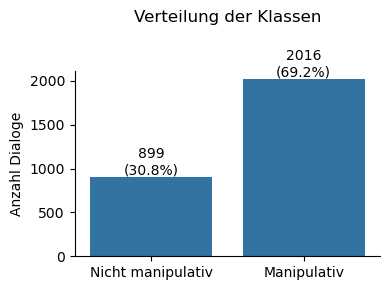

In [9]:
# Klassenverteilung visualisieren
plt.figure(figsize=(4, 3))

ax = sns.barplot(
    data=klassen_df,
    x="Klasse",
    y="Anzahl"
)

for p, prozent in zip(ax.patches, klassen_df["Prozent"]):
    anzahl = int(p.get_height())
    ax.annotate(
        f"{anzahl}\n({prozent:.1f}%)",
        (p.get_x()+ p.get_width() / 2, anzahl),
        ha="center",
        va="bottom"
    )

plt.title("Verteilung der Klassen", fontsize=12, pad=35)
plt.xlabel("")
plt.ylabel("Anzahl Dialoge")

sns.despine()
plt.tight_layout()
plt.show()

Die Klassenverteilung zeigt, dass der Datensatz überwiegend manipulative Dialoge enthält. Von insgesamt 2.915 Dialogen wurden 2.016 Dialoge (69,2 %) als manipulativ und 899 Dialoge (30,8 %) als nicht manipulativ gekennzeichnet. Obwohl beide Klassen ausreichend vertreten sind, liegt eine erkennbare Ungleichverteilung zugunsten der manipulativen Dialoge vor. Dieser Umstand sollte bei der späteren Modellierung und Interpretation der Ergebnisse berücksichtigt werden.

## 4.4 Manipulationstechniken

Während die Klassenverteilung lediglich zwischen manipulativen und nicht manipulativen Dialogen unterscheidet, ermöglicht die Analyse der konsolidierten Manipulationstechniken einen detaillierteren Einblick in die Struktur des Datensatzes. Dabei wird untersucht, welche Manipulationstechniken besonders häufig auftreten und wie stark die einzelnen Kategorien vertreten sind. Da einem Dialog mehrere Manipulationstechniken gleichzeitig zugeordnet werden können, erfolgt die Auswertung auf Basis aller vergebenen Technik-Labels. Zu beachten ist, dass Manipulationstechniken ausschließlich für als manipulativ gekennzeichnete Dialoge vergeben werden. Von den insgesamt 2.016 manipulativen Dialogen enthalten jedoch 268 keine konkrete Technikzuordnung. Die nachfolgende Analyse basiert daher auf den verbleibenden 1.748 Dialogen mit vorhandenen Technik-Labels.

In [10]:
df_manip[
    (df_manip["Manipulative"] == 1) &
    (df_manip["Technique"].isnull())
].shape[0]

268

In [11]:
# Alle Techniken aufteilen und zählen
technique_counts = (
    df_manip["Technique"]
    .dropna()
    .str.split(",")
    .explode()
    .value_counts()
)

# In DataFrame umwandeln
technique_df = pd.DataFrame({
    "Technik": technique_counts.index,
    "Anzahl": technique_counts.values
})

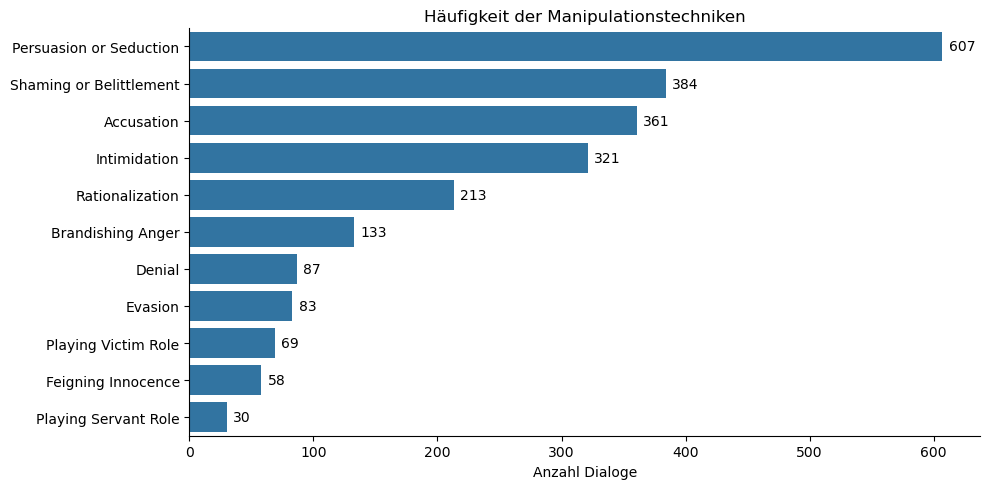

In [12]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=technique_df,
    x="Anzahl",
    y="Technik"
)

# Werte an Balken schreiben
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_width())}",
        (p.get_width()+5, p.get_y() + p.get_height()/2),
        va="center"
    )

plt.title("Häufigkeit der Manipulationstechniken", fontsize=12, pad=5)
plt.xlabel("Anzahl Dialoge")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

Die Verteilung der Manipulationstechniken zeigt deutliche Unterschiede zwischen den einzelnen Kategorien. Am häufigsten tritt die Technik Persuasion or Seduction mit 607 Vorkommen auf, gefolgt von Shaming or Belittlement mit 384 sowie Accusation mit 361 Vorkommen. Ebenfalls vergleichsweise häufig vertreten sind Intimidation (321) und Rationalization (213).

Demgegenüber treten Techniken wie Playing Servant Role (30), Feigning Innocence (58) oder Playing Victim Role (69) deutlich seltener auf. Insgesamt zeigt sich eine unausgewogene Verteilung der konsolidierten Manipulationstechniken, wobei einige Kategorien einen wesentlich größeren Anteil der annotierten Manipulationsfälle ausmachen als andere.

Die Analyse der Manipulationstechniken dient in dieser Arbeit vor allem dazu, die inhaltliche Zusammensetzung der manipulativen Dialoge genauer zu beschreiben. Die ungleichmäßige Verteilung zeigt, dass die positive Klasse unterschiedliche Formen mentaler Manipulation umfasst, die im Datensatz unterschiedlich stark vertreten sind.

## 4.5 Vulnerabilitäten

Die Analyse der Vulnerabilitäten ergänzt die Betrachtung der Manipulationstechniken um die Perspektive der ausgenutzten Schwachstellen der manipulierten Person. Dabei wird untersucht, welche Vulnerabilitäten im Datensatz besonders häufig auftreten und wie stark die einzelnen Kategorien vertreten sind. Vulnerabilitäten werden ausschließlich für manipulative Dialoge vergeben. Von den insgesamt 2.016 manipulativen Dialogen enthalten jedoch nur 605 mindestens ein Vulnerability-Label. Da einem Dialog mehrere Vulnerabilitäten gleichzeitig zugeordnet werden können, erfolgt die Auswertung auf Basis aller vergebenen Vulnerability-Labels. Die nachfolgende Analyse basiert daher auf den 605 Dialogen mit vorhandenen Vulnerability-Labels.

In [13]:
df_manip[
    (df_manip["Manipulative"] == 1) &
    (df_manip["Vulnerability"].isnull())
].shape[0]

1411

In [14]:
# Alle Vulnerabilitäten aufteilen und zählen
vulnerability_counts = (
    df_manip["Vulnerability"]
    .dropna()
    .str.split(",")
    .explode()
    .value_counts()
)

# In DataFrame umwandeln
vulnerability_df = pd.DataFrame({
    "Vulnerabilität": vulnerability_counts.index,
    "Anzahl": vulnerability_counts.values
})

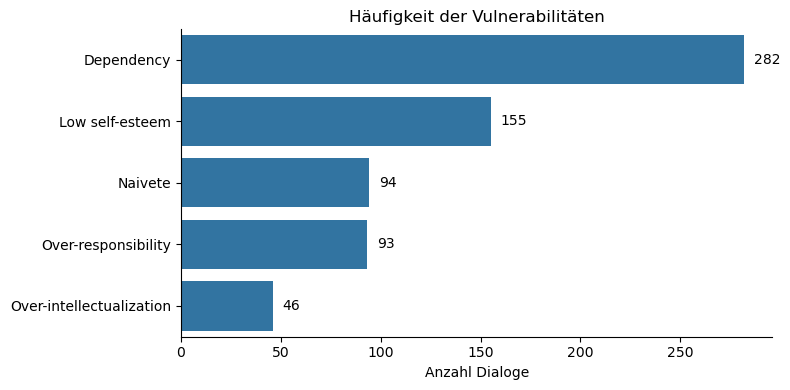

In [15]:
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=vulnerability_df,
    x="Anzahl",
    y="Vulnerabilität"
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_width())}",
        (p.get_width()+5, p.get_y() + p.get_height()/2),
        va="center"
    )

plt.title("Häufigkeit der Vulnerabilitäten", fontsize=12, pad=5)
plt.xlabel("Anzahl Dialoge")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

Die Verteilung der Vulnerabilitäten zeigt deutliche Unterschiede zwischen den einzelnen Kategorien. Am häufigsten tritt Dependency mit 282 Vorkommen auf. Mit deutlichem Abstand folgen Low self-esteem (155), Naivete (94) und Over-responsibility (93). Die Kategorie Over-intellectualization ist mit 46 Vorkommen vergleichsweise selten vertreten.

Insgesamt zeigt sich eine unausgewogene Verteilung der Vulnerabilitäten. Dies deutet darauf hin, dass bestimmte persönliche Eigenschaften oder Schwachstellen im Datensatz häufiger als Ansatzpunkt für manipulative Kommunikation dargestellt werden als andere. Besonders die Kategorien Dependency und Low self-esteem treten deutlich häufiger auf als die übrigen Vulnerabilitäten.

Die Analyse der Vulnerabilitäten dient in dieser Arbeit vor allem dazu, die inhaltliche Zusammensetzung der manipulativen Dialoge genauer zu beschreiben. Die ungleichmäßige Verteilung zeigt, dass die verschiedenen Vulnerabilitäten im Datensatz unterschiedlich stark vertreten sind und damit auch die annotierten manipulativen Dialoge hinsichtlich der ausgenutzten Schwachstellen unterschiedlich zusammengesetzt sind.

## 4.6 Zusammenhang zwischen Manipulationstechniken und Vulnerabilitäten

In diesem Abschnitt wird untersucht, welche Manipulationstechniken besonders häufig gemeinsam mit bestimmten Vulnerabilitäten auftreten. Hierzu werden die vergebenen Technik- und Vulnerabilitätslabels miteinander kombiniert und als Heatmap visualisiert. Dadurch können mögliche Zusammenhänge zwischen den eingesetzten Manipulationsstrategien und den ausgenutzten Schwachstellen der betroffenen Personen identifiziert werden.

Zu beachten ist, dass diese Analyse ausschließlich auf Dialogen basiert, für die sowohl mindestens eine Manipulationstechnik als auch mindestens eine Vulnerabilität annotiert wurden. Dadurch wird lediglich ein Teil des Gesamtdatensatzes betrachtet. Die Ergebnisse ermöglichen erste explorative Einblicke in mögliche Zusammenhänge, sollten jedoch aufgrund der begrenzten Datenbasis mit entsprechender Vorsicht interpretiert werden.

In [16]:
# Kombinationen aus Techniken und Vulnerabilitäten sammeln
kombinationen = []

for _, row in df_manip.dropna(subset=["Technique", "Vulnerability"]).iterrows():

    techniken = [t.strip() for t in row["Technique"].split(",")]
    vulnerabilitaeten = [v.strip() for v in row["Vulnerability"].split(",")]

    for technik in techniken:
        for vulnerabilitaet in vulnerabilitaeten:
            kombinationen.append([technik, vulnerabilitaet])

# DataFrame mit allen Kombinationen
kombi_df = pd.DataFrame(
    kombinationen,
    columns=["Technik", "Vulnerabilitaet"]
)

In [17]:
# Co-Occurrence Matrix
co_matrix = pd.crosstab(
    kombi_df["Technik"],
    kombi_df["Vulnerabilitaet"]
)

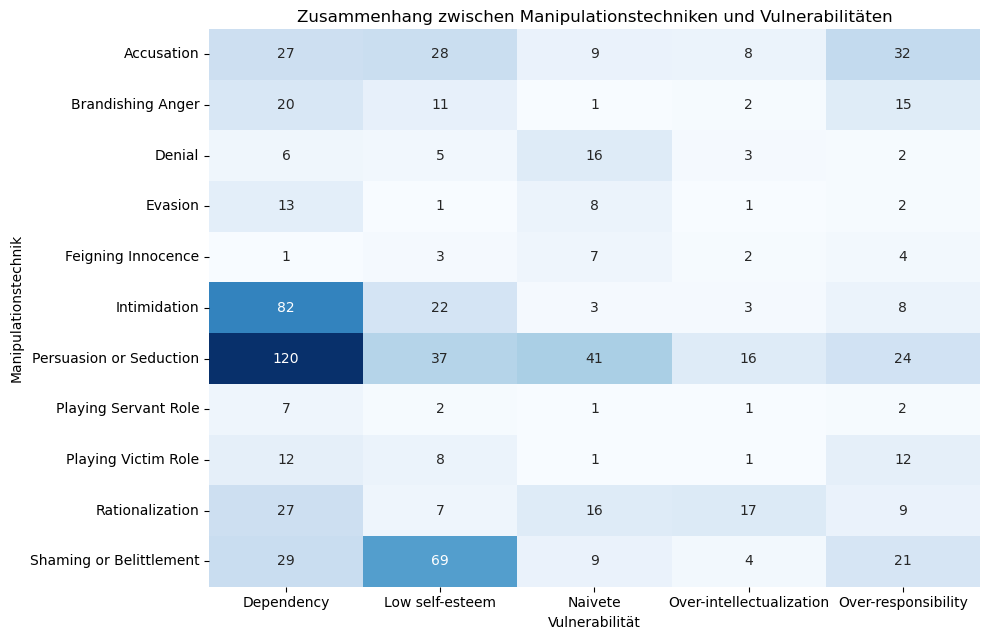

In [18]:
plt.figure(figsize=(10, 6.5))

sns.heatmap(
    co_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(
    "Zusammenhang zwischen Manipulationstechniken und Vulnerabilitäten",
    fontsize=12,
    pad=5
)

plt.xlabel("Vulnerabilität")
plt.ylabel("Manipulationstechnik")

plt.tight_layout()
plt.show()

Die Heatmap zeigt, dass bestimmte Manipulationstechniken häufiger gemeinsam mit einzelnen Vulnerabilitäten auftreten als andere. Besonders häufig ist die Kombination aus Persuasion or Seduction und Dependency (120 Vorkommen). Ebenfalls häufig treten Intimidation in Verbindung mit Dependency (82) sowie Shaming or Belittlement mit Low self-esteem (69) auf.

Darüber hinaus zeigen die Ergebnisse, dass einige Manipulationstechniken mit mehreren Vulnerabilitäten in Verbindung stehen. Insbesondere Persuasion or Seduction weist über nahezu alle Vulnerabilitätskategorien hinweg vergleichsweise hohe Werte auf. Demgegenüber treten Techniken wie Playing Servant Role oder Feigning Innocence insgesamt deutlich seltener auf und zeigen keine klar ausgeprägten Schwerpunkte.

Die Ergebnisse sollten jedoch vorsichtig interpretiert werden. Aufgrund der begrenzten Anzahl vollständig annotierter Dialoge liefern die beobachteten Zusammenhänge lediglich explorative Hinweise. Dennoch zeigt die Analyse, dass bestimmte Manipulationstechniken im untersuchten Datensatz häufiger gemeinsam mit spezifischen Vulnerabilitäten auftreten. Dies deutet auf mögliche Zusammenhänge zwischen Manipulationstechniken und Vulnerabilitäten hin, erlaubt jedoch keine Aussage darüber, ob die beobachteten Kombinationen statistisch signifikant sind.

## 4.7 Dialogeigenschaften

Neben den inhaltlichen Merkmalen werden in diesem Abschnitt auch strukturelle Eigenschaften der Dialoge untersucht. Dazu zählen insbesondere die Anzahl der Wörter pro Dialog sowie die Anzahl der Gesprächsbeiträge. Ziel ist es, ein besseres Verständnis für die Beschaffenheit des Datensatzes zu gewinnen und mögliche Unterschiede zwischen manipulativen und nicht manipulativen Dialogen zu identifizieren. Darüber hinaus kann die Analyse Hinweise darauf liefern, ob sich manipulative und nicht manipulative Dialoge hinsichtlich ihrer strukturellen Eigenschaften unterscheiden.

In [19]:
# Anzahl Wörter pro Dialog
df_manip["Wortanzahl"] = df_manip["Dialogue"].str.split().str.len()

df_manip["Wortanzahl"].describe()

count    2915.000000
mean       95.942024
std        84.269128
min         7.000000
25%        45.000000
50%        72.000000
75%       117.000000
max      1245.000000
Name: Wortanzahl, dtype: float64

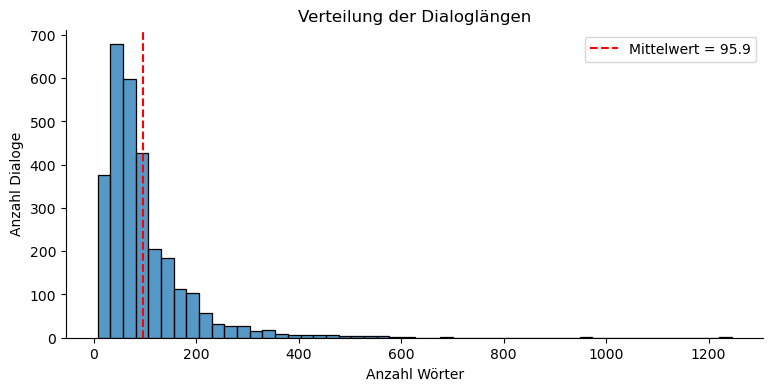

In [20]:
plt.figure(figsize=(9,4))

sns.histplot(
    data=df_manip,
    x="Wortanzahl",
    bins=50
)

plt.axvline(
    df_manip["Wortanzahl"].mean(),
    color="red",
    linestyle="--",
    label=f"Mittelwert = {df_manip['Wortanzahl'].mean():.1f}"
)

plt.legend()

plt.title("Verteilung der Dialoglängen")
plt.xlabel("Anzahl Wörter")
plt.ylabel("Anzahl Dialoge")

sns.despine()
plt.show()

Die deskriptive Statistik zeigt, dass die Dialoge im Datensatz durchschnittlich 95,9 Wörter umfassen. Der Median liegt bei 72 Wörtern und damit deutlich unter dem Mittelwert, was auf eine rechtsschiefe Verteilung hindeutet. 75 % der Dialoge enthalten höchstens 117 Wörter, während einzelne sehr lange Dialoge bis zu 1.245 Wörter umfassen. Auch im Histogramm ist zu erkennen, dass der Großteil der Dialoge eher kurz bis mittellang ist und nur wenige Dialoge sehr hohe Wortzahlen erreichen.

Neben der Länge eines Dialogs in Wörtern ist auch die Anzahl der Gesprächsbeiträge von Interesse. Während die Wortanzahl den gesamten Umfang eines Dialogs beschreibt, gibt die Anzahl der Gesprächsbeiträge Aufschluss über den Gesprächsverlauf. Im Folgenden wird daher untersucht, aus wie vielen einzelnen Äußerungen die Dialoge bestehen.

In [21]:
df_manip["Anzahl_Aeusserungen"] = (
    df_manip["Dialogue"].str.count("Person")
)

In [22]:
df_manip["Anzahl_Aeusserungen"].describe()

count    2915.000000
mean        6.600686
std         5.461703
min         2.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        89.000000
Name: Anzahl_Aeusserungen, dtype: float64

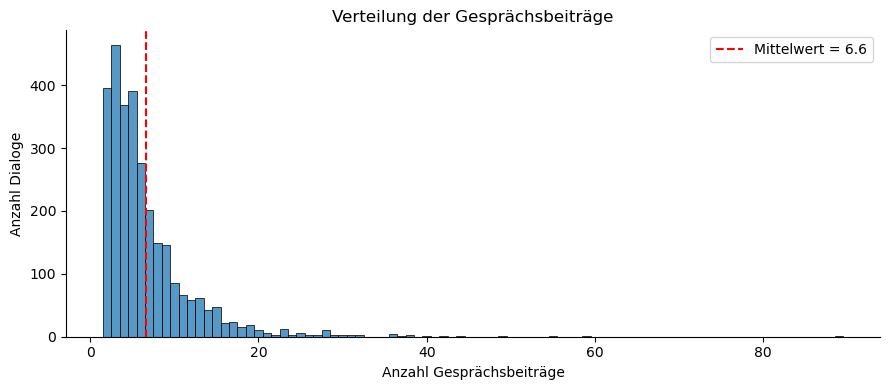

In [23]:
# Verteilung der Anzahl von Gesprächsbeiträgen
plt.figure(figsize=(9, 4))

sns.histplot(
    data=df_manip,
    x="Anzahl_Aeusserungen",
    discrete=True
)

# Mittelwert einzeichnen
plt.axvline(
    df_manip["Anzahl_Aeusserungen"].mean(),
    color="red",
    linestyle="--",
    label=f"Mittelwert = {df_manip['Anzahl_Aeusserungen'].mean():.1f}"
)

plt.legend()

plt.title("Verteilung der Gesprächsbeiträge")
plt.xlabel("Anzahl Gesprächsbeiträge")
plt.ylabel("Anzahl Dialoge")

sns.despine()
plt.tight_layout()
plt.show()

Die Verteilung der Gesprächsbeiträge zeigt ein ähnliches Muster wie die zuvor untersuchte Dialoglänge. Der Großteil der Dialoge besteht aus wenigen Gesprächsbeiträgen, während die Anzahl längerer Gespräche mit zunehmender Beitragszahl deutlich abnimmt. Der durchschnittliche Dialog umfasst 6,6 Gesprächsbeiträge, was durch die rot gestrichelte Linie im Histogramm veranschaulicht wird. Die Verteilung weist somit ebenfalls eine ausgeprägte Rechtsschiefe auf.

Die Ergebnisse zeigen, dass die meisten Dialoge aus vergleichsweise kurzen Gesprächssequenzen bestehen, während zugleich einige deutlich umfangreichere Dialoge mit mehreren Dutzend Gesprächsbeiträgen enthalten sind. Insgesamt weist der Datensatz damit hinsichtlich der Dialogstruktur eine hohe Variabilität auf.

Nachdem die allgemeinen Eigenschaften der Dialoge untersucht wurden, stellt sich die Frage, ob sich manipulative und nicht manipulative Dialoge auch hinsichtlich ihrer Länge unterscheiden. Zur Beantwortung dieser Frage wird die Wortanzahl beider Klassen mithilfe eines Boxplots gegenübergestellt. Ein Boxplot stellt die Verteilung der Daten dar und zeigt unter anderem den Median, den Interquartilsabstand sowie mögliche Ausreißer. Dadurch lassen sich Unterschiede in Lage und Streuung der beiden Klassen übersichtlich vergleichen.

<Axes: xlabel='Manipulative', ylabel='Wortanzahl'>

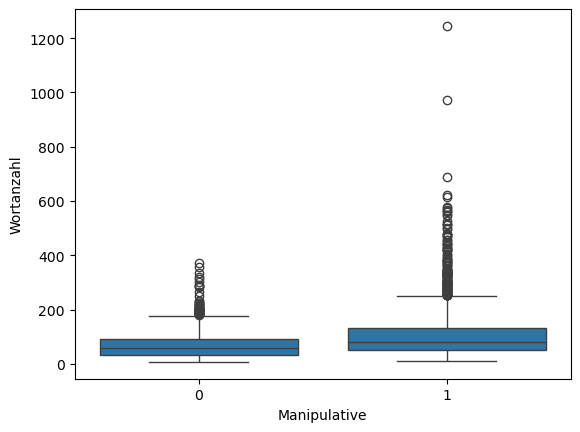

In [24]:
# Manipulativ vs. Nicht maniuplativ vergleichen --> sind manipulative Dialoge im Durchschnitt länger?
sns.boxplot(
    data=df_manip,
    x="Manipulative",
    y="Wortanzahl"
)

Der Boxplot zeigt, dass manipulative Dialoge tendenziell länger sind als nicht manipulative Dialoge. Der Median liegt bei den manipulativen Dialogen höher und auch die Wortzahlen sind insgesamt breiter verteilt. Zudem treten hier deutlich mehr und größere Ausreißer auf. Die Länge der Dialoge unterscheidet sich somit sichtbar zwischen den beiden Klassen.

Dies deutet darauf hin, dass die Dialoglänge mit dem Auftreten manipulativer Kommunikation zusammenhängen könnte. Die beobachteten Unterschiede zeigen damit eine weitere strukturelle Besonderheit der beiden Klassen, erlauben jedoch keine Aussage darüber, ob die Dialoglänge tatsächlich für die spätere Klassifikation ausschlaggebend ist.

## 4.8 Qualitative Betrachtung der Dialoge

Zur Ergänzung der bisherigen quantitativen Analysen werden im Folgenden vier beispielhafte Dialoge qualitativ betrachtet. Ziel ist es, die im Datensatz vergebenen Labels anhand konkreter Beispiele nachzuvollziehen und typische sprachliche Merkmale manipulativer beziehungsweise nicht manipulativer Kommunikation zu veranschaulichen. Die ausgewählten Dialoge dienen dabei ausschließlich der exemplarischen Illustration und ergänzen die zuvor durchgeführten statistischen Auswertungen.

**Beispiel 1: Nicht manipulativer Dialog**

In [25]:
# Beispiel auswählen
dialog = df_manip[df_manip["Manipulative"] == 0]["Dialogue"].iloc[50]

# \n in echte Zeilenumbrüche umwandeln
print(dialog.replace("\\n", "\n"))

Person1: Marry Christmas.
Person2: Thank you.  I thought you were avoiding me.
Person1: What gave you that idea?
Person2: In the last six weeks you've only been in my elevator once -- and then you didn't take your hat off.
Person1: Well, as a matter of fact, I was rather hurt when you stood me up that night --
Person2: I don't blame you. It was unforgivable.
Person1: I forgive you.
Person2: You shouldn't.
Person1: You couldn't help yourself. I mean, when you're having a drink with one man, you can't just suddenly walk out on him because you have another date with another man. You did the only decent thing.
Person2: Don't be too sure. Just because I wear a uniform -- that doesn't make me a Girl Scout.
Person1: Miss Kubelik, one doesn't get to be a second administrative assistant around here unless he's a pretty good judge of character -- and as far as I'm concerned, you're tops. I mean, decency-wise -- and otherwise-wise.  Cheers.
Person2: Cheers.


Der Dialog wurde im Datensatz als nicht manipulativ gekennzeichnet. Inhaltlich handelt es sich um ein persönliches Gespräch zwischen zwei Personen, in dem vergangene Ereignisse, Gefühle und gegenseitige Wahrnehmungen thematisiert werden. Obwohl einzelne kritische oder emotionale Äußerungen vorkommen, entwickelt sich das Gespräch zu einem offenen und wertschätzenden Austausch. Dem Dialog wurden weder Manipulationstechniken noch Vulnerabilitäten zugeordnet. Das Beispiel verdeutlicht, dass emotionale oder konfliktbehaftete Gespräche nicht zwangsläufig als manipulativ eingestuft werden.

**Beispiel 2: Manipulativer Dialog - Überredung und Verführung bei Abhängigkeit**

In [26]:
# Beispiel 2:
beispiel_2 = df_manip[
    (df_manip["Manipulative"] == 1) &
    (df_manip["Technique"].str.contains("Persuasion or Seduction", na=False)) &
    (df_manip["Vulnerability"].str.contains("Dependency", na=False))
].iloc[0]

print("Technique:", beispiel_2["Technique"])
print("Vulnerability:", beispiel_2["Vulnerability"])
print()

print(beispiel_2["Dialogue"].replace("\\n", "\n"))

Technique: Persuasion or Seduction,Accusation
Vulnerability: Dependency

Person1: You're mine, you know.  I made you.
Person2: I know.
Person1: If you went away, what would become of me?
Person2: I'm grown up now.  I have to leave some time.
Person1: Of course you do, and I want you to... but there's no need to hurry it along, is there?
Person2: I can't help it.
Person1: That's twice this month you've slipped Deadly Night Shade into my tea and run off.  People might get the wrong idea and think you're unhappy at home.


Der Dialog wurde im Datensatz als manipulativ klassifiziert und den Manipulationstechniken Persuasion or Seduction (Überredung oder Verführung) sowie Accusation (Anschuldigung oder Schuldzuweisung) zugeordnet. Als ausgenutzte Vulnerabilität ist Dependency (Abhängigkeit) annotiert.

Die annotierten Manipulationstechniken spiegeln sich insbesondere in den Aussagen „You're mine, you know. I made you.“ und „If you went away, what would become of me?“ wider. Person 1 versucht, bei Person 2 ein Gefühl emotionaler Verpflichtung und Verantwortung hervorzurufen und sie dadurch von einem Weggehen abzuhalten. Gleichzeitig wird suggeriert, dass ein Verlassen der Beziehung schwerwiegende Folgen für Person 1 hätte. Die spätere Bemerkung, andere könnten denken, Person 2 sei „unhappy at home“, enthält zudem eine indirekte Schuldzuweisung und erzeugt sozialen Druck.

Das Beispiel verdeutlicht, wie emotionale Bindung und wahrgenommene Abhängigkeit genutzt werden können, um das Verhalten einer anderen Person zu beeinflussen. Gleichzeitig zeigt es, dass mehrere Manipulationstechniken innerhalb eines Dialogs gemeinsam auftreten können und sich gegenseitig ergänzen.

**Beispiel 3: Manipulativer Dialog - Beschämung und Schuldzuweisung bei geringem Selbstwertgefühl**

In [27]:
# Beispiel 3:
beispiel_3 = df_manip[
    (df_manip["Manipulative"] == 1) &
    (df_manip["Technique"].str.contains("Shaming or Belittlement", na=False)) &
    (df_manip["Vulnerability"].str.contains("Low self-esteem", na=False))
].iloc[3]

print("Technique:", beispiel_3["Technique"])
print("Vulnerability:", beispiel_3["Vulnerability"])
print()
print(beispiel_3["Dialogue"].replace("\\n", "\n"))

Technique: Shaming or Belittlement,Accusation
Vulnerability: Low self-esteem

Person1: ...But I guess you don't really know him any better than that board does, do ya, Miss Archuh?
Person2: Well, maybe I --
Person1: An' only some kind a knucklehead thinks she knows things 'bout things she, uh -- when she don't, uh -- How'd that go?
Person2: It's hardly the same --
Person1: Why you don't even know y'own self -- you ain't exactly the genuine article are you, Miss Archuh?
Person2: Well, in connection with my job, sometimes I have to go undercover as it were --
Person1: I don't mean that! Why you pretendin' to be such a hard ol' sourpuss! Ain't never gonna make you happy! Never made Warin' happy.
Person2: I'm happy enough.
Person1: Okay, Miss Archuh.  ...I got gears to see to.
Person2: I'm plenty happy!


Der Dialog wurde im Datensatz als manipulativ klassifiziert und den Manipulationstechniken Shaming or Belittlement (Beschämung oder Herabsetzung) sowie Accusation (Anschuldigung oder Schuldzuweisung) zugeordnet. Als ausgenutzte Vulnerabilität ist Low self-esteem (geringes Selbstwertgefühl) annotiert.

Die annotierten Manipulationstechniken spiegeln sich insbesondere darin wider, dass Person 1 wiederholt die Fähigkeiten, das Wissen und die Persönlichkeit von Person 2 infrage stellt. Aussagen wie „only some kind of a knucklehead thinks she knows things when she don't“ oder „you don't even know your own self“ dienen dazu, das Selbstvertrauen der anderen Person zu untergraben und Zweifel an der eigenen Kompetenz hervorzurufen. Darüber hinaus enthält der Dialog mehrere indirekte Schuldzuweisungen und persönliche Angriffe, die über eine sachliche Auseinandersetzung hinausgehen.

Das Beispiel verdeutlicht, wie Herabsetzung und Schuldzuweisung gezielt eingesetzt werden können, um eine Person emotional zu verunsichern. Die im Datensatz vergebene Vulnerabilität Low self-esteem wird durch den Dialog nachvollziehbar illustriert, da die Äußerungen darauf abzielen, das Selbstwertgefühl der betroffenen Person zu schwächen und dadurch Einfluss auf ihre Selbstwahrnehmung und ihr Verhalten auszuüben.

**Beispiel 4: Manipulativer Dialog - Schuldzuweisung bei Überverantwortlichkeit**

In [28]:
# Beispiel 4:
beispiel_4 = df_manip[
    (df_manip["Manipulative"] == 1) &
    (df_manip["Technique"].str.contains("Accusation", na=False)) &
    (df_manip["Vulnerability"].str.contains("Over-responsibility", na=False))
].iloc[10]

print("Technique:", beispiel_4["Technique"])
print("Vulnerability:", beispiel_4["Vulnerability"])
print()
print(beispiel_4["Dialogue"].replace("\\n", "\n"))

Technique: Feigning Innocence,Accusation
Vulnerability: Over-responsibility

Person1: You all went out for dinner last night and didn't even think to invite me?
Person2: We thought you were busy with your project, Sam.
Person1: That's not the point. I constantly feel left out of group plans.
Person2: We genuinely didn't mean to exclude you.
Person1: Nobody cares about me. Maybe I'm just not meant to be a part of this group.
Person2: That's not true, Sam. We value you. We just need to be more considerate in the future.


Der Dialog wurde im Datensatz als manipulativ klassifiziert und den Manipulationstechniken Accusation (Anschuldigung oder Schuldzuweisung) sowie Feigning Innocence (Vortäuschen von Unschuld) zugeordnet. Als ausgenutzte Vulnerabilität ist Over-responsibility (Überverantwortlichkeit) annotiert.

Die annotierten Manipulationstechniken spiegeln sich insbesondere darin wider, dass Person 1 den anderen Gesprächsteilnehmenden vorwirft, sie bewusst ausgeschlossen zu haben, und dadurch wiederholt Schuldgefühle erzeugt. Aussagen wie „You all went out for dinner last night and didn't even think to invite me?“ oder „Nobody cares about me“ verlagern die Verantwortung für die eigenen negativen Gefühle auf die andere Person. Gleichzeitig wird die Erklärung von Person 2, der Ausschluss sei nicht beabsichtigt gewesen, weitgehend zurückgewiesen, wodurch der emotionale Druck aufrechterhalten wird.

Das Beispiel verdeutlicht, wie Schuldzuweisungen und emotionale Vorwürfe eingesetzt werden können, um Verantwortungsgefühle bei einer anderen Person hervorzurufen. Die im Datensatz vergebene Vulnerabilität Over-responsibility wird durch den Dialog nachvollziehbar illustriert, da die Äußerungen darauf abzielen, das Verantwortungsgefühl der angesprochenen Person auszunutzen und ihr Verhalten dadurch zu beeinflussen.

# 5. Textvorverarbeitung

Die explorative Datenanalyse hat gezeigt, dass die Dialoge hinsichtlich ihrer Länge, Struktur und sprachlichen Gestaltung teilweise stark variieren. Für die anschließende automatische Textklassifikation werden zwei unterschiedliche Modellierungsansätze untersucht, die unterschiedliche Anforderungen an die Textvorverarbeitung stellen.

Für die klassischen Klassifikationsverfahren werden die Dialogtexte schrittweise vereinheitlicht und bereinigt. Dazu zählen die Umwandlung in Kleinbuchstaben, das Entfernen von Satzzeichen und Stoppwörtern, die Tokenisierung sowie die Lemmatisierung. Die Auswirkungen der einzelnen Verarbeitungsschritte werden im Folgenden anhand ausgewählter Beispiele dargestellt. Für die später eingesetzten Transformer-Modelle wird dagegen auf eine solche umfassende Bereinigung verzichtet, da dessen Tokenizer und vortrainierte Sprachrepräsentation auf weitgehend unverarbeiteten Texten basieren.

Um die ursprünglichen Dialoge unverändert zu erhalten, wird für die nachfolgenden Verarbeitungsschritte eine Kopie des Datensatzes erstellt.

In [29]:
# Arbeitskopie für die Textvorverarbeitung erstellen
df_preprocessed = df_manip.copy()

## 5.1 Umwandlung in Kleinbuchstaben

Im ersten Schritt werden alle Texte in Kleinbuchstaben umgewandelt. Dadurch werden Wörter unabhängig von ihrer ursprünglichen Schreibweise einheitlich behandelt. Beispielsweise werden die Wörter „Person“ und „person“ nach der Umwandlung als identisch betrachtet, wodurch die Anzahl unterschiedlicher Tokens reduziert wird.

In [30]:
# Dialoge in Kleinbuchstaben umwandeln
# Kleinbuchstaben
df_preprocessed["Dialogue"] = (
    df_preprocessed["Dialogue"]
    .str.lower()
)

In [31]:
# Beispieltext auswählen
beispiel_vorher = df_manip["Dialogue"].iloc[0]
beispiel_nachher = df_preprocessed["Dialogue"].iloc[0]

print("Vorher:")
print(beispiel_vorher[:300])

print("\nNachher:")
print(beispiel_nachher[:300])

Vorher:
Person1: Jesus! Listen to this one: "Do you remember me? Airport shuttle, June 7th. You: striking redhead with yellow dress, pearl necklace, brown shoes. I was the bookish fellow in the green cardigan who helped you find your contact lens. Am I crazy, or did we have a moment?"
Person2: God, that's s

Nachher:
person1: jesus! listen to this one: "do you remember me? airport shuttle, june 7th. you: striking redhead with yellow dress, pearl necklace, brown shoes. i was the bookish fellow in the green cardigan who helped you find your contact lens. am i crazy, or did we have a moment?"
person2: god, that's s


Im Beispiel ist zu erkennen, dass sämtliche Wörter unabhängig von ihrer ursprünglichen Schreibweise in Kleinbuchstaben vorliegen. Inhaltlich bleibt der Dialog unverändert, die Schreibweise wird jedoch vereinheitlicht. Dadurch werden identische Wörter mit unterschiedlicher Groß- und Kleinschreibung in den nachfolgenden Verarbeitungsschritten als dasselbe Merkmal behandelt, was die Anzahl unterschiedlicher Tokens reduziert.

## 5.2 Entfernen von Satzzeichen

Im nächsten Schritt werden Satzzeichen aus den Dialogen entfernt. Satzzeichen tragen in vielen NLP-Anwendungen nur begrenzt zur inhaltlichen Bedeutung eines Textes bei und können die Anzahl unterschiedlicher Tokens unnötig erhöhen. Durch die Entfernung von Zeichen wie Punkten, Kommas, Fragezeichen oder Anführungszeichen wird der Text weiter vereinheitlicht und für die spätere Analyse vorbereitet.

In [32]:
# Satzzeichen entfernen
df_preprocessed["Dialogue"] = (
    df_preprocessed["Dialogue"]
    .apply(lambda text: re.sub(r"[^\w\s]", "", text))
)

In [33]:
# Beispieltext auswählen
beispiel_vorher = df_manip["Dialogue"].iloc[0]

# Vorverarbeitungsschritte bis einschließlich Satzzeichenentfernung
beispiel_nachher = (
    beispiel_vorher
    .lower()
)

beispiel_nachher = re.sub(r"[^\w\s]", "", beispiel_nachher)

print("Vorher:")
print(beispiel_vorher[:300])

print("\nNachher:")
print(beispiel_nachher[:300])

Vorher:
Person1: Jesus! Listen to this one: "Do you remember me? Airport shuttle, June 7th. You: striking redhead with yellow dress, pearl necklace, brown shoes. I was the bookish fellow in the green cardigan who helped you find your contact lens. Am I crazy, or did we have a moment?"
Person2: God, that's s

Nachher:
person1 jesus listen to this one do you remember me airport shuttle june 7th you striking redhead with yellow dress pearl necklace brown shoes i was the bookish fellow in the green cardigan who helped you find your contact lens am i crazy or did we have a moment
person2 god thats so pathetic i bet s


Im Beispiel ist zu erkennen, dass sämtliche Satzzeichen entfernt wurden, der eigentliche Textinhalt jedoch erhalten bleibt. Die Dialoge bestehen nun ausschließlich aus Wörtern und Zahlen, wodurch die Textrepräsentation vereinheitlicht wird. Dies reduziert die Anzahl unterschiedlicher Tokens und vereinfacht die anschließende Verarbeitung durch klassische NLP-Verfahren.

## 5.3 Entfernen von Stoppwörtern

Nach der Vereinheitlichung der Schreibweise und der Entfernung von Satzzeichen werden im nächsten Schritt sogenannte Stoppwörter entfernt. Dabei handelt es sich um sehr häufig vorkommende Wörter wie „the“, „is“, „and“ oder „to“, die meist nur eine geringe inhaltliche Bedeutung besitzen. Ziel ist es, den Fokus stärker auf die inhaltlich relevanten Begriffe zu legen und gleichzeitig die Anzahl der zu verarbeitenden Tokens zu reduzieren.

In [34]:
stop_words = set(stopwords.words("english"))

# Stoppwörter entfernen
df_preprocessed["Dialogue"] = (
    df_preprocessed["Dialogue"]
    .apply(
        lambda text: " ".join(
            word for word in text.split()
            if word not in stop_words
        )
    )
)

In [35]:
# Beispieltext auswählen
beispiel_vorher = df_manip["Dialogue"].iloc[0]
beispiel_nachher = df_preprocessed["Dialogue"].iloc[0]

print("Vorher:")
print(beispiel_vorher[:300])

print("\nNachher:")
print(beispiel_nachher[:300])

Vorher:
Person1: Jesus! Listen to this one: "Do you remember me? Airport shuttle, June 7th. You: striking redhead with yellow dress, pearl necklace, brown shoes. I was the bookish fellow in the green cardigan who helped you find your contact lens. Am I crazy, or did we have a moment?"
Person2: God, that's s

Nachher:
person1 jesus listen one remember airport shuttle june 7th striking redhead yellow dress pearl necklace brown shoes bookish fellow green cardigan helped find contact lens crazy moment person2 god thats pathetic bet didnt even notice person1 know hes like psychotically obsessing every little detail p


Im Beispiel ist zu erkennen, dass häufig vorkommende Funktionswörter durch die Stoppwortentfernung aus dem Dialog entfernt werden. So wird beispielsweise aus der Formulierung „Do you remember me?“ lediglich das inhaltlich stärker relevante Wort „remember“, während die Stoppwörter „do“, „you“ und „me“ entfallen. Andere Begriffe wie „airport“, „shuttle“, „redhead“ oder „dress“ bleiben dagegen erhalten. Dadurch wird der Text kompakter und der Merkmalsraum stärker auf inhaltlich relevante Begriffe konzentriert. Dies ist insbesondere für die nachfolgend eingesetzte TF-IDF-Darstellungen von Bedeutung.

## 5.4 Tokenisierung

Im nächsten Schritt werden die bereinigten Dialoge tokenisiert. Dabei wird ein Text in einzelne Bestandteile, sogenannte Tokens, zerlegt. In dieser Arbeit erfolgt die Tokenisierung auf Wortebene, sodass jeder Dialog als Liste einzelner Wörter dargestellt wird.

In [36]:
# Dialoge tokenisieren
df_preprocessed["Tokens"] = (
    df_preprocessed["Dialogue"]
    .apply(lambda text: text.split())
)

In [37]:
# Beispieltext auswählen
beispiel_vorher = df_preprocessed["Dialogue"].iloc[0]
beispiel_nachher = df_preprocessed["Tokens"].iloc[0]

print("Vorher:")
print(beispiel_vorher[:300])

print("\nNachher:")
print(beispiel_nachher[:30])

Vorher:
person1 jesus listen one remember airport shuttle june 7th striking redhead yellow dress pearl necklace brown shoes bookish fellow green cardigan helped find contact lens crazy moment person2 god thats pathetic bet didnt even notice person1 know hes like psychotically obsessing every little detail p

Nachher:
['person1', 'jesus', 'listen', 'one', 'remember', 'airport', 'shuttle', 'june', '7th', 'striking', 'redhead', 'yellow', 'dress', 'pearl', 'necklace', 'brown', 'shoes', 'bookish', 'fellow', 'green', 'cardigan', 'helped', 'find', 'contact', 'lens', 'crazy', 'moment', 'person2', 'god', 'thats']


Das Beispiel zeigt, dass der zuvor als Fließtext vorliegende Dialog nun als Liste einzelner Wörter dargestellt wird. Jedes Wort bildet ein separates Token und kann dadurch im weiteren Verlauf gezielt verarbeitet werden. Die Tokenisierung schafft somit die Grundlage für die anschließende Lemmatisierung, bei der die einzelnen Tokens gezielt verarbeitet werden.

## 5.5 Lemmatisierung

Im letzten Schritt der Textvorverarbeitung erfolgt die Lemmatisierung. Dabei werden verschiedene Wortformen auf ihre Grundform (Lemma) zurückgeführt. Beispielsweise werden die Wörter running, runs und ran auf die Grundform run reduziert. Dadurch werden unterschiedliche Flexionsformen eines Wortes vereinheitlicht und die Anzahl unterschiedlicher Tokens verringert.

In [38]:
def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

In [39]:
# Lemmatisierung vorbereiten
lemmatizer = WordNetLemmatizer()
beispiel_vorher = df_preprocessed["Tokens"].iloc[0].copy()

# Tokens lemmatisieren
df_preprocessed["Tokens"] = df_preprocessed["Tokens"].apply(
    lambda tokens: [
        lemmatizer.lemmatize(token, get_wordnet_pos(tag))
        for token, tag in pos_tag(tokens)
    ]
)

In [40]:
# Beispiel anzeigen
beispiel_nachher = df_preprocessed["Tokens"].iloc[0]

print("Vorher:")
print(beispiel_vorher[:50])

print("\nNachher:")
print(beispiel_nachher[:50])

Vorher:
['person1', 'jesus', 'listen', 'one', 'remember', 'airport', 'shuttle', 'june', '7th', 'striking', 'redhead', 'yellow', 'dress', 'pearl', 'necklace', 'brown', 'shoes', 'bookish', 'fellow', 'green', 'cardigan', 'helped', 'find', 'contact', 'lens', 'crazy', 'moment', 'person2', 'god', 'thats', 'pathetic', 'bet', 'didnt', 'even', 'notice', 'person1', 'know', 'hes', 'like', 'psychotically', 'obsessing', 'every', 'little', 'detail', 'person2', 'call', 'pretend', 'redhead', 'person1', 'oh']

Nachher:
['person1', 'jesus', 'listen', 'one', 'remember', 'airport', 'shuttle', 'june', '7th', 'strike', 'redhead', 'yellow', 'dress', 'pearl', 'necklace', 'brown', 'shoe', 'bookish', 'fellow', 'green', 'cardigan', 'help', 'find', 'contact', 'lens', 'crazy', 'moment', 'person2', 'god', 'thats', 'pathetic', 'bet', 'didnt', 'even', 'notice', 'person1', 'know', 'he', 'like', 'psychotically', 'obsess', 'every', 'little', 'detail', 'person2', 'call', 'pretend', 'redhead', 'person1', 'oh']


Das Beispiel zeigt, dass durch die Lemmatisierung verschiedene Wortformen auf ihre jeweilige Grundform zurückgeführt werden. So wird beispielsweise „striking“ zu „strike“, „shoes“ zu „shoe“ und „helped“ zu „help“. Viele Wörter bleiben hingegen unverändert, da sie bereits in ihrer Grundform vorliegen. Durch die Vereinheitlichung unterschiedlicher Wortformen kann die Anzahl verschiedener Tokens reduziert werden. Dies ist insbesondere für die anschließende TF-IDF-Darstellung hilfreich, da inhaltlich gleiche Begriffe unabhängig von ihrer grammatikalischen Form als dasselbe Merkmal berücksichtigt werden.

## 5.6 Ergebnis der Vorverarbeitung

Abschließend wird die Wirkung der gesamten Vorverarbeitungspipeline anhand eines Beispieldialogs dargestellt. Hierdurch wird sichtbar, wie sich die einzelnen Verarbeitungsschritte auf die ursprünglichen Texte auswirken.

In [41]:
print("Original:")
print(df_manip["Dialogue"].iloc[50][:500])

print("\nNach Vorverarbeitung:")
print(df_preprocessed["Tokens"].iloc[50][:300])

Original:
Person1: Delacroix, wake up, brother man. The reason why they didn't get picked up was because nobody - and I mean NOBODY - niggers and crackers alike wants to see that junk.
Person2: I've never been given a fair shot.
Person1: You got your head stuck up your ass with your Harvard education and your pretentious ways.  Brother man, I'm blacker than you.  I'm keepin' it real and you're frontin', trying to be white.
Person2: I'm an oreo, a sell out?  Because I don't aspire to do HOMEBOYS FROM OUT O

Nach Vorverarbeitung:
['person1', 'delacroix', 'wake', 'brother', 'man', 'reason', 'didnt', 'get', 'pick', 'nobody', 'mean', 'nobody', 'nigger', 'cracker', 'alike', 'want', 'see', 'junk', 'person2', 'ive', 'never', 'give', 'fair', 'shot', 'person1', 'get', 'head', 'stuck', 'as', 'harvard', 'education', 'pretentious', 'way', 'brother', 'man', 'im', 'blacker', 'im', 'keepin', 'real', 'youre', 'frontin', 'try', 'white', 'person2', 'im', 'oreo', 'sell', 'dont', 'aspire', 'homeboys', 'spa

Die Vorverarbeitung überführt die ursprünglichen Dialogtexte in eine vereinheitlichte und reduzierte Darstellung. Hierzu werden zunächst alle Wörter in Kleinbuchstaben umgewandelt und Satzzeichen entfernt. Anschließend werden häufig vorkommende Stoppwörter entfernt und die verbleibenden Wörter tokenisiert. Im Beispiel ist die Wirkung der Stoppwortentfernung etwa daran zu erkennen, dass Wörter wie „the“, „they“, „was“ oder „because“ entfallen, während inhaltlich relevantere Begriffe erhalten bleiben. Abschließend werden durch die Lemmatisierung verschiedene Wortformen auf ihre Grundform zurückgeführt, beispielsweise „picked“ zu „pick“, „given“ zu „give“, „ways“ zu „way“ und „trying“ zu „try“. Die resultierenden Tokens bilden die Grundlage für die anschließende TF-IDF-Vektorisierung und die darauf aufbauenden klassischen Klassifikationsmodelle.

Für die zusätzlich untersuchten Transformer-Modelle wird hingegen auf die beschriebene Bereinigung, Stoppwortentfernung und Lemmatisierung verzichtet. Stattdessen werden die ursprünglichen Dialogtexte mithilfe des zum vortrainierten Modell gehörenden Tokenizers verarbeitet. Damit werden im weiteren Verlauf zwei unterschiedliche Verarbeitungspipelines betrachtet, die an die jeweiligen Modellierungsansätze angepasst sind.

# 6. Klassifikationsmodelle

Aufbauend auf der vorangegangenen Datenanalyse und Textvorverarbeitung werden im Folgenden verschiedene Klassifikationsmodelle zur automatischen Erkennung manipulativer Dialoge untersucht. Hierfür werden sowohl klassische Machine-Learning-Verfahren auf Basis von TF-IDF als auch transformerbasierte Modelle eingesetzt.

Vor der Modellierung werden die aufbereiteten Daten für das Training vorbereitet und in Trainings- und Testdaten aufgeteilt. Zudem werden einheitliche Kennzahlen für die spätere Bewertung der Modelle festgelegt. Anschließend werden die verschiedenen Klassifikationsverfahren trainiert und anhand derselben Kennzahlen evaluiert. Die Ergebnisse der einzelnen Modelle werden in Kapitel 7 zusammengeführt und miteinander verglichen.

## 6.1 Vorbereitung der Trainingsdaten

Für das Training der klassischen Klassifikationsmodelle werden die zuvor erzeugten Tokens wieder zu zusammenhängenden Textstrings verbunden. Die vorgenommenen Verarbeitungsschritte bleiben dabei erhalten; lediglich die Darstellung als Liste einzelner Tokens wird aufgehoben. Dies ist erforderlich, da die anschließend eingesetzte TF-IDF-Vektorisierung die Dialoge als Textstrings verarbeitet. Als Eingabemerkmal dient somit der vorverarbeitete Dialogtext, während das Merkmal *Manipulative* die zu prognostizierende Zielvariable bildet.

Anschließend wird der Datensatz in 80 % Trainings- und 20 % Testdaten aufgeteilt. Durch eine stratifizierte Aufteilung bleibt das Verhältnis zwischen manipulativen und nicht manipulativen Dialogen in beiden Teilmengen erhalten. Der festgelegte random_state ermöglicht eine reproduzierbare Aufteilung. Die erzeugten Trainings- und Testdaten bilden die Grundlage für die nachfolgenden Klassifikationsexperimente.

In [42]:
# Tokens wieder zu Text zusammensetzen
df_model = df_preprocessed.copy()

df_model["Text"] = df_model["Tokens"].apply(lambda x: " ".join(x))

In [43]:
# Eingabedaten und Zielvariable festlegen
X = df_model["Text"]
y = df_model["Manipulative"]

In [44]:
# Aufteilung in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 20 % Testdaten
    random_state=42,     # Reproduzierbare Aufteilung
    stratify=y           # Klassenverteilung beibehalten
)

In [45]:
# Größe und Klassenverteilung prüfen
print(f"Trainingsdaten: {len(X_train)}")
print(f"Testdaten: {len(X_test)}")

print("\nKlassenverteilung Training:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nKlassenverteilung Test:")
print(y_test.value_counts(normalize=True).sort_index())

Trainingsdaten: 2332
Testdaten: 583

Klassenverteilung Training:
Manipulative
0    0.308319
1    0.691681
Name: proportion, dtype: float64

Klassenverteilung Test:
Manipulative
0    0.308748
1    0.691252
Name: proportion, dtype: float64


Für die Bewertung der Klassifikationsmodelle werden Precision, Recall, Accuracy, Micro-F1 und Macro-F1 verwendet. Die Auswahl orientiert sich an den Kennzahlen der ursprünglichen MentalManip-Veröffentlichung und ermöglicht damit eine spätere Einordnung der eigenen Ergebnisse gegenüber den dort berichteten Resultaten. Als zentrale Kennzahl für den Vergleich der eigenen Modelle wird insbesondere der Macro-F1-Score betrachtet, da hierbei beide Klassen unabhängig von ihrer Häufigkeit gleich gewichtet werden.

Ergänzend wird für jedes Modell eine Confusion Matrix dargestellt. Dadurch wird sichtbar, wie viele manipulative und nicht manipulative Dialoge korrekt beziehungsweise falsch klassifiziert werden. Von besonderem Interesse sind dabei die False Negatives, da diese manipulative Dialoge darstellen, die vom jeweiligen Modell nicht erkannt werden.

**Zentrale Ergebnistabelle vorbereiten**  
Zur einheitlichen Dokumentation der Modellergebnisse werden die berechneten Kennzahlen aller untersuchten Klassifikationsmodelle zentral gespeichert. Zusätzlich werden die Ergebnisse von Llama-2-13B und RoBERTa-base aus der ursprünglichen MentalManip-Veröffentlichung als Referenzwerte hinterlegt. Dadurch können die eigenen Modelle nach Abschluss der Modellierung anhand derselben Kennzahlen gegenübergestellt und die erzielten Ergebnisse in Kapitel 7 eingeordnet werden.

In [46]:
# Ergebnisse aller Modelle speichern
modell_ergebnisse = []

In [47]:
# Referenzwerte aus der MentalManip-Veröffentlichung
referenz_ergebnisse = [
    {
        "Modell": "Llama-2-13B (Originalpaper)",
        "Precision": 0.828,
        "Recall": 0.835,
        "Accuracy": 0.768,
        "Micro-F1": 0.768,
        "Macro-F1": 0.731
    },
    {
        "Modell": "RoBERTa-base (Originalpaper)",
        "Precision": 0.786,
        "Recall": 0.904,
        "Accuracy": 0.766,
        "Micro-F1": 0.766,
        "Macro-F1": 0.700
    }
]

In [48]:
# Vergleich eigener Modelle mit den Referenzwerten
def zeige_modellvergleich():

    alle_ergebnisse = modell_ergebnisse + referenz_ergebnisse

    return (
        pd.DataFrame(alle_ergebnisse)
        .set_index("Modell")
        .round(3)
    )

**Funktion zur Berechnung der Kennzahlen**  
Die folgende Funktion dient der einheitlichen Evaluation der untersuchten Klassifikationsmodelle. Auf Basis der tatsächlichen und vorhergesagten Klassen werden die festgelegten Kennzahlen berechnet und anschließend in der zentralen Ergebnistabelle gespeichert. Dadurch erfolgt die Bewertung aller Modelle nach demselben Schema.

In [49]:
# Kennzahlen berechnen und speichern
def berechne_kennzahlen(modellname, y_true, y_pred):
    
    ergebnis = {
        "Modell": modellname,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Micro-F1": f1_score(y_true, y_pred, average="micro"),
        "Macro-F1": f1_score(y_true, y_pred, average="macro")
    }
    
    modell_ergebnisse.append(ergebnis)
    
    return pd.DataFrame([ergebnis]).set_index("Modell").round(3)

**Funktion zur Erstellung der Konfusionsmatrix**  
Ergänzend zu den berechneten Kennzahlen wird für jedes Modell eine Konfusionsmatrix erstellt. Die folgende Funktion stellt die tatsächlichen und vorhergesagten Klassen einheitlich gegenüber und ermöglicht damit eine detailliertere Betrachtung der korrekten sowie fehlerhaften Klassifikationen.

In [50]:
# Confusion Matrix darstellen
def plot_confusion_matrix(y_true, y_pred, modellname):
    
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["Nicht manipulativ", "Manipulativ"],
        cmap="Blues"
    )
    
    plt.title(f"Confusion Matrix – {modellname}")
    plt.xlabel("Vorhergesagte Klasse")
    plt.ylabel("Tatsächliche Klasse")
    plt.tight_layout()
    plt.show()

Damit sind die Trainings- und Testdaten sowie die einheitlichen Funktionen zur Evaluation der Modelle vorbereitet. Im Folgenden werden die ausgewählten Klassifikationsverfahren schrittweise trainiert und anhand der festgelegten Kennzahlen und der Konfusionsmatrix bewertet. Den Ausgangspunkt bildet mit Naive Bayes ein klassisches Verfahren zur Textklassifikation auf Basis von TF-IDF.

## 6.2 TF-IDF + Naive Bayes

Als erstes Klassifikationsverfahren wird ein Multinomial-Naive-Bayes-Modell eingesetzt. Naive Bayes stellt ein vergleichsweise einfaches und effizientes Verfahren zur Textklassifikation dar und eignet sich insbesondere für hochdimensionale, dünn besetzte Merkmalsräume, wie sie bei der TF-IDF-Repräsentation von Texten entstehen. Das Modell dient damit als erste klassische Baseline für die nachfolgenden Verfahren.

Da das Modell nicht direkt mit Textdaten arbeiten kann, werden die vorverarbeiteten Dialoge zunächst mittels TF-IDF in numerische Merkmalsvektoren überführt. Dabei werden bis zu 15.000 Merkmale auf Basis einzelner Wörter berücksichtigt. Der TF-IDF-Vektorisierer wird ausschließlich auf den Trainingsdaten angepasst und anschließend unverändert auf die Testdaten angewendet.

In [51]:
# TF-IDF-Vektorisierung vorbereiten
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 1)
)

In [52]:
# Trainings- und Testdaten vektorisieren
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Trainingsmatrix: {X_train_tfidf.shape}")
print(f"Testmatrix: {X_test_tfidf.shape}")

Trainingsmatrix: (2332, 10464)
Testmatrix: (583, 10464)


In [53]:
# Naive-Bayes-Modell trainieren
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

MultinomialNB()

In [55]:
# Trainiertes Modell und TF-IDF-Vektorisierer speichern
modellpfad = "./Modelle/naive_bayes"
os.makedirs(modellpfad, exist_ok=True)

joblib.dump(nb_model, f"{modellpfad}/naive_bayes.joblib")
joblib.dump(tfidf, f"{modellpfad}/tfidf.joblib")

print("Naive-Bayes-Modell und TF-IDF-Vektorisierer gespeichert.")

Naive-Bayes-Modell und TF-IDF-Vektorisierer gespeichert.


In [ ]:
# Gespeichertes Modell und TF-IDF-Vektorisierer laden
nb_model = joblib.load("./Modelle/naive_bayes/naive_bayes.joblib")
tfidf = joblib.load("./Modelle/naive_bayes/tfidf.joblib")

X_test_tfidf = tfidf.transform(X_test)

print("Gespeichertes Naive-Bayes-Modell geladen.")

In [56]:
# Vorhersagen auf den Testdaten
y_pred_nb = nb_model.predict(X_test_tfidf)

Das trainierte Modell wird anschließend auf die zuvor zurückgehaltenen Testdaten angewendet. Die vorhergesagten Klassen werden anhand der in Abschnitt 6.1 festgelegten Kennzahlen bewertet und zusätzlich mithilfe der Confusion Matrix untersucht.

In [57]:
# Kennzahlen berechnen
berechne_kennzahlen(
    "Naive Bayes",
    y_test,
    y_pred_nb
)

,Precision,Recall,Accuracy,Micro-F1,Macro-F1
Modell,,,,,
Naive Bayes,0.691,1.0,0.691,0.691,0.409


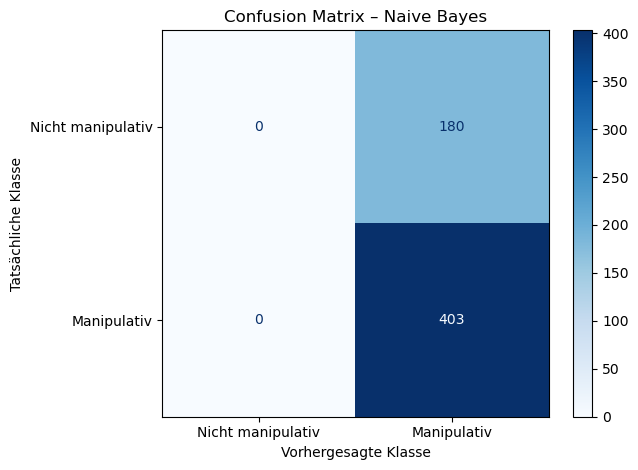

In [58]:
# Konfusionsmatrix darstellen
plot_confusion_matrix(
    y_test,
    y_pred_nb,
    "Naive Bayes"
)

Das Naive-Bayes-Modell zeigt in der vorliegenden Konfiguration keine ausreichende Fähigkeit zur Unterscheidung der beiden Klassen. Wie die Konfusionsmatrix verdeutlicht, werden sämtliche 583 Testdialoge als manipulativ klassifiziert. Dadurch werden zwar alle 403 tatsächlich manipulativen Dialoge erkannt, gleichzeitig jedoch auch alle 180 nicht manipulativen Dialoge fälschlicherweise der positiven Klasse zugeordnet. Der Recall von 1,000 ist daher nicht als Ausdruck einer guten Klassifikationsleistung zu interpretieren, sondern resultiert daraus, dass das Modell ausschließlich die Klasse „manipulativ“ vorhersagt.

Auch die Accuracy und der Micro-F1-Score von jeweils 0,691 vermitteln für sich betrachtet ein zu positives Bild, da ihr Wert im Wesentlichen auf den Anteil manipulativer Dialoge im Testdatensatz zurückzuführen ist. Der deutlich niedrigere Macro-F1-Score von 0,409 bildet die fehlende Klassifikationsleistung für die nicht manipulative Klasse besser ab. Das Modell ist in dieser Konfiguration somit nicht in der Lage, manipulative und nicht manipulative Dialoge sinnvoll voneinander zu unterscheiden. Es dient daher im weiteren Verlauf primär als Baseline für den Vergleich mit den leistungsfähigeren Klassifikationsverfahren.

## 6.3 TF-IDF + Logistische Regression

Als zweites klassisches Klassifikationsverfahren wird die logistische Regression untersucht. Sie eignet sich gut für binäre Klassifikationsaufgaben und kann auch mit hochdimensionalen TF-IDF-Merkmalsräumen effizient eingesetzt werden. Für den Vergleich mit Naive Bayes werden dieselben TF-IDF-repräsentierten Trainings- und Testdaten verwendet.

In [59]:
# Logistische Regression trainieren
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [60]:
# Trainiertes Modell speichern
modellpfad = "./Modelle/logistische_regression"
os.makedirs(modellpfad, exist_ok=True)

joblib.dump(
    lr_model,
    f"{modellpfad}/logistische_regression.joblib"
)

print("Modell der logistischen Regression gespeichert.")

Modell der logistischen Regression gespeichert.


In [ ]:
# Gespeichertes Modell laden
lr_model = joblib.load(
    "./Modelle/logistische_regression/logistische_regression.joblib"
)

print("Gespeichertes Modell der logistischen Regression geladen.")

In [61]:
# Vorhersagen auf den Testdaten
y_pred_lr = lr_model.predict(X_test_tfidf)

Das trainierte Modell wird anschließend auf die Testdaten angewendet. Die Vorhersagen werden anhand derselben Kennzahlen wie beim Naive-Bayes-Modell bewertet und zusätzlich mithilfe der Konfusionsmatrix untersucht.

In [62]:
# Kennzahlen berechnen
berechne_kennzahlen(
    "Logistische Regression",
    y_test,
    y_pred_lr
)

,Precision,Recall,Accuracy,Micro-F1,Macro-F1
Modell,,,,,
Logistische Regression,0.716,0.978,0.717,0.717,0.526


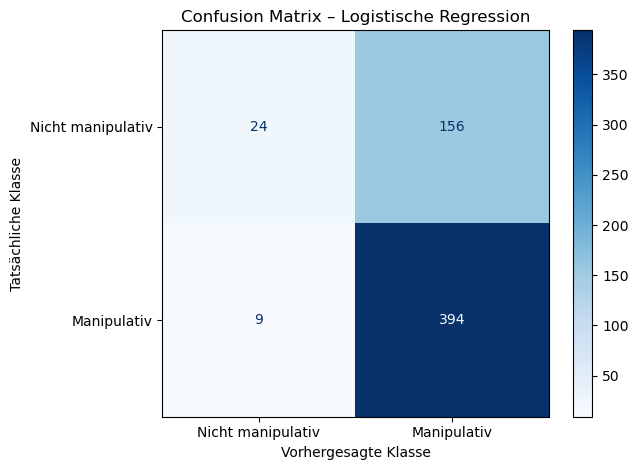

In [63]:
# Konfusionsmatrix darstellen
plot_confusion_matrix(
    y_test,
    y_pred_lr,
    "Logistische Regression"
)

Die logistische Regression erzielt gegenüber dem Naive-Bayes-Modell eine leichte Verbesserung, erreicht insgesamt jedoch weiterhin keine zufriedenstellende Klassifikationsleistung. Die Accuracy und der Micro-F1-Score steigen auf jeweils 0,717 und der Macro-F1-Score verbessert sich von 0,409 auf 0,526. Gleichzeitig bleibt der Recall für manipulative Dialoge mit 0,978 sehr hoch. Die Kennzahlen zeigen damit zwar eine Verbesserung gegenüber Naive Bayes, insbesondere der weiterhin niedrige Macro-F1-Score weist jedoch auf deutliche Unterschiede in der Erkennungsleistung der beiden Klassen hin.

Dies wird durch die Konfusionsmatrix bestätigt. Von den 403 manipulativen Dialogen werden 394 korrekt erkannt und lediglich 9 übersehen. Bei den 180 nicht manipulativen Dialogen werden dagegen nur 24 korrekt klassifiziert, während 156 fälschlicherweise als manipulativ eingestuft werden. Das Modell weist somit weiterhin eine starke Tendenz zur Vorhersage der Klasse „manipulativ“ auf und kann insbesondere nicht manipulative Dialoge nur unzureichend erkennen. Trotz der Verbesserung gegenüber Naive Bayes ist die logistische Regression in der vorliegenden Konfiguration daher noch weit von einer ausgewogenen und zuverlässigen Klassifikation beider Klassen entfernt.

## 6.4 TF-IDF + Linear SVM

Als drittes klassisches Klassifikationsverfahren wird eine lineare Support Vector Machine (Linear SVM) eingesetzt. Wie bei den zuvor untersuchten Modellen werden die bereits erzeugten TF-IDF-Repräsentationen der Trainings- und Testdaten verwendet. Die Linear SVM versucht, eine Entscheidungsgrenze zu bestimmen, welche die beiden Klassen möglichst gut voneinander trennt. Das Modell wird auf den Trainingsdaten trainiert und anschließend auf die Testdaten angewendet.

In [64]:
# Linear-SVM-Modell trainieren
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC(random_state=42)

In [65]:
# Trainiertes Modell speichern
modellpfad = "./Modelle/linear_svm"
os.makedirs(modellpfad, exist_ok=True)

joblib.dump(
    svm_model,
    f"{modellpfad}/linear_svm.joblib"
)

print("Linear-SVM-Modell gespeichert.")

Linear-SVM-Modell gespeichert.


In [ ]:
# Gespeichertes Modell laden
svm_model = joblib.load(
    "./Modelle/linear_svm/linear_svm.joblib"
)

print("Gespeichertes Linear-SVM-Modell geladen.")

In [66]:
# Vorhersagen auf den Testdaten
y_pred_svm = svm_model.predict(X_test_tfidf)

Die auf den Testdaten erzeugten Vorhersagen werden anhand der zuvor festgelegten Kennzahlen bewertet. Ergänzend wird die Verteilung der korrekten und fehlerhaften Klassifikationen mithilfe der Konfusionsmatrix betrachtet.

In [67]:
# Kennzahlen berechnen
berechne_kennzahlen(
    "Linear SVM",
    y_test,
    y_pred_svm
)

,Precision,Recall,Accuracy,Micro-F1,Macro-F1
Modell,,,,,
Linear SVM,0.74,0.841,0.686,0.686,0.594


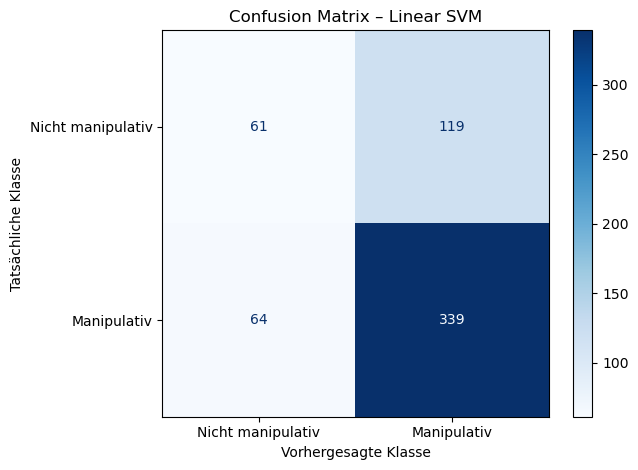

In [68]:
# Konfusionsmatrix darstellen
plot_confusion_matrix(
    y_test,
    y_pred_svm,
    "Linear SVM"
)

Die Linear SVM erreicht eine Accuracy und einen Micro-F1-Score von jeweils 0,686 sowie einen Macro-F1-Score von 0,594. Damit fällt die Accuracy gegenüber der logistischen Regression zwar etwas geringer aus, der für den Modellvergleich zentral betrachtete Macro-F1-Score verbessert sich jedoch von 0,526 auf 0,594. Dies deutet darauf hin, dass die Linear SVM die beiden Klassen ausgewogener klassifiziert. Der Recall der manipulativen Klasse sinkt dabei auf 0,841, sodass 339 der 403 manipulativen Dialoge korrekt erkannt und 64 fälschlicherweise als nicht manipulativ klassifiziert werden.

Die Konfusionsmatrix zeigt jedoch, dass auch die Linear SVM weiterhin deutliche Schwierigkeiten bei der Unterscheidung der beiden Klassen aufweist. Von den 180 nicht manipulativen Dialogen werden 61 korrekt erkannt, während 119 fälschlicherweise als manipulativ klassifiziert werden. Gegenüber Naive Bayes und der logistischen Regression ist die starke Tendenz zur Vorhersage der Klasse „manipulativ“ damit zwar reduziert, eine zuverlässige Trennung der beiden Klassen wird jedoch weiterhin nicht erreicht. Die Verbesserung des Macro-F1-Scores zeigt somit eine ausgewogenere Klassifikationsleistung, die Gesamtleistung bleibt mit einem Macro-F1-Score von 0,594 jedoch weiterhin deutlich verbesserungsfähig.

## 6.5 BERT

Nach den klassischen Klassifikationsverfahren wird mit BERT ein transformerbasiertes Sprachmodell untersucht. Im Gegensatz zu den TF-IDF-basierten Ansätzen verarbeitet BERT die ursprünglichen Dialogtexte direkt und berücksichtigt dabei auch den sprachlichen Kontext. Für das Fine-Tuning werden die bisherigen Trainingsdaten zusätzlich in Trainings- und Validierungsdaten aufgeteilt, während die Testdaten weiterhin ausschließlich für die abschließende Evaluation verwendet werden. Dadurch kann die Modellentwicklung anhand bisher unbekannter Validierungsdaten überwacht und das beste Modell ausgewählt werden, ohne die Testdaten für die Modellauswahl zu verwenden.

In [69]:
# Trainingsdaten zusätzlich in Training und Validation aufteilen
X_train_bert, X_val_bert, y_train_bert, y_val_bert = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Ursprüngliche Dialogtexte verwenden
X_train_bert = df_manip.loc[X_train_bert.index, "Dialogue"]
X_val_bert = df_manip.loc[X_val_bert.index, "Dialogue"]
X_test_bert = df_manip.loc[X_test.index, "Dialogue"]

print(f"Training: {len(X_train_bert)}")
print(f"Validation: {len(X_val_bert)}")
print(f"Test: {len(X_test_bert)}")

Training: 1865
Validation: 467
Test: 583


In [70]:
# BERT-Tokenizer laden
bert_tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

In [71]:
# Texte tokenisieren
train_encodings_bert = bert_tokenizer(
    X_train_bert.tolist(),
    truncation=True,
    padding=True,
    max_length=512,
    return_tensors="pt"
)

val_encodings_bert = bert_tokenizer(
    X_val_bert.tolist(),
    truncation=True,
    padding=True,
    max_length=512,
    return_tensors="pt"
)

test_encodings_bert = bert_tokenizer(
    X_test_bert.tolist(),
    truncation=True,
    padding=True,
    max_length=512,
    return_tensors="pt"
)

In [72]:
# Dataset für Transformer-Modelle definieren
class TextDataset(torch.utils.data.Dataset):
    
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()
    
    def __getitem__(self, idx):
        item = {
            key: value[idx]
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    
    def __len__(self):
        return len(self.labels)

In [73]:
# BERT-Datasets erstellen
train_dataset_bert = TextDataset(
    train_encodings_bert,
    y_train_bert
)

val_dataset_bert = TextDataset(
    val_encodings_bert,
    y_val_bert
)

test_dataset_bert = TextDataset(
    test_encodings_bert,
    y_test
)

In [74]:
# Kennzahlen während des Trainings berechnen
def compute_metrics_transformer(eval_pred):

    predictions, labels = eval_pred
    preds = predictions.argmax(axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "micro_f1": f1_score(labels, preds, average="micro"),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

Die Dialogtexte werden mit dem zu BERT gehörenden Tokenizer verarbeitet und auf eine maximale Länge von 512 Tokens begrenzt. Längere Dialoge werden entsprechend gekürzt. Anschließend werden die tokenisierten Texte gemeinsam mit den zugehörigen Labels in ein für das Transformer-Training geeignetes Dataset überführt. Während des Trainings werden dieselben Evaluationskennzahlen wie bei den zuvor untersuchten Modellen berechnet.

In [75]:
# Vortrainiertes BERT-Modell laden
bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [76]:
# Trainingsparameter festlegen
training_args_bert = TrainingArguments(
    output_dir="./Modelle/bert/checkpoints",

    num_train_epochs=10,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,

    logging_strategy="epoch",
    report_to="none",
    seed=42
)

In [77]:
# BERT-Training mit Early Stopping vorbereiten
bert_trainer = Trainer(
    model=bert_model,
    args=training_args_bert,
    train_dataset=train_dataset_bert,
    eval_dataset=val_dataset_bert,
    compute_metrics=compute_metrics_transformer,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

Für das Fine-Tuning wird das vortrainierte Modell bert-base-uncased um eine Klassifikationsschicht für die beiden Klassen erweitert. Das Training wird für maximal zehn Epochen durchgeführt. Nach jeder Epoche erfolgt eine Evaluation auf den Validierungsdaten. Als Kriterium für die Auswahl des besten Modells wird der Macro-F1-Score verwendet. Zusätzlich kommt Early Stopping zum Einsatz: Verbessert sich der Macro-F1-Score über zwei aufeinanderfolgende Epochen nicht, wird das Training vorzeitig beendet. Auf diese Weise soll eine unnötig lange Trainingsdauer reduziert und das Risiko einer Überanpassung an die Trainingsdaten verringert werden.

In [78]:
# BERT-Modell trainieren
bert_trainer.train()

/home/sagem001/.local/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Micro F1,Macro F1
1,0.595300,0.544033,0.723769,0.724537,0.969040,0.723769,0.554234
2,0.485100,0.563306,0.732334,0.756477,0.904025,0.732334,0.634070
3,0.383900,0.598579,0.732334,0.775000,0.863777,0.732334,0.659488
4,0.276000,0.612154,0.730193,0.803077,0.808050,0.730193,0.682498
5,0.170400,0.748636,0.721627,0.779710,0.832817,0.721627,0.658334
6,0.100800,0.955452,0.728051,0.762032,0.882353,0.728051,0.640963


/home/sagem001/.local/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/sagem001/.local/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/sagem001/.local/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/sagem001/.local/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/sagem001/.local/lib/python3.11/site-packages/torch

TrainOutput(global_step=354, training_loss=0.3352201335174216, metrics={'train_runtime': 150.5046, 'train_samples_per_second': 123.916, 'train_steps_per_second': 3.92, 'total_flos': 2944212709478400.0, 'train_loss': 0.3352201335174216, 'epoch': 6.0})

Das Training wurde nach sechs Epochen durch Early Stopping beendet. Der höchste Macro-F1-Score auf den Validierungsdaten wurde in Epoche 4 mit 0,682 erreicht. Da das Training so konfiguriert ist, dass das beste Modell nach Abschluss automatisch wieder geladen wird, wird für die anschließende Evaluation auf den Testdaten der Modellzustand aus Epoche 4 verwendet.

In [79]:
# Bestes BERT-Modell und Tokenizer speichern
modellpfad = "./Modelle/bert"

bert_trainer.save_model(modellpfad)
bert_tokenizer.save_pretrained(modellpfad)

print("BERT-Modell und Tokenizer gespeichert.")

BERT-Modell und Tokenizer gespeichert.


In [ ]:
# Gespeichertes BERT-Modell und Tokenizer laden
modellpfad = "./Modelle/bert"

bert_tokenizer = BertTokenizer.from_pretrained(modellpfad)

bert_model = BertForSequenceClassification.from_pretrained(
    modellpfad
)

print("Gespeichertes BERT-Modell und Tokenizer geladen.")

In [80]:
# Bestes Modell auf den Testdaten evaluieren
bert_output = bert_trainer.predict(test_dataset_bert)

y_pred_bert = bert_output.predictions.argmax(axis=1)

/home/sagem001/.local/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


In [81]:
# Kennzahlen berechnen
berechne_kennzahlen(
    "BERT",
    y_test,
    y_pred_bert
)

,Precision,Recall,Accuracy,Micro-F1,Macro-F1
Modell,,,,,
BERT,0.822,0.792,0.738,0.738,0.699


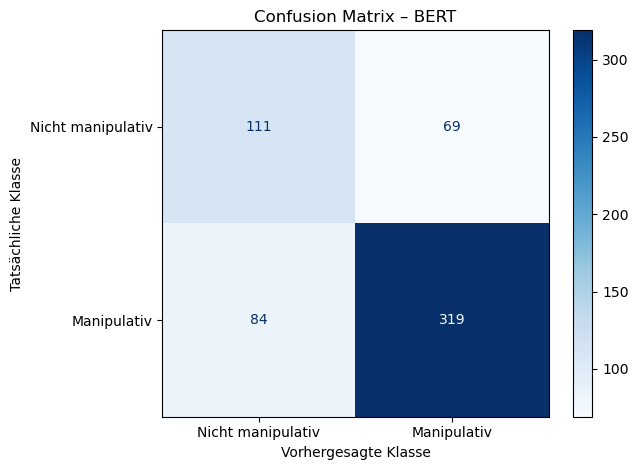

In [82]:
# Konfusionsmatrix darstellen
plot_confusion_matrix(
    y_test,
    y_pred_bert,
    "BERT"
)

Auf den Testdaten erreicht BERT eine Accuracy und einen Micro-F1-Score von jeweils 0,738 sowie einen Macro-F1-Score von 0,699. Damit erzielt das Modell insbesondere hinsichtlich der ausgewogenen Berücksichtigung beider Klassen eine deutlich bessere Klassifikationsleistung als die zuvor untersuchten klassischen Verfahren. Von den 403 manipulativen Dialogen werden 319 korrekt erkannt, während 84 fälschlicherweise als nicht manipulativ klassifiziert werden. Von den 180 nicht manipulativen Dialogen werden 111 korrekt erkannt und 69 fälschlicherweise als manipulativ eingeordnet.

Die Konfusionsmatrix zeigt damit eine wesentlich ausgewogenere Verteilung der Vorhersagen als bei den klassischen Modellen. Insbesondere die Erkennung nicht manipulativer Dialoge verbessert sich deutlich. Gleichzeitig werden weiterhin Fehlklassifikationen in beiden Klassen vorgenommen, sodass auch BERT keine vollständig zuverlässige Trennung erreicht. Der Macro-F1-Score von 0,699 stellt jedoch eine deutliche Verbesserung gegenüber den zuvor untersuchten klassischen Verfahren dar. Eine detaillierte Gegenüberstellung aller Modelle erfolgt in Kapitel 7.

## 6.6 DistilBERT

Als zweites Transformer-basiertes Modell wird DistilBERT eingesetzt. Als kompaktere Variante von BERT ermöglicht es die Untersuchung, inwieweit eine reduzierte Modellkomplexität die Klassifikationsleistung beeinflusst. Für eine möglichst direkte Vergleichbarkeit mit BERT werden dieselben Trainings-, Validierungs- und Testdaten sowie identische grundlegende Trainingsparameter verwendet. Die Dialogtexte werden hierfür mit dem zu DistilBERT gehörenden Tokenizer verarbeitet.

In [83]:
# DistilBERT-Tokenizer laden
distilbert_tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [84]:
# Texte tokenisieren
train_encodings_distilbert = distilbert_tokenizer(
    X_train_bert.tolist(),
    truncation=True,
    padding=True,
    max_length=512,
    return_tensors="pt"
)

val_encodings_distilbert = distilbert_tokenizer(
    X_val_bert.tolist(),
    truncation=True,
    padding=True,
    max_length=512,
    return_tensors="pt"
)

test_encodings_distilbert = distilbert_tokenizer(
    X_test_bert.tolist(),
    truncation=True,
    padding=True,
    max_length=512,
    return_tensors="pt"
)

In [85]:
# DistilBERT-Datasets erstellen
train_dataset_distilbert = TextDataset(
    train_encodings_distilbert,
    y_train_bert
)

val_dataset_distilbert = TextDataset(
    val_encodings_distilbert,
    y_val_bert
)

test_dataset_distilbert = TextDataset(
    test_encodings_distilbert,
    y_test
)

In [86]:
# Vortrainiertes DistilBERT-Modell laden
distilbert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [90]:
# Trainingsparameter festlegen
training_args_distilbert = TrainingArguments(
    output_dir="./Modelle/distilbert/checkpoints",

    num_train_epochs=10,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,

    logging_strategy="epoch",
    report_to="none",
    seed=42
)

Analog zum BERT-Modell werden maximal zehn Trainingsepochen vorgesehen. Nach jeder Epoche erfolgt eine Evaluation auf den Validierungsdaten, wobei der Macro-F1-Score als Kriterium für die Auswahl des besten Modellzustands dient. Durch Early Stopping mit einer Geduld von zwei Epochen wird das Training beendet, wenn sich diese Kennzahl nicht weiter verbessert.

In [91]:
# DistilBERT-Training vorbereiten
distilbert_trainer = Trainer(
    model=distilbert_model,
    args=training_args_distilbert,
    train_dataset=train_dataset_distilbert,
    eval_dataset=val_dataset_distilbert,
    compute_metrics=compute_metrics_transformer,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

In [92]:
# DistilBERT-Modell trainieren
distilbert_trainer.train()

/home/sagem001/.local/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Micro F1,Macro F1
1,0.338600,0.645413,0.747323,0.770449,0.904025,0.747323,0.661644
2,0.217800,0.742475,0.758030,0.779255,0.907121,0.758030,0.678745
3,0.139100,0.794957,0.732334,0.779661,0.854489,0.732334,0.664490
4,0.095000,1.089720,0.743041,0.758270,0.922601,0.743041,0.640972


/home/sagem001/.local/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/sagem001/.local/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/sagem001/.local/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=236, training_loss=0.19764503382020077, metrics={'train_runtime': 52.4265, 'train_samples_per_second': 355.736, 'train_steps_per_second': 11.254, 'total_flos': 988206793973760.0, 'train_loss': 0.19764503382020077, 'epoch': 4.0})

Das Training wird nach vier Epochen durch Early Stopping beendet. Während der Trainingsverlust kontinuierlich sinkt, steigt der Validierungsverlust im weiteren Trainingsverlauf an, was auf eine zunehmende Überanpassung an die Trainingsdaten hindeutet. Der höchste Macro-F1-Score auf den Validierungsdaten wird in Epoche 2 mit rund 0,679 erreicht. Da die Kennzahl in den beiden folgenden Epochen keine weitere Verbesserung zeigt, wird das Training beendet. Für die anschließende Evaluation wird automatisch der Modellzustand aus Epoche 2 geladen.

In [93]:
# Bestes DistilBERT-Modell und Tokenizer speichern
modellpfad = "./Modelle/distilbert"

os.makedirs(modellpfad, exist_ok=True)

distilbert_trainer.save_model(modellpfad)
distilbert_tokenizer.save_pretrained(modellpfad)

print("DistilBERT-Modell und Tokenizer gespeichert.")

DistilBERT-Modell und Tokenizer gespeichert.


In [ ]:
# Gespeichertes DistilBERT-Modell und Tokenizer laden
distilbert_model = DistilBertForSequenceClassification.from_pretrained(
    "./Modelle/distilbert"
)

distilbert_tokenizer = DistilBertTokenizer.from_pretrained(
    "./Modelle/distilbert"
)

distilbert_trainer.model = distilbert_model

print("Gespeichertes DistilBERT-Modell und Tokenizer geladen.")

In [94]:
# Bestes Modell auf den Testdaten evaluieren
distilbert_output = distilbert_trainer.predict(
    test_dataset_distilbert
)

y_pred_distilbert = distilbert_output.predictions.argmax(axis=1)

/home/sagem001/.local/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


In [95]:
# Kennzahlen berechnen
berechne_kennzahlen(
    "DistilBERT",
    y_test,
    y_pred_distilbert
)

,Precision,Recall,Accuracy,Micro-F1,Macro-F1
Modell,,,,,
DistilBERT,0.789,0.888,0.758,0.758,0.69


Auf den Testdaten erreicht DistilBERT eine Accuracy und einen Micro-F1-Score von jeweils 0,758 sowie einen Macro-F1-Score von 0,690. Die Precision für die Klasse „manipulativ“ beträgt 0,789, während der Recall mit 0,888 deutlich höher ausfällt. Damit werden die tatsächlich manipulativen Dialoge überwiegend erkannt. Die Verteilung der korrekten und fehlerhaften Klassifikationen wird im Folgenden anhand der Konfusionsmatrix näher betrachtet.

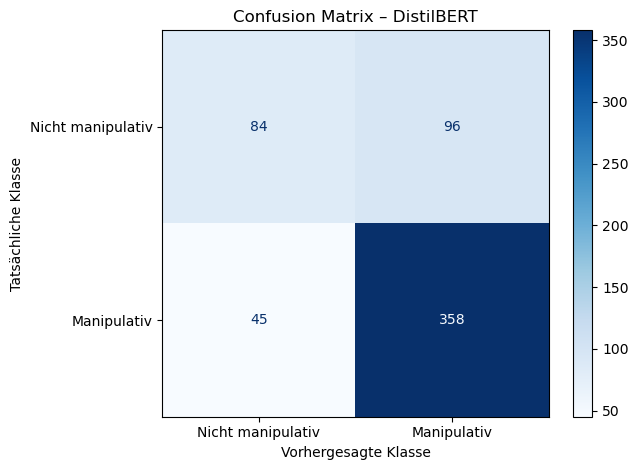

In [96]:
# Konfusionsmatrix darstellen
plot_confusion_matrix(
    y_test,
    y_pred_distilbert,
    "DistilBERT"
)

Die Konfusionsmatrix verdeutlicht die Verteilung der korrekten und fehlerhaften Klassifikationen. Von den 403 tatsächlich manipulativen Dialogen werden 358 korrekt erkannt, während 45 fälschlicherweise als nicht manipulativ klassifiziert werden. Von den 180 nicht manipulativen Dialogen erkennt DistilBERT 84 korrekt; 96 werden dagegen fälschlicherweise der manipulativen Klasse zugeordnet. Das Modell zeigt damit weiterhin eine Tendenz zur Vorhersage der Klasse „manipulativ“, erkennt diese Klasse jedoch mit einem hohen Recall.

Insgesamt erzielt DistilBERT eine deutlich bessere Klassifikationsleistung als die zuvor untersuchten klassischen Verfahren. Im direkten Vergleich mit BERT zeigen sich dagegen unterschiedliche Stärken. DistilBERT erreicht mit 0,758 eine etwas höhere Accuracy als BERT mit 0,738 und erkennt einen größeren Anteil der manipulativen Dialoge. BERT unterscheidet die beiden Klassen hingegen ausgewogener und erzielt mit 0,699 einen geringfügig höheren Macro-F1-Score als DistilBERT mit 0,690. Die geringere Modellkomplexität von DistilBERT führt in diesem Anwendungsfall somit insgesamt nicht zu einer deutlich schlechteren Klassifikationsleistung. Eine zusammenfassende Gegenüberstellung aller untersuchten Modelle erfolgt in Kapitel 7.

# 7. Ergebnisse

Nachdem die einzelnen Klassifikationsmodelle in Kapitel 6 trainiert und evaluiert wurden, werden die erzielten Ergebnisse in diesem Kapitel zusammengeführt und weiterführend analysiert. Dabei steht nicht nur die allgemeine Klassifikationsleistung der Modelle im Mittelpunkt, sondern auch die Frage, in welchen Fällen die automatische Erkennung manipulativer Dialoge an ihre Grenzen stößt.

Hierzu werden zunächst die Ergebnisse der untersuchten Modelle vergleichend gegenübergestellt und anhand der verwendeten Evaluationsmetriken eingeordnet. Anschließend werden die Fehlklassifikationen auf Ebene einzelner Dialoge analysiert, um wiederkehrende Schwierigkeiten und mögliche Ursachen für fehlerhafte Vorhersagen zu identifizieren. Abschließend wird das BERT-Modell mithilfe eines Explainability-Verfahrens näher untersucht, um exemplarisch nachzuvollziehen, welche Bestandteile der Dialoge zu den getroffenen Klassifikationsentscheidungen beitragen.


## 7.1 Vergleich der Klassifikationsmodelle

Zur vergleichenden Bewertung der untersuchten Klassifikationsverfahren werden die in Kapitel 6 ermittelten Kennzahlen in der folgenden Tabelle zusammengeführt. Neben den selbst trainierten Modellen werden zusätzlich die Ergebnisse von Llama-2-13B und RoBERTa-base aus der MentalManip-Veröffentlichung als Referenzwerte dargestellt. Aufgrund der unausgeglichenen Klassenverteilung ist insbesondere der Macro-F1-Score für den Modellvergleich relevant, da hierbei beide Klassen unabhängig von ihrer Häufigkeit gleich gewichtet werden.

In [97]:
# Vergleich aller Modelle darstellen
vergleich = zeige_modellvergleich()

vergleich.style.format({
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "Accuracy": "{:.3f}",
    "Micro-F1": "{:.3f}",
    "Macro-F1": "{:.3f}"
})

,Precision,Recall,Accuracy,Micro-F1,Macro-F1
Modell,,,,,
Naive Bayes,0.691,1.000,0.691,0.691,0.409
Logistische Regression,0.716,0.978,0.717,0.717,0.526
Linear SVM,0.740,0.841,0.686,0.686,0.594
BERT,0.822,0.792,0.738,0.738,0.699
DistilBERT,0.789,0.888,0.758,0.758,0.690
Llama-2-13B (Originalpaper),0.828,0.835,0.768,0.768,0.731
RoBERTa-base (Originalpaper),0.786,0.904,0.766,0.766,0.700


Der Modellvergleich zeigt deutliche Unterschiede hinsichtlich der Fähigkeit, beide Klassen zuverlässig voneinander zu unterscheiden. Besonders auffällig ist das Ergebnis von Naive Bayes. Das Modell erreicht für die manipulative Klasse einen Recall von 1,000 und erkennt damit sämtliche manipulativen Dialoge des Testdatensatzes. Gleichzeitig beträgt der Macro-F1-Score lediglich 0,409. In Verbindung mit den bereits in Kapitel 6 betrachteten Ergebnissen zeigt sich, dass dieser hohe Recall dadurch zustande kommt, dass das Modell sämtliche Dialoge als manipulativ klassifiziert. Die Accuracy von 0,691 vermittelt daher isoliert betrachtet ein zu positives Bild der tatsächlichen Klassifikationsleistung.

Die logistische Regression verbessert die Unterscheidung der Klassen nur begrenzt. Zwar werden mit einem Recall von 0,978 nahezu alle manipulativen Dialoge erkannt, der Macro-F1-Score von 0,526 zeigt jedoch, dass weiterhin eine deutliche Tendenz zur Vorhersage der Mehrheitsklasse besteht. Die Linear SVM erzielt mit einem Macro-F1-Score von 0,594 das beste Ergebnis der drei klassischen Verfahren. Ihr geringerer Recall von 0,841 geht mit einer ausgewogeneren Unterscheidung der beiden Klassen einher. Dennoch bleibt auch ihre Gesamtleistung deutlich hinter den Transformer-basierten Modellen zurück.

Eine deutlich bessere Unterscheidung der beiden Klassen erreichen die Transformer-basierten Modelle. BERT erzielt einen Macro-F1-Score von 0,699, DistilBERT erreicht 0,690. Dabei zeigen sich unterschiedliche Schwerpunkte: BERT weist mit 0,822 die höhere Precision für manipulative Dialoge auf und unterscheidet die beiden Klassen insgesamt etwas ausgewogener. DistilBERT erreicht dagegen mit 0,888 einen höheren Recall und erkennt damit einen größeren Anteil der tatsächlich manipulativen Dialoge, klassifiziert jedoch häufiger nicht manipulative Dialoge fälschlicherweise als manipulativ. Insgesamt liegen beide Modelle trotz ihrer unterschiedlichen Modellgröße auf einem vergleichbaren Leistungsniveau.

Der deutliche Abstand zu den klassischen TF-IDF-basierten Verfahren lässt sich zugleich mit den in Abschnitt 2.3 beschriebenen Eigenschaften des MentalManip-Datensatzes in Verbindung bringen. Bereits die dort dargestellten Analysen zeigen eine starke Überlappung der Repräsentationen manipulativer und nicht manipulativer Dialoge und verdeutlichen die Schwierigkeit einer eindeutigen Abgrenzung [1]. Auch in den eigenen Experimenten erreichen die TF-IDF-basierten Verfahren deutlich geringere Macro-F1-Scores als BERT und DistilBERT. Die Ergebnisse deuten damit darauf hin, dass kontextuelle Sprachrepräsentationen für die Erkennung mentaler Manipulation Vorteile gegenüber den hier untersuchten TF-IDF-basierten Ansätzen bieten.

Die Ergebnisse der selbst trainierten Transformer-Modelle liegen zudem in einer vergleichbaren Größenordnung wie die in der MentalManip-Veröffentlichung berichteten Referenzwerte. BERT erreicht mit einem Macro-F1-Score von 0,699 nahezu den für RoBERTa-base berichteten Wert von 0,700, während DistilBERT mit 0,690 ebenfalls nur geringfügig darunter liegt. Llama-2-13B erzielt mit 0,731 den höchsten Macro-F1-Score der dargestellten Modelle. Ein unmittelbarer Leistungsvergleich ist allerdings nur eingeschränkt möglich, da sich Modellarchitekturen und experimentelle Rahmenbedingungen unterscheiden. Die Referenzwerte dienen daher vor allem dazu, die Größenordnung der eigenen Ergebnisse einzuordnen.

Insgesamt zeigen die Ergebnisse, dass die Erkennung mentaler Manipulation eine anspruchsvolle Klassifikationsaufgabe darstellt. Insbesondere die klassischen TF-IDF-basierten Verfahren stoßen bei der zuverlässigen Unterscheidung der beiden Klassen an Grenzen, während die kontextuelle Sprachrepräsentation der Transformer-Modelle zu deutlich höheren Macro-F1-Scores führt. Gleichzeitig erreichen auch BERT und DistilBERT keine fehlerfreie Trennung der Klassen. Die in Abschnitt 2.4 vorgestellten weiterführenden Ansätze wie Intent-Aware Prompting und MentalMAD setzen ebenfalls an dieser weiterhin bestehenden Herausforderung der zuverlässigen Erkennung mentaler Manipulation an. Die aggregierten Kennzahlen allein erlauben jedoch noch keine Aussage darüber, welche sprachlichen oder inhaltlichen Eigenschaften der Dialoge zu diesen Fehlentscheidungen führen. Daher werden im folgenden Abschnitt die auftretenden Fehlklassifikationen auf Ebene einzelner Dialoge näher untersucht.

## 7.2 Analyse der Klassifikationsfehler

Die aggregierten Kennzahlen ermöglichen einen Vergleich der allgemeinen Klassifikationsleistung, geben jedoch nur begrenzt Aufschluss darüber, welche Dialoge den Modellen besondere Schwierigkeiten bereiten. Daher werden im Folgenden die Vorhersagen der untersuchten Modelle auf Ebene einzelner Testbeispiele betrachtet. Im Mittelpunkt steht dabei die Frage, ob bestimmte Dialoge von mehreren Modellen übereinstimmend falsch klassifiziert werden und welche Fehlermuster insbesondere bei den Transformer-basierten Modellen auftreten.

Für die modellübergreifende Fehleranalyse werden die logistische Regression, die Linear SVM, BERT und DistilBERT berücksichtigt. Die Vorhersagen von Naive Bayes werden zwar im gemeinsamen Datensatz mitgeführt, bei der Berechnung der modellübergreifenden Fehlklassifikationen jedoch nicht berücksichtigt, da das Modell sämtliche Testdialoge der manipulativen Klasse zuordnet und dadurch die Betrachtung gemeinsamer Fehlklassifikationen verzerren würde.

In [99]:
# Fehlklassifikationen der Modelle zusammenführen
fehleranalyse = pd.DataFrame({
    "Dialog": df_manip.loc[X_test.index, "Dialogue"].values,
    "Tatsaechlich": y_test.values,
    "Naive Bayes": y_pred_nb,
    "Logistische Regression": y_pred_lr,
    "Linear SVM": y_pred_svm,
    "BERT": y_pred_bert,
    "DistilBERT": y_pred_distilbert
})

# Modelle für die gemeinsame Fehleranalyse
modellspalten_fehleranalyse = [
    "Logistische Regression",
    "Linear SVM",
    "BERT",
    "DistilBERT"
]

# Anzahl falscher Vorhersagen je Dialog
fehleranalyse["Anzahl_Fehler"] = sum(
    fehleranalyse[modell] != fehleranalyse["Tatsaechlich"]
    for modell in modellspalten_fehleranalyse
)

fehleranalyse.head()

,Dialog,Tatsaechlich,Naive Bayes,Logistische Regression,Linear SVM,BERT,DistilBERT,Anzahl_Fehler
0,Person1: It's a two-hundred dollar fine!\nPers...,0,1,1,1,0,0,2
1,Person1: Remember that guy in the cell next to...,0,1,0,0,0,0,0
2,Person1: That's right. That's what I said. You...,1,1,1,1,1,1,0
3,"Person1: Yes. That's true. Actually, at this...",1,1,1,1,1,1,0
4,Person1: It's a fake.\nPerson2: Give him the c...,1,1,1,1,0,0,2


In [100]:
# Verteilung der Anzahl gleichzeitig falscher Modelle
fehlerverteilung = (
    fehleranalyse["Anzahl_Fehler"]
    .value_counts()
    .sort_index()
    .rename_axis("Anzahl falsch klassifizierender Modelle")
    .reset_index(name="Anzahl Dialoge")
)

fehlerverteilung

,Anzahl falsch klassifizierender Modelle,Anzahl Dialoge
0,0,284
1,1,110
2,2,87
3,3,50
4,4,52


Die Auswertung zeigt, dass 284 der 583 Testdialoge (48,7 %) von allen vier in die gemeinsame Fehleranalyse einbezogenen Modellen korrekt klassifiziert werden. Bei einem Teil der Dialoge treten jedoch modellübergreifende Schwierigkeiten auf. 50 Dialoge werden von drei der vier Modelle und weitere 52 Dialoge von allen vier Modellen falsch klassifiziert. Insgesamt werden damit 102 Testdialoge (17,5 %) von mindestens drei der vier Modelle fehlerhaft eingeordnet. Dies deutet darauf hin, dass bestimmte Dialoge für unterschiedliche Klassifikationsansätze gleichermaßen schwer einzuordnen sind. Diese Fälle werden im Folgenden näher untersucht.

In [101]:
# Dialoge anzeigen, die von den meisten Modellen falsch klassifiziert wurden
schwierige_dialoge = fehleranalyse[
    fehleranalyse["Anzahl_Fehler"] >= 3
].copy()

print("Anzahl besonders schwieriger Dialoge:", len(schwierige_dialoge))

schwierige_dialoge[
    [
        "Dialog",
        "Tatsaechlich",
        "Naive Bayes",
        "Logistische Regression",
        "Linear SVM",
        "BERT",
        "DistilBERT",
        "Anzahl_Fehler"
    ]
].head(10)

Anzahl besonders schwieriger Dialoge: 102


,Dialog,Tatsaechlich,Naive Bayes,Logistische Regression,Linear SVM,BERT,DistilBERT,Anzahl_Fehler
12,Person1: Having fun yet? No? I'll give you a...,1,1,0,0,1,0,3
14,"Person1: See, in that crisis, I saw an opportu...",0,1,1,1,0,1,3
21,Person1: Dolores.\nPerson2: Yes. Dolores...an...,0,1,1,1,1,1,4
27,Person1: I don't want to hit you in the stomac...,0,1,1,1,1,1,4
31,Person1: It's time to go home now.\nPerson2: N...,0,1,1,1,1,0,3
35,"Person1: Dad, please stop. Please. I'm sure ...",0,1,1,1,0,1,3
37,"Person1: Are you crazy, a lift raft?! We're no...",0,1,1,1,0,1,3
63,"Person1: This was my first classroom, John, di...",0,1,1,1,1,1,4
64,Person1: I know why most of you are here. We'r...,0,1,1,1,1,1,4
65,Person1: Your money may have been well investe...,0,1,1,1,1,1,4


In [102]:
# Schwierige False Positives
schwierige_fp = schwierige_dialoge[
    schwierige_dialoge["Tatsaechlich"] == 0
].copy()

# Schwierige False Negatives
schwierige_fn = schwierige_dialoge[
    schwierige_dialoge["Tatsaechlich"] == 1
].copy()

print("Schwierige False Positives:", len(schwierige_fp))
print("Schwierige False Negatives:", len(schwierige_fn))

Schwierige False Positives: 91
Schwierige False Negatives: 11


Von den 102 Dialogen, die von mindestens drei der vier Modelle falsch klassifiziert werden, entfallen 91 auf False Positives und lediglich 11 auf False Negatives. Die modellübergreifenden Schwierigkeiten betreffen damit überwiegend nicht manipulative Dialoge, die fälschlicherweise als manipulativ eingeordnet werden. Damit bestätigt sich auch bei den besonders schwierigen Dialogen die bereits im Modellvergleich beobachtete Tendenz zur Vorhersage der Klasse „manipulativ“.

In [103]:
# Beispiele schwieriger False Positives
for idx, row in schwierige_fp.head(5).iterrows():
    print("=" * 100)
    print(f"FALSE POSITIVE – Dialog {idx}")
    print(f"Anzahl falscher Modelle: {row['Anzahl_Fehler']}")
    print("-" * 100)
    print(row["Dialog"])
    print()


# Beispiele schwieriger False Negatives
for idx, row in schwierige_fn.head(5).iterrows():
    print("=" * 100)
    print(f"FALSE NEGATIVE – Dialog {idx}")
    print(f"Anzahl falscher Modelle: {row['Anzahl_Fehler']}")
    print("-" * 100)
    print(row["Dialog"])
    print()

FALSE POSITIVE – Dialog 14
Anzahl falscher Modelle: 3
----------------------------------------------------------------------------------------------------
Person1: See, in that crisis, I saw an opportunity.  For some real growth.
Person2: Oh please.
Person1: Be quiet. I didn't go behind your back.

FALSE POSITIVE – Dialog 21
Anzahl falscher Modelle: 4
----------------------------------------------------------------------------------------------------
Person1: Dolores.
Person2: Yes.  Dolores...and even your mom and dad.  But I'll make sure you go last.
Person1: Why?
Person2: So you can keep on getting well before you have to go and do this. It's not going to be easy, Nicole. Do you understand that?

FALSE POSITIVE – Dialog 27
Anzahl falscher Modelle: 4
----------------------------------------------------------------------------------------------------
Person1: I don't want to hit you in the stomach!
Person2: You're not gonna hurt me. Just hit me in the stomach.
Person1: Look, Marty, I'm

Die ausgegebenen False Positives verdeutlichen, dass hierfür insbesondere sprachlich auffällige Gesprächssituationen problematisch sein können. In Dialog 27 findet beispielsweise eine direkte Auseinandersetzung statt, in der eine Person ankündigt, die andere nicht schlagen zu wollen, während die Antwort ausdrücklich zum Schlagen auffordert. Obwohl der Dialog im Datensatz als nicht manipulativ gekennzeichnet ist, enthält er damit aggressive und direktive Formulierungen, die von den Modellen offenbar mit manipulativer Kommunikation in Verbindung gebracht werden. Auch Dialog 21 enthält mit der Aussage, eine Person werde „als Letzte gehen“, eine Formulierung, die isoliert betrachtet als Druckausübung oder Drohung interpretiert werden könnte. Tatsächlich wird dieser Dialog von allen vier betrachteten Modellen fälschlicherweise der manipulativen Klasse zugeordnet. Die Beispiele zeigen damit, dass konfliktbehaftete oder direktive Sprache allein kein eindeutiges Merkmal für Manipulation darstellt.

Ein anderes Muster zeigt sich bei den False Negatives. In Dialog 149 wird wiederholt nach der emotionalen Bindung des Gegenübers gefragt und mehrfach die Frage gestellt, ob die andere Person den Sprecher liebe. Die als manipulativ gekennzeichnete Kommunikation ist dabei weniger durch einzelne auffällige Begriffe als durch die wiederholten Nachfragen und den Verlauf der Interaktion geprägt. Drei der vier Modelle erkennen den Dialog dennoch nicht als manipulativ. Dies deutet darauf hin, dass Manipulation, die sich erst aus dem Zusammenspiel mehrerer Äußerungen ergibt, schwieriger zu erfassen sein kann.

Besonders deutlich wird die Bedeutung des Kontexts bei Dialog 163. Einzelne Äußerungen wirken zunächst wie ein gewöhnliches Gespräch über Familienmitglieder und deren Eigenschaften. Aus dem Wortlaut allein ist nur schwer unmittelbar abzuleiten, weshalb der Dialog im Datensatz als manipulativ gekennzeichnet wurde. Dass drei der vier Modelle diesen Dialog nicht als manipulativ erkennen, kann daher sowohl auf die Schwierigkeit hinweisen, über mehrere Äußerungen verteilte kommunikative Zusammenhänge zu erfassen, als auch auf die grundsätzliche Herausforderung einer eindeutigen Abgrenzung manipulativer Kommunikation.

Insgesamt verdeutlichen die Beispiele, dass die Fehlklassifikationen nicht auf ein einzelnes sprachliches Muster zurückgeführt werden können. Bei den False Positives scheinen insbesondere aggressive, konfliktbezogene oder direktive Formulierungen zu einer fälschlichen Zuordnung zur manipulativen Klasse beizutragen. Bei den False Negatives ist die als manipulativ gekennzeichnete Kommunikation dagegen teilweise erst aus Wiederholungen, dem Gesprächsverlauf oder dem Zusammenspiel mehrerer Äußerungen erkennbar. Auffällig ist zudem die große Unterschiedlichkeit der betrachteten Dialoge hinsichtlich ihrer Länge, der Anzahl der Gesprächsbeiträge und ihrer sprachlichen Ausgestaltung. Die Schwierigkeiten der Modelle treten somit sowohl bei kurzen, sprachlich auffälligen als auch bei längeren und stärker kontextabhängigen Dialogen auf. Die Ergebnisse deuten damit darauf hin, dass für die Abgrenzung manipulativer Kommunikation das Erkennen einzelner auffälliger Formulierungen allein nicht ausreichend ist. Dass auch BERT und DistilBERT einige dieser Dialoge gemeinsam mit den klassischen Verfahren falsch klassifizieren, verdeutlicht, dass die untersuchte Klassifikationsaufgabe auch für kontextbasierte Transformer-Modelle herausfordernd bleibt.

## 7.3 Explainability-Analyse des BERT-Modells

Die bisherige Evaluation zeigt, wie zuverlässig die untersuchten Modelle manipulative und nicht manipulative Dialoge klassifizieren. Sie gibt jedoch keinen Aufschluss darüber, welche Bestandteile eines Dialogs für eine konkrete Modellentscheidung ausschlaggebend sind. Ergänzend zur Fehleranalyse wird daher im Folgenden exemplarisch untersucht, auf welche Tokens sich die Vorhersagen des BERT-Modells stützen.

Hierzu wird das Explainability-Verfahren Integrated Gradients verwendet. Das Verfahren weist den einzelnen Eingabetokens Attributionswerte zu, die ihren Beitrag zur jeweils betrachteten Modellvorhersage beschreiben. Für die Analyse wird jeweils die vom Modell vorhergesagte Klasse als Zielklasse betrachtet. Positive Attributionswerte unterstützen dabei die Ausgabe des Modells für diese Klasse, während negative Werte dieser entgegenwirken. Die Analyse erfolgt auf der Embedding-Schicht des trainierten BERT-Modells. Ziel ist dabei nicht, allgemeingültige Entscheidungsregeln des Modells abzuleiten, sondern anhand ausgewählter Beispiele einen Einblick in einzelne Klassifikationsentscheidungen zu erhalten.

In [134]:
# BERT-Ergebnisse für die Explainability-Analyse vorbereiten
df_bert_analysis = pd.DataFrame({
    "Text": X_test_bert.values,
    "True_Label": y_test.values,
    "Pred_Label": y_pred_bert
})

In [135]:
# Klassifikationsergebnis bestimmen
def classify_result(row):
    if row["True_Label"] == 1 and row["Pred_Label"] == 1:
        return "True Positive"
    elif row["True_Label"] == 0 and row["Pred_Label"] == 0:
        return "True Negative"
    elif row["True_Label"] == 0 and row["Pred_Label"] == 1:
        return "False Positive"
    else:
        return "False Negative"


df_bert_analysis["Ergebnis"] = df_bert_analysis.apply(
    classify_result,
    axis=1
)

df_bert_analysis["Ergebnis"].value_counts()

Ergebnis
True Positive     319
True Negative     111
False Negative     84
False Positive     69
Name: count, dtype: int64

Für die Explainability-Analyse werden die Vorhersagen des BERT-Modells zunächst den vier möglichen Klassifikationsergebnissen zugeordnet. Von den 583 Testdialogen entfallen 319 auf True Positives, 111 auf True Negatives, 69 auf False Positives und 84 auf False Negatives. Um sowohl korrekte als auch fehlerhafte Modellentscheidungen zu betrachten, wird im Folgenden exemplarisch jeweils ein Dialog aus diesen vier Kategorien untersucht.

In [136]:
# Trainiertes BERT-Modell für die Explainability verwenden
bert_explain_model = bert_trainer.model
bert_explain_model.eval()

device = next(bert_explain_model.parameters()).device

In [137]:
# Modellvorhersage für Integrated Gradients
def bert_forward(input_ids, attention_mask, target_class):
    outputs = bert_explain_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    return outputs.logits[:, target_class]

In [138]:
# Integrated Gradients auf der Embedding-Schicht vorbereiten
lig = LayerIntegratedGradients(
    bert_forward,
    bert_explain_model.bert.embeddings
)

In [139]:
# Einzelnen Dialog mithilfe von Integrated Gradients erklären
def explain_bert_text(text, target_class):

    encoding = bert_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    # Baseline aus PAD-Tokens erstellen
    baseline_ids = torch.full_like(
        input_ids,
        bert_tokenizer.pad_token_id
    )

    # CLS- und SEP-Token beibehalten
    baseline_ids[:, 0] = bert_tokenizer.cls_token_id
    baseline_ids[:, -1] = bert_tokenizer.sep_token_id

    # Attributionen berechnen
    attributions, delta = lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        additional_forward_args=(
            attention_mask,
            target_class
        ),
        n_steps=50,
        internal_batch_size=1,
        return_convergence_delta=True
    )

    # Embedding-Dimension zusammenfassen
    attributions = attributions.sum(dim=-1).squeeze(0)

    # Attributionen normalisieren
    norm = torch.norm(attributions)

    if norm.item() != 0:
        attributions = attributions / norm

    tokens = bert_tokenizer.convert_ids_to_tokens(
        input_ids.squeeze(0).detach().cpu().tolist()
    )

    result = pd.DataFrame({
        "Token": tokens,
        "Attribution": attributions.detach().cpu().numpy()
    })

    # Spezielle Tokens entfernen
    result = result[
        ~result["Token"].isin(["[CLS]", "[SEP]", "[PAD]"])
    ].copy()

    result["Absoluter_Einfluss"] = result["Attribution"].abs()

    return result, delta.detach().cpu().numpy()

Für die nachfolgende Analyse wird aus jeder der vier Kategorien True Positive, True Negative, False Positive und False Negative jeweils ein exemplarischer Dialog ausgewählt. Die Auswahl dient dazu, unterschiedliche Modellentscheidungen anhand geeigneter Beispiele qualitativ zu veranschaulichen und stellt keine repräsentative Stichprobe der jeweiligen Kategorie dar. Anschließend werden für die vorhergesagte Klasse die Token-Attributionen mithilfe von Integrated Gradients berechnet.

In [140]:
# Exemplarische Fälle für die Explainability-Analyse auswählen
beispiel_tp = df_bert_analysis.loc[2]
beispiel_tn = df_bert_analysis.loc[6]
beispiel_fp = df_bert_analysis.loc[63]
beispiel_fn = df_bert_analysis.loc[25]

In [141]:
# Ausgewählte Beispiele vollständig anzeigen
for ergebnis, beispiel in [
    ("True Positive", beispiel_tp),
    ("True Negative", beispiel_tn),
    ("False Positive", beispiel_fp),
    ("False Negative", beispiel_fn)
]:
    print("=" * 100)
    print(ergebnis)
    print("=" * 100)
    print(beispiel["Text"])
    print()

True Positive
Person1: That's right. That's what I said. You have a good memory. Then what?
Person2: Well.
Person1: THEN WHAT?
Person2: Then you got undressed.
Person1: How many times have you sneaked into girls' apartments and watched them undress?
Person2: Never before this.
Person1: How'd you like it if someone sneaked into your house and watched you.  Get undressed. I want to see you.
Person2: No. Come on.
Person1: NO, you come on. Take off your pants. I want to see you.
Person2: Look. I'm sorry. Just let me leave.
Person1: No way.

True Negative
Person1: Do you always drive like this?
Person2: Yes.

False Positive
Person1: This was my first classroom, John, did you know that?  My first desk.
Person2: I didn't know you taught.
Person1: English.  Way before your time.  It was hard giving it up, I'll tell you.  I'm hearing rumors, John, of some unusual teaching methods in your classroom.  I'm not saying they have anything to do with the Dalton boy's outburst, but I don't think I have

In [142]:
# Attributionen für die vier Klassifikationsfälle berechnen
explainability_ergebnisse = {}

beispiele = {
    "True Positive": beispiel_tp,
    "True Negative": beispiel_tn,
    "False Positive": beispiel_fp,
    "False Negative": beispiel_fn
}

for ergebnis_typ, beispiel in beispiele.items():

    target_class = int(beispiel["Pred_Label"])

    attributionen, delta = explain_bert_text(
        beispiel["Text"],
        target_class
    )

    explainability_ergebnisse[ergebnis_typ] = {
        "Text": beispiel["Text"],
        "True_Label": int(beispiel["True_Label"]),
        "Pred_Label": int(beispiel["Pred_Label"]),
        "Attributionen": attributionen,
        "Delta": delta
    }

In [143]:
# Wichtigste Tokens der vier Beispiele anzeigen
for ergebnis_typ in [
    "True Positive",
    "True Negative",
    "False Positive",
    "False Negative"
]:
    print("=" * 80)
    print(ergebnis_typ)
    print("=" * 80)

    display(
        explainability_ergebnisse[ergebnis_typ]["Attributionen"]
        .sort_values(
            "Absoluter_Einfluss",
            ascending=False
        )
        .head(15)
    )

True Positive


,Token,Attribution,Absoluter_Einfluss
148,no,0.519320,0.519320
139,.,0.229130,0.229130
140,just,0.224769,0.224769
73,##1,0.206116,0.206116
91,.,0.182999,0.182999
93,und,-0.177927,0.177927
129,.,-0.167886,0.167886
100,you,0.161803,0.161803
42,und,-0.155824,0.155824
144,.,0.150046,0.150046


True Negative


,Token,Attribution,Absoluter_Einfluss
2,##1,0.489498,0.489498
1,person,0.435534,0.435534
4,do,0.391202,0.391202
8,like,-0.373210,0.373210
3,:,0.346811,0.346811
5,you,0.274972,0.274972
10,?,-0.150458,0.150458
7,drive,0.142858,0.142858
12,##2,0.128108,0.128108
15,.,-0.108432,0.108432


False Positive


,Token,Attribution,Absoluter_Einfluss
70,classroom,0.270640,0.270640
240,!,0.228973,0.228973
116,##and,0.207478,0.207478
115,##rim,0.181461,0.181461
109,.,-0.177809,0.177809
5,was,-0.168844,0.168844
102,boys,-0.167217,0.167217
113,your,0.164227,0.164227
125,.,-0.163244,0.163244
193,.,0.141373,0.141373


False Negative


,Token,Attribution,Absoluter_Einfluss
316,dave,-0.273082,0.273082
70,orleans,-0.234550,0.234550
266,.,0.200851,0.200851
22,dave,0.168489,0.168489
17,:,-0.141714,0.141714
58,we,-0.132671,0.132671
57,.,0.128889,0.128889
329,texas,-0.127781,0.127781
33,friday,-0.123748,0.123748
261,.,0.119980,0.119980


Die Attributionswerte zeigen ein insgesamt wenig eindeutiges Bild. Entgegen der Erwartung finden sich unter den einflussreichsten Tokens nur wenige Begriffe, die sich unmittelbar mit manipulativer Kommunikation in Verbindung bringen lassen. Stattdessen weisen häufig Satzzeichen, durch die Tokenisierung entstandene Wortfragmente wie „##1“, „##2“, „##and“ oder „##rim“, Sprecherkennzeichnungen wie „person“ sowie kontextspezifische Begriffe hohe Attributionswerte auf. So besitzt beim True Positive das Token „no“ den stärksten positiven Einfluss auf die Vorhersage der manipulativen Klasse, während daneben unter anderem Satzzeichen und Wortfragmente eine vergleichsweise hohe Bedeutung erhalten. Beim False Positive zählen mit „classroom“ und „education“ ebenfalls Begriffe zu den stärker positiv beitragenden Tokens, die isoliert betrachtet keinen erkennbaren Bezug zu Manipulation aufweisen. Ähnliches zeigt sich beim False Negative, bei dem beispielsweise die Eigennamen und Ortsbezeichnungen „Dave“, „Orleans“ und „Texas“ einen hohen Einfluss besitzen.

Eine eindeutige inhaltliche Interpretation der Modellentscheidungen ist anhand der betrachteten Attributionswerte daher nur eingeschränkt möglich. Insbesondere lässt sich kein klares Muster erkennen, nach dem BERT bestimmte Wörter oder Formulierungen systematisch als Hinweise auf manipulative Kommunikation verwendet. Die Ergebnisse zeigen vielmehr, dass auch scheinbar unauffällige oder für die eigentliche Klassifikationsaufgabe wenig aussagekräftige Tokens einen vergleichsweise hohen Einfluss auf einzelne Vorhersagen haben können. Die Explainability-Analyse macht damit einerseits sichtbar, welche Bestandteile für konkrete Modellentscheidungen relevant sind, zeigt andererseits aber auch die Grenzen einer isolierten Betrachtung einzelner Tokens. Die Entscheidung des Modells lässt sich nicht ohne Weiteres auf wenige sprachlich nachvollziehbare Schlüsselmerkmale reduzieren.

In [144]:
# Convergence Delta der vier Beispiele anzeigen
for ergebnis_typ in [
    "True Positive",
    "True Negative",
    "False Positive",
    "False Negative"
]:
    delta = explainability_ergebnisse[ergebnis_typ]["Delta"]

    print(
        f"{ergebnis_typ}: "
        f"{float(delta.squeeze()):.6f}"
    )

True Positive: -0.153542
True Negative: 0.004160
False Positive: -0.201342
False Negative: 0.037099


Ergänzend wird das Convergence Delta betrachtet, das eine Einschätzung der numerischen Zuverlässigkeit der mit Integrated Gradients berechneten Attributionswerte ermöglicht. Vereinfacht ausgedrückt wird dabei geprüft, wie gut die Summe der ermittelten Tokenbeiträge die Veränderung der Modellvorhersage zwischen der gewählten Baseline und der tatsächlichen Eingabe abbildet. Bei einer idealen Berechnung stimmen beide Größen weitgehend überein, sodass das Convergence Delta nahe null liegt. Je größer der Betrag des Convergence Delta ausfällt, desto stärker ist die Abweichung, sodass die berechneten Attributionswerte vorsichtiger interpretiert werden sollten.

Für die vier untersuchten Beispiele zeigen sich dabei deutliche Unterschiede. Beim True Negative liegt das Convergence Delta mit 0,004 sehr nahe bei null. Auch beim False Negative fällt die Abweichung mit 0,037 vergleichsweise gering aus. Beim True Positive beträgt der Wert dagegen −0,154 und beim False Positive −0,201. Für diese beiden Beispiele bildet die Summe der berechneten Attributionen die Veränderung der Modellvorhersage somit weniger genau ab. Die Attributionsergebnisse dieser Beispiele sollten daher mit zusätzlicher Vorsicht interpretiert werden. Dies gilt insbesondere vor dem Hintergrund, dass bereits die inhaltliche Betrachtung hohe Attributionswerte für Satzzeichen, Wortfragmente und kontextspezifische Begriffe gezeigt hat.

Nachdem die Token-Attributionen zunächst tabellarisch betrachtet und mithilfe des Convergence Delta hinsichtlich ihrer numerischen Zuverlässigkeit eingeordnet wurden, werden die einflussreichsten Tokens im Folgenden zusätzlich grafisch dargestellt. Die Visualisierung erleichtert insbesondere den Vergleich der Stärke und Richtung der Attributionswerte. Positive Werte unterstützen dabei die jeweils vorhergesagte Klasse, während negative Werte gegen diese Vorhersage wirken.

In [145]:
# Wichtigste Token-Attributionen übersichtlich visualisieren
def plot_token_attributions(ergebnis_typ, top_n=10):

    daten = explainability_ergebnisse[
        ergebnis_typ
    ]["Attributionen"].copy()

    # Tokenposition ergänzen, damit gleiche Tokens unterscheidbar bleiben
    daten["Token_Anzeige"] = (
        daten["Token"] + " [" + daten.index.astype(str) + "]"
    )

    daten = (
        daten
        .sort_values("Absoluter_Einfluss", ascending=False)
        .head(top_n)
        .sort_values("Attribution")
    )

    plt.figure(figsize=(9, 5))

    plt.barh(
        daten["Token_Anzeige"],
        daten["Attribution"]
    )

    plt.axvline(
        0,
        color="black",
        linewidth=1
    )

    plt.title(
        f"Wichtigste Token-Attributionen – {ergebnis_typ}"
    )

    plt.xlabel("Attribution zur vorhergesagten Klasse")
    plt.ylabel("Token [Position]")

    plt.tight_layout()
    plt.show()

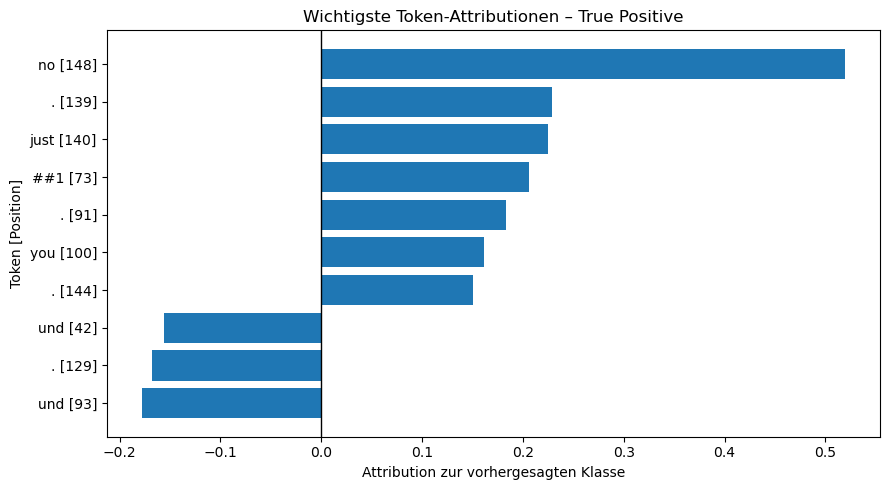

In [146]:
plot_token_attributions("True Positive")

Beim True Positive wird die Vorhersage der manipulativen Klasse besonders stark durch das Token „no“ unterstützt. Dies lässt sich im Kontext des Dialogs nachvollziehen, da die Interaktion mehrfach durch Zurückweisung, Aufforderungen und die Missachtung des geäußerten Widerstands geprägt ist. Gleichzeitig zeigen die Attributionen, dass neben inhaltlich interpretierbaren Tokens auch Satzzeichen und Teilwörter einen relevanten Einfluss besitzen. Die Modellentscheidung kann daher nicht auf ein einzelnes sprachliches Merkmal reduziert werden.

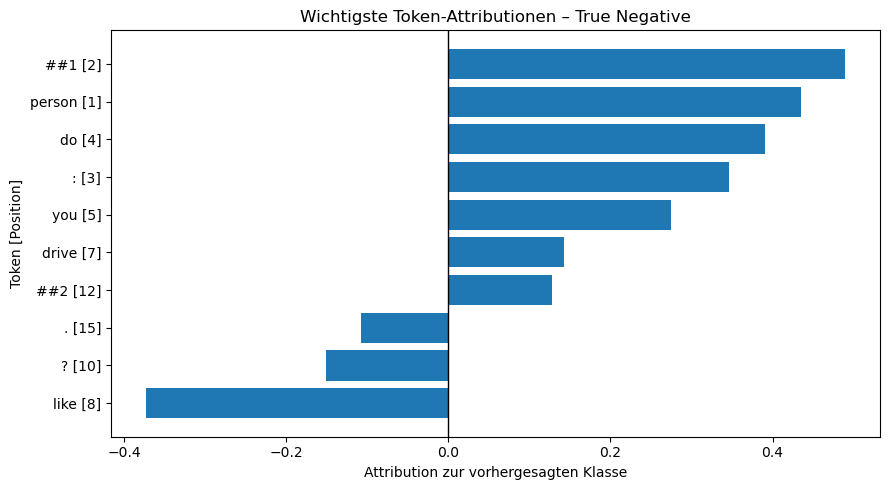

In [147]:
plot_token_attributions("True Negative")

Beim True Negative ist aufgrund des sehr kurzen Dialogs keine vergleichbar eindeutige inhaltliche Interpretation der Attributionen möglich. Die stärksten positiven Beiträge zur vorhergesagten nicht manipulativen Klasse stammen überwiegend von allgemeinen Wörtern wie „do“ und „you“ sowie von Bestandteilen der Sprecherkennzeichnung wie „person“ und „##1“. Das Token „like“ wirkt dagegen vergleichsweise stark gegen die vorhergesagte Klasse. Inhaltlich auffällige manipulative Formulierungen sind in dem kurzen Dialog nicht vorhanden. Das Beispiel verdeutlicht damit zugleich eine Grenze der tokenbasierten Erklärung: Ein hoher Attributionswert bedeutet nicht zwangsläufig, dass das betreffende Token für sich genommen eine semantisch nachvollziehbare Erklärung für die Modellentscheidung liefert.

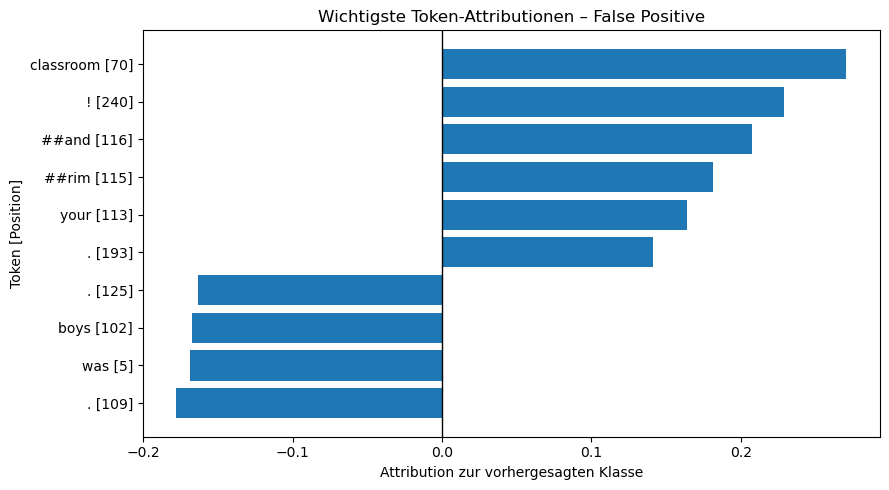

In [148]:
plot_token_attributions("False Positive")

Beim False Positive ordnet BERT einen tatsächlich nicht manipulativen Dialog der manipulativen Klasse zu. Den stärksten positiven Beitrag zur Modellentscheidung liefert das Token „classroom“. Daneben weisen unter anderem das Satzzeichen „!“ sowie die durch die Tokenisierung entstandenen Wortfragmente „##rim“ und „##and“ vergleichsweise hohe positive Attributionswerte auf. Eine eindeutige sprachliche Ursache für die Fehlklassifikation lässt sich daraus nicht ableiten. Inhaltlich enthält der Dialog jedoch eine konflikthafte Diskussion über Autorität, Disziplin und unterschiedliche Vorstellungen von Unterricht. Dies passt zu der bereits in Abschnitt 7.2 beobachteten Schwierigkeit, konfliktbezogene oder direktive Gesprächssituationen zuverlässig von manipulativer Kommunikation abzugrenzen.

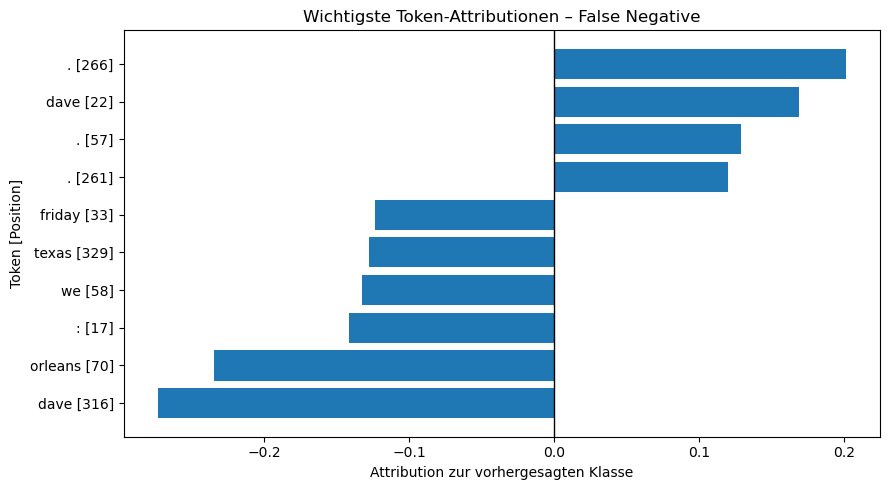

In [149]:
plot_token_attributions("False Negative")

Beim False Negative wird ein als manipulativ gekennzeichneter Dialog vom Modell der nicht manipulativen Klasse zugeordnet. Unter den Tokens mit hohen Attributionswerten befinden sich vor allem Eigennamen, Ortsangaben und weitere kontextspezifische Begriffe wie „Dave“, „Orleans“ und „Texas“. Diese besitzen isoliert betrachtet keinen offensichtlichen Bezug zur Zielklasse. Die Attributionen liefern damit keinen eindeutigen Hinweis darauf, dass für die Annotation relevante manipulative Merkmale einen entscheidenden Einfluss auf die Modellvorhersage hatten. Dies könnte dazu beigetragen haben, dass der Dialog vom Modell der nicht manipulativen Klasse zugeordnet wurde.

Die Ergebnisse der Explainability-Analyse fallen insgesamt weniger eindeutig aus als erwartet. Ziel der Analyse war es, anhand der Token-Attributionen besser nachvollziehen zu können, auf welche sprachlichen Bestandteile sich die Entscheidungen des BERT-Modells stützen. Zwar lassen sich bei einzelnen Beispielen inhaltlich plausible Einflüsse erkennen, insgesamt gehören zu den einflussreichsten Tokens jedoch häufig auch Satzzeichen, allgemeine Wörter, durch die Tokenisierung entstandene Wortfragmente sowie Eigennamen und Ortsbezeichnungen. Insbesondere bei den Fehlklassifikationen ergeben sich dadurch kaum eindeutige sprachliche Hinweise darauf, weshalb das Modell einen Dialog der manipulativen oder nicht manipulativen Klasse zuordnet. Die Attributionen ermöglichen somit zwar einen Einblick in einzelne Modellentscheidungen, liefern für die untersuchten Beispiele jedoch nur eingeschränkt die erhoffte inhaltlich nachvollziehbare Erklärung.

Die Analyse verdeutlicht zugleich die Grenzen einer rein tokenbasierten Erklärung bei der Erkennung manipulativer Kommunikation. Wie bereits die Fehleranalyse gezeigt hat, kann sich Manipulation aus dem Zusammenspiel mehrerer Äußerungen und dem Verlauf eines Dialogs ergeben. Einzelne Token-Attributionen können Hinweise auf die Modellentscheidung liefern, bilden solche übergeordneten kommunikativen Zusammenhänge jedoch nur eingeschränkt ab. Die Ergebnisse der Explainability-Analyse sind daher als exemplarische Einblicke in einzelne Vorhersagen und nicht als vollständige Erklärung des Entscheidungsverhaltens von BERT zu verstehen.

# 8. Diskussion und Fazit

Ziel dieser Arbeit war es, die automatische Erkennung mentaler Manipulation in Dialogen anhand des MentalManip-Datensatzes zu untersuchen und klassische TF-IDF-basierte Klassifikationsverfahren mit Transformer-basierten Sprachmodellen zu vergleichen. Hierzu wurden Naive Bayes, logistische Regression und eine lineare Support Vector Machine sowie BERT und DistilBERT trainiert und anhand einheitlicher Evaluationsmetriken bewertet. Ergänzend wurden Fehlklassifikationen auf Ebene einzelner Dialoge analysiert und die Entscheidungen des BERT-Modells exemplarisch mithilfe von Integrated Gradients untersucht.

Die Ergebnisse zeigen deutliche Unterschiede zwischen den untersuchten Modellgruppen. Die klassischen TF-IDF-basierten Verfahren erreichen Macro-F1-Scores zwischen 0,409 und 0,594. Besonders Naive Bayes weist trotz einer Accuracy von 0,691 eine geringe Fähigkeit zur Unterscheidung der beiden Klassen auf, da sämtliche Testdialoge als manipulativ klassifiziert werden. Die Linear SVM erzielt mit einem Macro-F1-Score von 0,594 das beste Ergebnis unter den klassischen Verfahren.

Eine deutlich ausgewogenere Klassifikationsleistung zeigen die Transformer-basierten Modelle. BERT erreicht einen Macro-F1-Score von 0,699 bei einer Accuracy von 0,738. DistilBERT erzielt mit 0,690 einen nahezu identischen Macro-F1-Score und mit 0,758 sogar eine etwas höhere Accuracy. Damit führt die geringere Modellkomplexität von DistilBERT im vorliegenden Anwendungsfall nicht zu einer deutlich schlechteren Klassifikationsleistung. Gleichzeitig zeigen sich Unterschiede im Klassifikationsverhalten. Während BERT eine höhere Precision für manipulative Dialoge erreicht, weist DistilBERT mit 0,888 einen höheren Recall auf.

Die Forschungsfrage lässt sich damit dahingehend beantworten, dass mentale Manipulation anhand der untersuchten Dialogdaten grundsätzlich automatisiert erkannt werden kann, die Zuverlässigkeit jedoch deutlich vom eingesetzten Klassifikationsansatz abhängt. Die Transformer-basierten Modelle ermöglichen eine bessere und insbesondere zwischen den beiden Klassen ausgewogenere Klassifikation als die untersuchten klassischen TF-IDF-basierten Verfahren. Gleichzeitig zeigen auch die besten Modelle weiterhin relevante Fehlklassifikationen, sodass von einer zuverlässigen oder eindeutigen Erkennung mentaler Manipulation nicht gesprochen werden kann.

Für die Einordnung der Ergebnisse ist der Vergleich mit der ursprünglichen MentalManip-Veröffentlichung relevant. Dort erreicht RoBERTa-base einen Macro-F1-Score von 0,700 und Llama-2-13B einen Wert von 0,731 [1]. Das in dieser Arbeit trainierte BERT-Modell erreicht mit 0,699 nahezu den für RoBERTa-base berichteten Wert, während DistilBERT mit 0,690 ebenfalls nur geringfügig darunter liegt. Gegenüber dem leistungsstärkeren Llama-2-13B verbleibt dagegen ein größerer Abstand. Die Ergebnisse zeigen damit, dass bereits vergleichsweise kompakte Transformer-Modelle eine Klassifikationsleistung in einer ähnlichen Größenordnung wie die in der ursprünglichen Veröffentlichung untersuchten Modelle erreichen können.

Ein unmittelbarer Vergleich dieser Werte ist allerdings nur eingeschränkt möglich. Die Modelle unterscheiden sich hinsichtlich ihrer Architektur, ihres Vortrainings und ihrer Modellgröße. Darüber hinaus stellt die vorliegende Arbeit keine vollständige Reproduktion der Experimente aus der MentalManip-Veröffentlichung dar. Stattdessen wurde eine eigene Verarbeitungspipeline aufgebaut und ein eigener Train-Test-Split verwendet. Auch die gewählten Trainingsparameter und die konkrete Datenaufbereitung können die erzielten Ergebnisse beeinflussen. Unterschiede zwischen den eigenen Ergebnissen und den veröffentlichten Referenzwerten können daher nicht ausschließlich auf die Leistungsfähigkeit der jeweiligen Modellarchitektur zurückgeführt werden. Für einen methodisch belastbaren direkten Vergleich müssten die Modelle unter identischen experimentellen Bedingungen und auf denselben Datenaufteilungen trainiert und evaluiert werden.

Auch neuere Arbeiten zeigen, dass über das reine Fine-Tuning vortrainierter Sprachmodelle hinaus weiteres Verbesserungspotenzial besteht. Intent-Aware Prompting bezieht beispielsweise die vermuteten Intentionen der Gesprächsteilnehmer explizit in die Erkennung mentaler Manipulation ein [5]. MentalMAD erweitert den Ansatz unter anderem durch zusätzliche synthetisch erzeugte Trainingsdialoge und Wissensdistillation. Zudem wird mit ReaMent ein Datensatz mit realitätsnäheren Dialogen betrachtet [3]. Diese Ansätze wurden im Rahmen der vorliegenden Arbeit nicht implementiert. Der Schwerpunkt lag stattdessen auf einem nachvollziehbaren Vergleich klassischer Textklassifikationsverfahren mit etablierten Transformer-Modellen. Die Ergebnisse sind daher nicht als Versuch zu verstehen, den aktuellen Stand der Technik zu übertreffen, sondern als Untersuchung, welchen Leistungsgewinn Transformer-basierte Modelle gegenüber klassischen Verfahren bei derselben Klassifikationsaufgabe ermöglichen.

Die Fehleranalyse verdeutlicht die inhaltliche Schwierigkeit der Klassifikationsaufgabe. Von den 583 Testdialogen werden 102 Dialoge von mindestens drei der vier betrachteten Modelle falsch klassifiziert. Dabei handelt es sich überwiegend um nicht manipulative Dialoge, die fälschlicherweise als manipulativ erkannt werden. Insbesondere aggressive, konfliktbezogene oder direktive Formulierungen können offenbar als Hinweise auf Manipulation interpretiert werden, obwohl sie für sich genommen keine mentale Manipulation darstellen. Umgekehrt zeigen die untersuchten False Negatives, dass manipulative Kommunikation teilweise erst durch Wiederholungen, den Gesprächsverlauf oder das Zusammenspiel mehrerer Äußerungen erkennbar wird. Die Fehleranalyse zeigt damit, dass einzelne auffällige Wörter oder Formulierungen für eine zuverlässige Erkennung nicht ausreichen und der kommunikative Kontext des gesamten Dialogs eine wesentliche Rolle spielt.

Diese Beobachtung wird durch die Explainability-Analyse des BERT-Modells ergänzt. Die mittels Integrated Gradients ermittelten Attributionen liefern zwar einzelne nachvollziehbare Hinweise auf die Modellentscheidungen, insgesamt fällt ihre inhaltliche Interpretierbarkeit jedoch geringer aus als erwartet. Unter den einflussreichsten Tokens finden sich neben einzelnen plausiblen Begriffen häufig allgemeine Wörter, Eigennamen, Satzzeichen und durch die Tokenisierung entstandene Wortfragmente. Dadurch lassen sich die Entscheidungen des Modells nur eingeschränkt auf konkrete sprachliche Merkmale manipulativer Kommunikation zurückführen. Gleichzeitig steht die Analyse im Einklang mit der Erkenntnis aus der Fehleranalyse, dass Manipulation häufig nicht an einzelnen Wörtern festgemacht werden kann, sondern sich erst aus dem Zusammenspiel mehrerer Äußerungen und dem Verlauf eines Dialogs ergibt. Eine Betrachtung einzelner Token-Attributionen kann diese komplexeren kommunikativen Zusammenhänge nur begrenzt abbilden.

Bei der Interpretation der Ergebnisse sind zudem die Eigenschaften der verwendeten Datengrundlage zu berücksichtigen. MentalManip basiert auf Dialogen aus Filmskripten und bildet reale Alltagskommunikation daher nur eingeschränkt ab [1]. Die erzielten Ergebnisse zeigen somit in erster Linie, wie gut die untersuchten Modelle innerhalb dieses Datensatzes zwischen manipulativen und nicht manipulativen Dialogen unterscheiden können. Eine Übertragung der Ergebnisse auf reale Gesprächssituationen kann daraus nicht unmittelbar abgeleitet werden. Auch die in der explorativen Datenanalyse beobachteten Unterschiede, beispielsweise hinsichtlich der Dialoglänge, können datensatzspezifische Muster darstellen, die von den Modellen während des Trainings genutzt werden.

Für weiterführende Untersuchungen wäre es daher sinnvoll, die Modelle zusätzlich auf realen Dialogdaten zu evaluieren und zu prüfen, ob sich die beobachteten Fehlermuster dort ebenfalls zeigen. Der ReaMent-Datensatz bietet hierfür einen möglichen Ansatzpunkt [3]. Darüber hinaus könnten Verfahren untersucht werden, die Gesprächsintentionen oder weitere Informationen über den Dialogverlauf expliziter berücksichtigen. Auch eine systematische Optimierung der Hyperparameter sowie Experimente mit weiteren Transformer-Architekturen könnten zeigen, in welchem Umfang sich die Klassifikationsleistung gegenüber den hier untersuchten Modellen weiter verbessern lässt.

Insgesamt zeigen die Ergebnisse, dass Transformer-basierte Sprachmodelle für die automatische Erkennung mentaler Manipulation deutliche Vorteile gegenüber den untersuchten klassischen TF-IDF-basierten Verfahren bieten. Gleichzeitig verdeutlichen die Fehler- und Explainability-Analysen, dass mentale Manipulation eine komplexe und stark kontextabhängige Form der Kommunikation darstellt, deren Erkennung nicht auf einzelne sprachliche Merkmale reduziert werden kann. Die erzielten Ergebnisse liegen trotz des vergleichsweise einfachen experimentellen Aufbaus in einer ähnlichen Größenordnung wie einzelne Referenzwerte der ursprünglichen MentalManip-Veröffentlichung. Zugleich zeigen die verbleibenden Fehlklassifikationen und die eingeschränkte Übertragbarkeit der Datengrundlage, dass für eine robuste Erkennung realer manipulativer Kommunikation weitere Untersuchungen erforderlich sind.

# 9. Quellenverzeichnis

[1] Wang, Y., Yang, J., Hassanpour, S., Vosoughi, S., „MentalManip: A Dataset for Fine-grained Analysis of Mental Manipulation in Conversations“, Proceedings of the 62nd Annual Meeting of the Association for Computational Linguistics (ACL 2024), 2024, verfügbar unter: https://aclanthology.org/2024.acl-long.206.pdf [Zugriff am 07.06.2026].

[2] MentalManip, GitHub Repository, verfügbar unter: https://github.com/audreycs/MentalManip [Zugriff am 07.06.2026].

[3] Gao, Y., Gao, P., Bao, H., Li, B., Luo, J., Wang, Z., Chen, W., „Boosting Large Language Models for Mental Manipulation Detection via Data Augmentation and Distillation“, arXiv Preprint, 2025, verfügbar unter: https://arxiv.org/abs/2505.15255 [Zugriff am 24.07.2026].

[4] American Psychological Association, „Manipulation“, APA Dictionary of Psychology, verfügbar unter: https://dictionary.apa.org/manipulation [Zugriff am 24.07.2026].

[5] Ma, J., Na, H., Wang, Z., Hua, Y., Liu, Y., Wang, W., Chen, L., „Detecting Conversational Mental Manipulation with Intent-Aware Prompting“, arXiv Preprint arXiv:2412.08414, 2024, verfügbar unter: https://arxiv.org/abs/2412.08414 [Zugriff am 24.07.2026].

[6] Bengfort, B., Bilbro, R., Ojeda, T., Applied Text Analysis with Python: Enabling Language-Aware Data Products with Machine Learning, First Edition, O’Reilly Media, 2018.

[7] Bruce, P., Bruce, A., Fraaß, M., Praktische Statistik für Data Scientists: 50+ essenzielle Konzepte mit R und Python, Heidelberg: O’Reilly, 2023.

[8] Géron, A., Demmig, T., Rother, K., Praxiseinstieg Machine Learning mit Scikit-Learn, Keras und TensorFlow: Konzepte, Tools und Techniken für intelligente Systeme, aktualisierte und erweiterte Aufl., Heidelberg: O’Reilly, 2023.

[9] Sammut, C., Webb, G. I. (Hrsg.), Encyclopedia of Machine Learning and Data Mining, Cham: Springer, 2017.

[10] Scikit-learn, „sklearn.metrics.f1_score“, [Online]. Verfügbar unter: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html [Zugriff am 03.09.2026].

[11] Subramanian, V., Deep Learning with PyTorch 1.x: Implement Deep Learning Techniques and Neural Network Architecture Variants Using Python, Second Edition, Birmingham: Packt Publishing, 2020.

[12] IBM, „Was ist NLP (Verarbeitung natürlicher Sprache)?“, [Online]. Verfügbar unter: https://www.ibm.com/think/topics/natural-language-processing [Zugriff am 04.09.2026].

[13] Gawron, C., NLP 01, Vorlesungsfolien zum Praktikum 1 im Modul Natural Language Processing, Fachhochschule Südwestfalen, 2026.

[14] Tunstall, L., von Werra, L., Wolf, T., Natural Language Processing mit Transformern: Sprachmodelle mit Hugging Face entwickeln, Heidelberg: O’Reilly, 2023.

[15] Sundararajan, M., Taly, A., Yan, Q., „Axiomatic Attribution for Deep Networks“, Proceedings of the 34th International Conference on Machine Learning (ICML 2017), 2017, verfügbar unter: https://arxiv.org/abs/1703.01365 [Zugriff am 05.09.2026].

[16] Kokhlikyan, N., Miglani, V., Martin, M., Wang, E., Alsallakh, B., Reynolds, J., Melnikov, A., Kliushkina, N., Araya, C., Yan, S., Reblitz-Richardson, O., „Captum: A unified and generic model interpretability library for PyTorch“, arXiv Preprint arXiv:2009.07896, 2020, verfügbar unter: https://arxiv.org/abs/2009.07896 [Zugriff am 05.09.2026].

# 10. Eigenständigkeitserklärung

<p align="center">
  <img src="Bilder/Eigenständigkeitserklärung.png" width="1000">
</p>